# MVP — Hipótese 1: convergência vitimária no caso Monark

**Nome:** Carlos Albuquerque Paes da Silva  
**Matrícula:** 4052025002319  
**Dataset/caso:** Caso Monark (X/Twitter)  
**Disciplina:** Análise de Dados e Boas Práticas



RESUMO EXECUTIVO

Este notebook investiga se o chamado caso Monark pode ser interpretado, analiticamente, como um episódio de convergência vitimária. O caso refere-se à controvérsia pública desencadeada após declarações feitas por Bruno Aiub, conhecido como Monark, então apresentador do Flow Podcast, em que defendeu, sob o argumento da liberdade de expressão, a possibilidade de existência legal de um partido nazista. A repercussão foi imediata e ampla: houve forte reação pública, intensa circulação de críticas nas plataformas digitais, perda de apoio comercial e seu afastamento do programa. Trata-se, portanto, de um episódio de alta visibilidade e clara inflexão temporal, adequado para examinar como uma controvérsia se organiza antes, durante e depois de seu momento de máxima intensidade.

A análise é estruturada em cinco etapas: definição do problema, descrição e seleção dos dados, análise exploratória, pré-processamento e teste empírico da hipótese por meio de métricas temporais e snapshots de rede. O recorte temporal contempla fase pré-clímax, clímax e pós-clímax, de modo a permitir não apenas a observação do aumento de atenção pública, mas também a comparação entre diferentes configurações relacionais ao longo do episódio. Com isso, o foco do estudo não recai exclusivamente sobre o volume de reações, e sim sobre as transformações na forma de distribuição da atenção, da imputação e das conexões entre os atores envolvidos.

A **hipótese central é que o clímax do caso não corresponde apenas a um aumento da reprovação dirigida a Monark, como ocorreria em muitos episódios de cancelamento digital, mas a uma reorganização mais específica da controvérsia**. Em termos substantivos, espera-se observar maior concentração da atenção em torno de um alvo, redução da diferenciação estrutural da rede e acentuação da assimetria relacional da posição ocupada pela vítima. O objetivo, portanto, é verificar se o episódio apresenta traços compatíveis com uma dinâmica de bode expiatório, distinguindo-o de formas mais genéricas de sanção pública online, nas quais a crítica pode permanecer dispersa, polarizada ou distribuída entre múltiplos agentes e enquadramentos.

## Descrição do problema

Este MVP investiga se, em um episódio de crise reputacional digital, a intensificação do conflito coletivo assume a forma de convergência relacional sobre um alvo específico. Em vez de tratar o cancelamento apenas como um acúmulo de mensagens negativas, o problema analítico consiste em verificar se, ao longo do tempo, a rede passa a se organizar de modo mais concentrado em torno de um mesmo foco, especialmente no momento de clímax do caso.

O enquadramento teórico adotado dialoga com a teoria mimética. Nessa perspectiva, o ponto central não é estabelecer se a vítima é moralmente inocente ou culpada, mas compreender a função que ela passa a desempenhar na dinâmica coletiva. A vítima expiatória funciona como polo de concentração das tensões do grupo: conflitos antes dispersos passam a ser deslocados para um alvo comum, produzindo um efeito de descarga, purificação simbólica ou recomposição provisória da ordem social.

Assim, a questão empírica deste notebook não é julgar o mérito substantivo das acusações dirigidas a Monark, mas examinar se a dinâmica observável do caso apresenta uma forma compatível com esse mecanismo: aumento da concentração de atenção, enfraquecimento da diferenciação estrutural da rede e maior assimetria na posição relacional do alvo ao redor do clímax.

## Hipóteses do problema

Partindo desse enquadramento, a hipótese principal, *aqui chamada H1 por se tratar de uma pesquisa de maior escopo com cinco hipóteses*, é que o caso Monark apresenta, no clímax do episódio, uma dinâmica compatível com convergência vitimária.

**Hipótese principal (H1).**  
No clímax do caso, a rede se organiza de forma mais intensamente convergente em torno do alvo.

Para tornar essa hipótese observável, ela é desdobrada em três expectativas empíricas complementares.

**H1a — concentração de atenção.**  
Em episódios de cancelamento, a centralização da atenção segue uma dinâmica trifásica e defasada: primeiro emerge um pequeno núcleo de líderes com concentração atencional local; depois, com atraso mensurável, a atenção converge coletivamente sobre a vítima; por fim, após a estabilização do alvo, a atenção retorna parcialmente aos líderes.

**H1b — perda de diferenciação estrutural.**  
No clímax, a rede tende a perder parte de sua separação comunitária, com redução da modularidade e maior sincronização entre regiões antes mais segmentadas.

**H1c — maior assimetria na posição da vítima.**  
A posição relacional da vítima tende a se tornar mais vulnerável ou assimétrica, com sinais como menor reciprocidade local, menor coesão do entorno e maior focalização das interações em sua direção.

Essas sub-hipóteses não devem ser lidas isoladamente. O argumento analítico ganha força quando esses sinais aparecem de maneira convergente na passagem do pré-clímax para o clímax e, em seguida, se atenuam ou se reorganizam no pós-clímax.

## Tradução teórico-empírica das hipóteses

Para explicitar o diálogo entre teoria mimética e ciência de redes, o quadro abaixo resume como cada hipótese será traduzida em indicadores observáveis.

| Dimensão | Linguagem da teoria mimética | Linguagem de ciência de redes | Evidências esperadas |
|---|---|---|---|
| H1a | Convergência vitimária | Maior centralização e maior captura da atenção por poucos nós | aumento de `indeg_centralization` e `top1_share_in` |
| H1b | Crise de indiferenciação | Perda de diferenciação estrutural entre grupos e maior sincronização entre regiões da rede | queda de `modularity` e aumento de `intercommunity_ratio` |
| H1c | Resíduo sacrificial | Maior assimetria no entorno da vítima e eventual deslocamento parcial do foco para alvos adjacentes | queda de `ego_reciprocity`, queda de `ego_density` e leitura exploratória dos snapshots |

Esse quadro deixa mais claro que a teoria mimética é usada aqui como modelo de interpretação da dinâmica coletiva, e não como linguagem moralizante. O objetivo da análise não é decidir se a vítima “merecia” ou não as acusações, mas verificar se ela passa a exercer a função relacional de polo de convergência, descarga simbólica e reorganização provisória do conflito.

**O que nós chamamos de crise mimética ocorre quando há um fator estressor na sociedade (crise econômica, polarização política, etc) e uma pessoa pessoa ou um grupo minoritário se torna alvo da maioria, com sua expulsão trazendo um alívio, ainda que passageiro, da tensão no grupo.**

Neste sentido, a convergência vitimária se dá pela imitação de líderes no desígnio de um alvo, crise de indiferenciação acontece pela perda de diferenças ou hierarquia no grupo devido ao aumento da tensão interna, e o resíduo sacrificial é a persistência de um isolamento da vítima ou de alvos substitutos após a crise.

## Tipo de problema

Este trabalho não é um problema clássico de aprendizado supervisionado voltado à previsão de uma classe final. Trata-se de uma análise exploratória não supervisionada, com construção de métricas temporais de rede e interpretação relacional de um caso empírico.

O objetivo não é treinar um modelo para prever um rótulo, mas investigar se um conjunto de sinais observáveis ao longo do tempo é compatível com a hipótese de convergência vitimária no episódio analisado.

## Seleção de Dados

Os dados analisados neste notebook foram obtidos a partir de coletas no X/Twitter relacionadas ao caso Monark. A coleta foi orientada por palavras-chave, hashtags e termos associados ao episódio, de modo a recuperar postagens diretamente ligadas à controvérsia e à sua repercussão pública. Essa estratégia é coerente com o protocolo empírico mais amplo do projeto, no qual os casos foram coletados no Twitter por meio de consultas associadas aos eventos analisados, cobrindo janelas temporais capazes de registrar a intensificação e a repercussão das interações.

No caso Monark, o material bruto foi armazenado em arquivos JSON e posteriormente processado em Python. O pipeline extrai tweets das respostas de busca, remove duplicatas com base no identificador do tweet e converte o material para formatos mais adequados à análise, incluindo JSONL para processamento tabular, CSV de eventos para inspeção temporal e GEXF para análise de redes. Durante essa etapa, também são preservadas ou reconstruídas informações importantes como autor, timestamp, texto, menções, respostas, retweets, quotes e métricas de engajamento.

Os scripts em Python desenvolvidos para automatizar as etapas de coleta (via API do X/Twitter) e o processamento inicial dos arquivos brutos estão disponíveis no repositório do projeto no GitHub, sob o diretório de **scripts legados.**

A seleção dos dados seguiu critérios substantivos e técnicos. Do ponto de vista substantivo, foram mantidas apenas as postagens efetivamente vinculadas ao caso Monark, seja por menção nominal ao episódio, seja por termos semanticamente associados à controvérsia. Do ponto de vista técnico, foram descartados registros vazios, entradas com estrutura incompatível com o pipeline e duplicatas de tweet. Além disso, a coleta procurou ir além de uma consulta puramente centrada no nome do alvo, incorporando replies e mentions quando disponíveis, para reduzir a distorção provocada por buscas excessivamente ancoradas na vítima.

Ainda assim, é importante reconhecer uma limitação metodológica. Consultas orientadas pelo nome do alvo ou por termos fortemente ligados ao caso tendem a favorecer grafos mais estrelados e, portanto, podem amplificar sinais de concentração. Por essa razão, a análise a seguir deve ser lida com cautela: o recorte é adequado para estudar a dinâmica do caso, mas não elimina completamente o viés de seleção inerente à própria estratégia de coleta.

## Atributos do dataset

- `tweet_id`: identificador único do tweet
- `user_id`: identificador do autor
- `screen_name`: nome do perfil
- `created_at`: timestamp da publicação
- `text`: texto do tweet
- `retweet_count`: número de retweets
- `favorite_count`: número de likes
- `reply_count`: número de respostas
- `stance` *(quando disponível)*: postura inferida (`acusador`, `defensor`, `neutro`)



In [ ]:
# Setup de dependências + imports gerais (com correção robusta do Louvain, sem reinício)

import os
import sys
import io
import json
import site
import types
import warnings
import subprocess
import importlib
import importlib.util
import sysconfig
from collections import Counter
from difflib import get_close_matches
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import networkx as nx
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def ensure_python_louvain():
    """
    Garante acesso estável à API do python-louvain sem exigir reinício do ambiente.
    Se houver colisão com outro pacote chamado 'community', reinstala apenas o
    python-louvain (sem mexer nas demais dependências) e, se necessário, carrega
    os arquivos corretos diretamente do site-packages/dist-packages.
    """

    def _has_louvain_api(module):
        return all(hasattr(module, attr) for attr in ("best_partition", "modularity"))

    def _purge_community_modules():
        importlib.invalidate_caches()
        sys.path_importer_cache.clear()
        for mod_name in list(sys.modules):
            if mod_name == "community" or mod_name.startswith("community."):
                del sys.modules[mod_name]

    def _regular_import():
        _purge_community_modules()
        module = importlib.import_module("community")
        if not _has_louvain_api(module):
            raise ImportError(
                f"Módulo 'community' inválido em {getattr(module, '__file__', 'origem desconhecida')}."
            )
        return module

    def _reinstall_louvain():
        subprocess.run(
            [sys.executable, "-m", "pip", "uninstall", "-y", "community", "python-louvain"],
            check=False,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "--no-deps", "python-louvain"],
            check=True,
        )
        _purge_community_modules()

    def _candidate_package_dirs():
        roots = []

        try:
            roots.extend(site.getsitepackages())
        except Exception:
            pass

        try:
            user_site = site.getusersitepackages()
            if user_site:
                roots.append(user_site)
        except Exception:
            pass

        for key in ("purelib", "platlib"):
            value = sysconfig.get_paths().get(key)
            if value:
                roots.append(value)

        for path_item in sys.path:
            if isinstance(path_item, str) and ("site-packages" in path_item or "dist-packages" in path_item):
                roots.append(path_item)

        seen = set()
        candidates = []

        for root in roots:
            try:
                root_path = Path(root).resolve()
            except Exception:
                continue

            if root_path in seen:
                continue
            seen.add(root_path)

            pkg_dir = root_path / "community"
            if (pkg_dir / "community_louvain.py").exists() and (pkg_dir / "community_status.py").exists():
                candidates.append(pkg_dir)

        return sorted(
            candidates,
            key=lambda pkg: max(
                (pkg / "community_louvain.py").stat().st_mtime,
                (pkg / "community_status.py").stat().st_mtime,
            ),
            reverse=True,
        )

    def _load_module_from_file(fullname: str, file_path: Path):
        spec = importlib.util.spec_from_file_location(fullname, file_path)
        if spec is None or spec.loader is None:
            raise ImportError(f"Spec inválida para {file_path}")
        module = importlib.util.module_from_spec(spec)
        sys.modules[fullname] = module
        spec.loader.exec_module(module)
        return module

    def _load_direct_from_dir(pkg_dir: Path):
        _purge_community_modules()

        synthetic_pkg = types.ModuleType("community")
        synthetic_pkg.__path__ = [str(pkg_dir)]
        synthetic_pkg.__package__ = "community"
        synthetic_pkg.__file__ = str(pkg_dir / "__init__.py")
        sys.modules["community"] = synthetic_pkg

        status_mod = _load_module_from_file(
            "community.community_status",
            pkg_dir / "community_status.py",
        )
        louvain_mod = _load_module_from_file(
            "community.community_louvain",
            pkg_dir / "community_louvain.py",
        )

        for attr in (
            "partition_at_level",
            "modularity",
            "best_partition",
            "generate_dendrogram",
            "induced_graph",
            "load_binary",
        ):
            if hasattr(louvain_mod, attr):
                setattr(synthetic_pkg, attr, getattr(louvain_mod, attr))

        synthetic_pkg.community_status = status_mod
        synthetic_pkg.community_louvain = louvain_mod

        if not _has_louvain_api(synthetic_pkg):
            raise ImportError(f"Arquivos em {pkg_dir} não expõem a API esperada do python-louvain.")

        return synthetic_pkg

    try:
        return _regular_import()
    except Exception:
        pass

    try:
        _reinstall_louvain()
        return _regular_import()
    except Exception:
        pass

    last_error = None
    for pkg_dir in _candidate_package_dirs():
        try:
            return _load_direct_from_dir(pkg_dir)
        except Exception as exc:
            last_error = exc

    raise ImportError(
        "Não foi possível carregar o python-louvain de forma confiável neste ambiente."
    ) from last_error

community_louvain = ensure_python_louvain()

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

SEED = 42
np.random.seed(SEED)

louvain_origin = getattr(
    getattr(community_louvain, "community_louvain", community_louvain),
    "__file__",
    getattr(community_louvain, "__file__", "origem desconhecida"),
)

print("Louvain OK:", hasattr(community_louvain, "best_partition"))
print("Origem do Louvain:", louvain_origin)


<!-- célula preservada para manter as referências internas do notebook sem deslocar a ordem -->

In [3]:
# Configuração do repositório / URLs reais

IN_COLAB = "google.colab" in sys.modules

REPO_OWNER = "carlospaes120"
REPO_NAME = "mvp"
BRANCH = "main"

BASE_RAW_URL = f"https://raw.githubusercontent.com/{REPO_OWNER}/{REPO_NAME}/{BRANCH}"
REPO_GIT_URL = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"

REPO_ROOT = Path("/content") / REPO_NAME if IN_COLAB else Path.cwd()

if IN_COLAB and not REPO_ROOT.exists():
    subprocess.run(["git", "clone", REPO_GIT_URL, str(REPO_ROOT)], check=True)

os.chdir(REPO_ROOT)

if IN_COLAB:
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            "requests", "pandas", "matplotlib", "networkx"
        ],
        check=True
    )

SRC_DIR = REPO_ROOT / "src"
assert (SRC_DIR / "windowed_metrics.py").exists(), "src/windowed_metrics.py não encontrado."

CASE_SLUG = "monark"
VICTIM_LABEL = "@monark"

RAW_CLASSIFIED_URL = f"{BASE_RAW_URL}/data/raw/tweets_classificados_monark.jsonl"
PROCESSED_BASE_URL = f"{BASE_RAW_URL}/data/processed/monark"
OUTPUTS_BASE_URL = f"{BASE_RAW_URL}/data/outputs/monark"

CACHE_DIR = REPO_ROOT / "_colab_cache" / CASE_SLUG
MAIN_INPUT_DIR = CACHE_DIR / "main_inputs"
ZOOM_INPUT_DIR = CACHE_DIR / "zoom_inputs"
OUT_MAIN = REPO_ROOT / "reports" / "h1_monark" / "windowed_main"
OUT_ZOOM = REPO_ROOT / "reports" / "h1_monark" / "windowed_zoom"

for p in [CACHE_DIR, MAIN_INPUT_DIR, ZOOM_INPUT_DIR, OUT_MAIN, OUT_ZOOM]:
    p.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT =", REPO_ROOT)
print("RAW_CLASSIFIED_URL =", RAW_CLASSIFIED_URL)
print("PROCESSED_BASE_URL =", PROCESSED_BASE_URL)
print("OUTPUTS_BASE_URL =", OUTPUTS_BASE_URL)

REPO_ROOT = /content/mvp
RAW_CLASSIFIED_URL = https://raw.githubusercontent.com/carlospaes120/mvp/main/data/raw/tweets_classificados_monark.jsonl
PROCESSED_BASE_URL = https://raw.githubusercontent.com/carlospaes120/mvp/main/data/processed/monark
OUTPUTS_BASE_URL = https://raw.githubusercontent.com/carlospaes120/mvp/main/data/outputs/monark


In [4]:
# Funções auxiliares para manifesto e download

def download_file(url: str, dest_dir: Path) -> Path:
    """
    Baixa um arquivo via URL raw do GitHub para um diretório local.
    Se o arquivo já existir, reutiliza o cache.
    """
    dest_dir.mkdir(parents=True, exist_ok=True)
    filename = Path(urlparse(url).path).name
    dest = dest_dir / filename

    if not dest.exists():
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        dest.write_bytes(r.content)

    return dest

def materialize_manifest_files(manifest_subset: pd.DataFrame, dest_dir: Path) -> list[Path]:
    paths = []
    for url in manifest_subset["raw_url"].tolist():
        paths.append(download_file(url, dest_dir))
    return paths

def add_window_hours(df: pd.DataFrame, start_col="window_start", end_col="window_end") -> pd.DataFrame:
    out = df.copy()
    out[start_col] = pd.to_datetime(out[start_col], utc=True, errors="coerce")
    out[end_col] = pd.to_datetime(out[end_col], utc=True, errors="coerce")
    out["window_hours"] = (out[end_col] - out[start_col]).dt.total_seconds() / 3600
    return out

def show_manifest(df: pd.DataFrame, cols=None):
    if cols is None:
        cols = [
            "segment_id", "phase_block", "granularity",
            "window_start", "window_end", "window_hours",
            "use_main_series", "use_climax_zoom", "use_snapshots"
        ]
    display(df[cols].sort_values(["window_start", "granularity"]).reset_index(drop=True))

def load_jsonl(url: str) -> pd.DataFrame:
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    records = [json.loads(line) for line in r.text.splitlines() if line.strip()]
    return pd.DataFrame(records)

In [5]:
# Manifesto temporal
manifest_rows = [
    {
        "segment_id": "pre_0708",
        "phase_block": "pre",
        "granularity": "pre_agg",
        "window_start": "2022-02-07T00:00:00-03:00",
        "window_end": "2022-02-08T20:59:59-03:00",
        "archived": False,
        "use_main_series": True,
        "use_climax_zoom": False,
        "use_snapshots": True,
        "raw_url": f"{PROCESSED_BASE_URL}/monark_pre_2022-02-07_00-00_2022-02-08_20-59.jsonl",
        "gexf_url": f"{OUTPUTS_BASE_URL}/monark_pre_2022-02-07_00-00_2022-02-08_20-59.gexf",
    },
    {
        "segment_id": "climax_3h_2100_2359",
        "phase_block": "climax",
        "granularity": "3h",
        "window_start": "2022-02-08T21:00:00-03:00",
        "window_end": "2022-02-08T23:59:59-03:00",
        "archived": False,
        "use_main_series": False,
        "use_climax_zoom": True,
        "use_snapshots": True,
        "raw_url": f"{PROCESSED_BASE_URL}/monark_3h_2022-02-08_21-00_23-59.jsonl",
        "gexf_url": f"{OUTPUTS_BASE_URL}/monark_3h_2022-02-08_21-00_23-59.gexf",
    },
    {
        "segment_id": "climax_6h_0000_0559",
        "phase_block": "climax",
        "granularity": "6h",
        "window_start": "2022-02-09T00:00:00-03:00",
        "window_end": "2022-02-09T05:59:59-03:00",
        "archived": False,
        "use_main_series": True,
        "use_climax_zoom": False,
        "use_snapshots": True,
        "raw_url": f"{PROCESSED_BASE_URL}/monark_6h_2022-02-09_00-00_05-59.jsonl",
        "gexf_url": f"{OUTPUTS_BASE_URL}/monark_6h_2022-02-09_00-00_05-59.gexf",
    },
    {
        "segment_id": "climax_6h_0600_1159",
        "phase_block": "climax",
        "granularity": "6h",
        "window_start": "2022-02-09T06:00:00-03:00",
        "window_end": "2022-02-09T11:59:59-03:00",
        "archived": False,
        "use_main_series": True,
        "use_climax_zoom": False,
        "use_snapshots": False,
        "raw_url": f"{PROCESSED_BASE_URL}/monark_6h_2022-02-09_06-00_11-59.jsonl",
        "gexf_url": f"{OUTPUTS_BASE_URL}/monark_6h_2022-02-09_06-00_11-59.gexf",
    },
    {
        "segment_id": "climax_6h_1200_1759",
        "phase_block": "climax",
        "granularity": "6h",
        "window_start": "2022-02-09T12:00:00-03:00",
        "window_end": "2022-02-09T17:59:59-03:00",
        "archived": False,
        "use_main_series": True,
        "use_climax_zoom": False,
        "use_snapshots": False,
        "raw_url": f"{PROCESSED_BASE_URL}/monark_6h_2022-02-09_12-00_17-59.jsonl",
        "gexf_url": f"{OUTPUTS_BASE_URL}/monark_6h_2022-02-09_12-00_17-59.gexf",
    },
    {
        "segment_id": "climax_6h_1800_2359",
        "phase_block": "climax",
        "granularity": "6h",
        "window_start": "2022-02-09T18:00:00-03:00",
        "window_end": "2022-02-09T23:59:59-03:00",
        "archived": False,
        "use_main_series": True,
        "use_climax_zoom": False,
        "use_snapshots": True,
        "raw_url": f"{PROCESSED_BASE_URL}/monark_6h_2022-02-09_18-00_23-59.jsonl",
        "gexf_url": f"{OUTPUTS_BASE_URL}/monark_6h_2022-02-09_18-00_23-59.gexf",
    },
    {
        "segment_id": "post_2022_02_10",
        "phase_block": "post",
        "granularity": "1d",
        "window_start": "2022-02-10T00:00:00-03:00",
        "window_end": "2022-02-10T23:59:59-03:00",
        "archived": False,
        "use_main_series": True,
        "use_climax_zoom": False,
        "use_snapshots": True,
        "raw_url": f"{PROCESSED_BASE_URL}/monark_dia_2022-02-10.jsonl",
        "gexf_url": f"{OUTPUTS_BASE_URL}/monark_dia_2022-02-10.gexf",
    },
    {
        "segment_id": "post_2022_02_11",
        "phase_block": "post",
        "granularity": "1d",
        "window_start": "2022-02-11T00:00:00-03:00",
        "window_end": "2022-02-11T23:59:59-03:00",
        "archived": False,
        "use_main_series": True,
        "use_climax_zoom": False,
        "use_snapshots": False,
        "raw_url": f"{PROCESSED_BASE_URL}/monark_dia_2022-02-11.jsonl",
        "gexf_url": f"{OUTPUTS_BASE_URL}/monark_dia_2022-02-11.gexf",
    },
    {
        "segment_id": "post_2022_02_12",
        "phase_block": "post",
        "granularity": "1d",
        "window_start": "2022-02-12T00:00:00-03:00",
        "window_end": "2022-02-12T23:59:59-03:00",
        "archived": False,
        "use_main_series": True,
        "use_climax_zoom": False,
        "use_snapshots": False,
        "raw_url": f"{PROCESSED_BASE_URL}/monark_dia_2022-02-12.jsonl",
        "gexf_url": f"{OUTPUTS_BASE_URL}/monark_dia_2022-02-12.gexf",
    },
    {
        "segment_id": "post_2022_02_13",
        "phase_block": "post",
        "granularity": "1d",
        "window_start": "2022-02-13T00:00:00-03:00",
        "window_end": "2022-02-13T23:59:59-03:00",
        "archived": False,
        "use_main_series": True,
        "use_climax_zoom": False,
        "use_snapshots": False,
        "raw_url": f"{PROCESSED_BASE_URL}/monark_dia_2022-02-13.jsonl",
        "gexf_url": f"{OUTPUTS_BASE_URL}/monark_dia_2022-02-13.gexf",
    },
    {
        "segment_id": "post_2022_02_14",
        "phase_block": "post",
        "granularity": "1d",
        "window_start": "2022-02-14T00:00:00-03:00",
        "window_end": "2022-02-14T23:59:59-03:00",
        "archived": False,
        "use_main_series": True,
        "use_climax_zoom": False,
        "use_snapshots": True,
        "raw_url": f"{PROCESSED_BASE_URL}/monark_dia_2022-02-14.jsonl",
        "gexf_url": f"{OUTPUTS_BASE_URL}/monark_dia_2022-02-14.gexf",
    },
]

manifest_df = pd.DataFrame(manifest_rows)
manifest_df = add_window_hours(manifest_df)

main_manifest = manifest_df.loc[manifest_df["use_main_series"]].copy()
zoom_manifest = manifest_df.loc[manifest_df["use_climax_zoom"]].copy()
snapshot_manifest = manifest_df.loc[manifest_df["use_snapshots"]].copy()

print("Manifesto completo:")
show_manifest(manifest_df)

print("\nSérie principal:")
show_manifest(main_manifest)

print("\nZoom do clímax:")
show_manifest(zoom_manifest)

Manifesto completo:


,segment_id,phase_block,granularity,window_start,window_end,window_hours,use_main_series,use_climax_zoom,use_snapshots
0,pre_0708,pre,pre_agg,2022-02-07 03:00:00+00:00,2022-02-08 23:59:59+00:00,44.999722,True,False,True
1,climax_3h_2100_2359,climax,3h,2022-02-09 00:00:00+00:00,2022-02-09 02:59:59+00:00,2.999722,False,True,True
2,climax_6h_0000_0559,climax,6h,2022-02-09 03:00:00+00:00,2022-02-09 08:59:59+00:00,5.999722,True,False,True
3,climax_6h_0600_1159,climax,6h,2022-02-09 09:00:00+00:00,2022-02-09 14:59:59+00:00,5.999722,True,False,False
4,climax_6h_1200_1759,climax,6h,2022-02-09 15:00:00+00:00,2022-02-09 20:59:59+00:00,5.999722,True,False,False
5,climax_6h_1800_2359,climax,6h,2022-02-09 21:00:00+00:00,2022-02-10 02:59:59+00:00,5.999722,True,False,True
6,post_2022_02_10,post,1d,2022-02-10 03:00:00+00:00,2022-02-11 02:59:59+00:00,23.999722,True,False,True
7,post_2022_02_11,post,1d,2022-02-11 03:00:00+00:00,2022-02-12 02:59:59+00:00,23.999722,True,False,False
8,post_2022_02_12,post,1d,2022-02-12 03:00:00+00:00,2022-02-13 02:59:59+00:00,23.999722,True,False,False
9,post_2022_02_13,post,1d,2022-02-13 03:00:00+00:00,2022-02-14 02:59:59+00:00,23.999722,True,False,False



Série principal:


,segment_id,phase_block,granularity,window_start,window_end,window_hours,use_main_series,use_climax_zoom,use_snapshots
0,pre_0708,pre,pre_agg,2022-02-07 03:00:00+00:00,2022-02-08 23:59:59+00:00,44.999722,True,False,True
1,climax_6h_0000_0559,climax,6h,2022-02-09 03:00:00+00:00,2022-02-09 08:59:59+00:00,5.999722,True,False,True
2,climax_6h_0600_1159,climax,6h,2022-02-09 09:00:00+00:00,2022-02-09 14:59:59+00:00,5.999722,True,False,False
3,climax_6h_1200_1759,climax,6h,2022-02-09 15:00:00+00:00,2022-02-09 20:59:59+00:00,5.999722,True,False,False
4,climax_6h_1800_2359,climax,6h,2022-02-09 21:00:00+00:00,2022-02-10 02:59:59+00:00,5.999722,True,False,True
5,post_2022_02_10,post,1d,2022-02-10 03:00:00+00:00,2022-02-11 02:59:59+00:00,23.999722,True,False,True
6,post_2022_02_11,post,1d,2022-02-11 03:00:00+00:00,2022-02-12 02:59:59+00:00,23.999722,True,False,False
7,post_2022_02_12,post,1d,2022-02-12 03:00:00+00:00,2022-02-13 02:59:59+00:00,23.999722,True,False,False
8,post_2022_02_13,post,1d,2022-02-13 03:00:00+00:00,2022-02-14 02:59:59+00:00,23.999722,True,False,False
9,post_2022_02_14,post,1d,2022-02-14 03:00:00+00:00,2022-02-15 02:59:59+00:00,23.999722,True,False,True



Zoom do clímax:


,segment_id,phase_block,granularity,window_start,window_end,window_hours,use_main_series,use_climax_zoom,use_snapshots
0,climax_3h_2100_2359,climax,3h,2022-02-09 00:00:00+00:00,2022-02-09 02:59:59+00:00,2.999722,False,True,True


## Cobertura temporal do caso

O desenho temporal usado neste notebook passa a seguir exatamente a organização atual do repositório:

- **pré-clímax:** um arquivo agregado cobrindo 07–08;
- **clímax (série principal):** quatro janelas de 6 horas em 09/02;
- **clímax (zoom):** um recorte adicional de 3 horas entre 08/02 21h e 23h59;
- **pós-clímax:** cinco arquivos diários, de 10/02 a 14/02.

Os diários legado de 07/02, 08/02 e 09/02 foram arquivados e não entram na análise principal.

In [6]:
# Carga consolidada dos dados brutos
raw_df = load_jsonl(RAW_CLASSIFIED_URL)

print("Shape:", raw_df.shape)
print("\nColunas:")
print(raw_df.columns.tolist())

display(raw_df.head())

Shape: (5143, 19)

Colunas:
['id', 'user', 'text', 'cleaned_text', 'cleaned_text_bow', 'created_at', 'created_at_iso', 'stance', 'is_quote', 'is_retweet', 'tweet_type', 'in_reply_to_user', 'in_reply_to_status_id', 'like_count', 'hashtags', 'mentions', 'retweet_count', 'quote_count', 'reply_count']


,id,user,text,cleaned_text,cleaned_text_bow,created_at,created_at_iso,stance,is_quote,is_retweet,tweet_type,in_reply_to_user,in_reply_to_status_id,like_count,hashtags,mentions,retweet_count,quote_count,reply_count
0,1493365469679603712,Sweet_Leaf0420,#monark agora tem um jogo https://t.co/M4I17O...,agora tem um jogo,agora tem um jogo,Mon Feb 14 23:24:08 +0000 2022,2022-02-14T23:24:08+00:00,acusador,False,False,original,,,1,[monark],[],0,0,0
1,1493358546523758598,billcomerlato,"Quem conhece o Monark, sabe quem ele é, e a fa...","Quem conhece o Monark, sabe quem ele é, e a fa...",quem conhece o monark sabe quem ele e e a falt...,Mon Feb 14 22:56:37 +0000 2022,2022-02-14T22:56:37+00:00,acusador,False,False,original,,,1,"[monark, flowpodcast, monarkdobem]","[{'id_str': '242967720', 'name': '♔ Monark', '...",0,0,0
2,1493358391753859080,Laelson93,"Na moral, o #flowpodcast tá mó sem graça sem o...","Na moral, o tá mó sem graça sem o , todo mundo...",na moral o ta mo sem graca sem o todo mundo sa...,Mon Feb 14 22:56:00 +0000 2022,2022-02-14T22:56:00+00:00,defensor,False,False,original,,,5,"[flowpodcast, VOLTAMONARK]","[{'id_str': '242967720', 'name': '♔ Monark', '...",0,0,0
3,1493345601781739522,ustria_carlos,Já confirmaram a participação do Monark no 'A ...,Já confirmaram a participação do Monark no 'A ...,ja confirmaram a participacao do monark no a f...,Mon Feb 14 22:05:11 +0000 2022,2022-02-14T22:05:11+00:00,acusador,False,False,original,,,1,"[monark, MonarkNazista, AFazenda, afazenda14]",[],0,0,2
4,1493338660955172865,LiMagalhae,Sobre #monark aprendam que a única coisa que f...,Sobre aprendam que a única coisa que funciona ...,sobre aprendam que a unica coisa que funciona ...,Mon Feb 14 21:37:36 +0000 2022,2022-02-14T21:37:36+00:00,acusador,False,False,original,,,1,[monark],[],0,0,0


In [7]:
# Inspeção inicial do bruto
print("Tipos de dados:")
display(raw_df.dtypes.to_frame("dtype"))

print("\nPrimeiras linhas:")
display(raw_df.head())

print("\nValores ausentes (%):")
missing_df = (raw_df.isna().mean() * 100).sort_values(ascending=False).to_frame("pct_missing")
display(missing_df)

id_col = "tweet_id" if "tweet_id" in raw_df.columns else "id"
print(f"\nDuplicatas por {id_col}:")
print(raw_df[id_col].duplicated().sum())

date_col = "created_at_iso" if "created_at_iso" in raw_df.columns else "created_at"
temp_dates = pd.to_datetime(raw_df[date_col], utc=True, errors="coerce")

print("\nIntervalo temporal bruto:")
print(temp_dates.min(), "->", temp_dates.max())

Tipos de dados:


,dtype
id,object
user,object
text,object
cleaned_text,object
cleaned_text_bow,object
created_at,object
created_at_iso,object
stance,object
is_quote,bool
is_retweet,bool



Primeiras linhas:


,id,user,text,cleaned_text,cleaned_text_bow,created_at,created_at_iso,stance,is_quote,is_retweet,tweet_type,in_reply_to_user,in_reply_to_status_id,like_count,hashtags,mentions,retweet_count,quote_count,reply_count
0,1493365469679603712,Sweet_Leaf0420,#monark agora tem um jogo https://t.co/M4I17O...,agora tem um jogo,agora tem um jogo,Mon Feb 14 23:24:08 +0000 2022,2022-02-14T23:24:08+00:00,acusador,False,False,original,,,1,[monark],[],0,0,0
1,1493358546523758598,billcomerlato,"Quem conhece o Monark, sabe quem ele é, e a fa...","Quem conhece o Monark, sabe quem ele é, e a fa...",quem conhece o monark sabe quem ele e e a falt...,Mon Feb 14 22:56:37 +0000 2022,2022-02-14T22:56:37+00:00,acusador,False,False,original,,,1,"[monark, flowpodcast, monarkdobem]","[{'id_str': '242967720', 'name': '♔ Monark', '...",0,0,0
2,1493358391753859080,Laelson93,"Na moral, o #flowpodcast tá mó sem graça sem o...","Na moral, o tá mó sem graça sem o , todo mundo...",na moral o ta mo sem graca sem o todo mundo sa...,Mon Feb 14 22:56:00 +0000 2022,2022-02-14T22:56:00+00:00,defensor,False,False,original,,,5,"[flowpodcast, VOLTAMONARK]","[{'id_str': '242967720', 'name': '♔ Monark', '...",0,0,0
3,1493345601781739522,ustria_carlos,Já confirmaram a participação do Monark no 'A ...,Já confirmaram a participação do Monark no 'A ...,ja confirmaram a participacao do monark no a f...,Mon Feb 14 22:05:11 +0000 2022,2022-02-14T22:05:11+00:00,acusador,False,False,original,,,1,"[monark, MonarkNazista, AFazenda, afazenda14]",[],0,0,2
4,1493338660955172865,LiMagalhae,Sobre #monark aprendam que a única coisa que f...,Sobre aprendam que a única coisa que funciona ...,sobre aprendam que a unica coisa que funciona ...,Mon Feb 14 21:37:36 +0000 2022,2022-02-14T21:37:36+00:00,acusador,False,False,original,,,1,[monark],[],0,0,0



Valores ausentes (%):


,pct_missing
id,0.0
user,0.0
text,0.0
cleaned_text,0.0
cleaned_text_bow,0.0
created_at,0.0
created_at_iso,0.0
stance,0.0
is_quote,0.0
is_retweet,0.0



Duplicatas por id:
340

Intervalo temporal bruto:
2022-02-07 23:13:45+00:00 -> 2022-02-14 23:59:59+00:00


## Leitura inicial da qualidade dos dados

A inspeção inicial indica que o bruto consolidado foi carregado corretamente e já apresenta uma estrutura bastante utilizável para a análise. As colunas essenciais para o estudo estão presentes, incluindo identificador do tweet (`id`), autor (`user`), conteúdo textual (`text`), versões tratadas do texto (`cleaned_text`, `cleaned_text_bow`), marcações temporais (`created_at`, `created_at_iso`) e a variável de postura (`stance`), além de metadados de interação como `like_count`, `retweet_count`, `quote_count`, `reply_count`, `hashtags` e `mentions`.

Do ponto de vista de completude, o resultado é positivo: não aparecem valores ausentes nas colunas inspecionadas, o que reduz a necessidade de imputação ou descarte por missingness nesta etapa inicial. Além disso, o intervalo temporal observado no bruto cobre de **07/02/2022** até **14/02/2022**, compatível com o desenho temporal do caso que será usado no notebook: baseline pré-clímax, clímax e pós-clímax.

O principal ponto de atenção identificado nesta auditoria inicial é a existência de **340 duplicatas por `id`**. Isso sugere que o bruto consolidado contém tweets repetidos, o que pode ocorrer por reaproveitamento de registros entre recortes, reprocessamento da coleta ou consolidação de arquivos intermediários. Para a análise do caso, essas duplicatas não devem ser mantidas, pois distorceriam estatísticas descritivas, frequências e, sobretudo, medidas de volume e intensidade temporal. Por isso, a deduplicação por identificador do tweet será uma etapa obrigatória do pré-processamento.

Outro ponto metodológico importante é que algumas colunas semanticamente ricas, como `hashtags` e `mentions`, aparecem em formato textual/objeto e provavelmente exigirão normalização posterior caso sejam exploradas de forma mais detalhada. O mesmo vale para os campos temporais, que deverão ser convertidos explicitamente para datetime padronizado antes da construção das janelas analíticas.

Em síntese, o dataset bruto parece consistente, completo e adequado ao problema investigado, mas ainda requer uma etapa de limpeza mínima — especialmente deduplicação, padronização temporal e eventual normalização de campos estruturados — antes de seguir para a análise temporal e relacional do caso Monark.

In [8]:
# Estatísticas descritivas das colunas numéricas principais
def summarize_numeric(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    mode_vals = s.mode(dropna=True)
    return pd.Series({
        "min": s.min(),
        "max": s.max(),
        "mediana": s.median(),
        "moda": mode_vals.iloc[0] if len(mode_vals) else np.nan,
        "média": s.mean(),
        "desvio_padrão": s.std(),
        "ausentes": s.isna().sum()
    })

numeric_cols = [c for c in ["like_count", "retweet_count", "quote_count", "reply_count"] if c in raw_df.columns]

if numeric_cols:
    desc_df = pd.concat(
        {col: summarize_numeric(raw_df[col]) for col in numeric_cols},
        axis=1
    ).T
    display(desc_df)
else:
    print("Nenhuma das colunas numéricas esperadas foi encontrada.")

,min,max,mediana,moda,média,desvio_padrão,ausentes
like_count,0.0,68379.0,0.0,0.0,98.521097,1843.399802,0.0
retweet_count,0.0,11708.0,0.0,0.0,10.448571,236.009151,0.0
quote_count,0.0,2733.0,0.0,0.0,2.141163,51.062872,0.0
reply_count,0.0,990.0,0.0,0.0,2.249854,21.742401,0.0


,day,n_linhas_brutas,n_ids_unicos,n_usuarios_unicos
0,2022-02-07 00:00:00+00:00,2,2,2
1,2022-02-08 00:00:00+00:00,1121,1114,1027
2,2022-02-09 00:00:00+00:00,1402,1339,1263
3,2022-02-10 00:00:00+00:00,688,588,505
4,2022-02-11 00:00:00+00:00,649,620,543
5,2022-02-12 00:00:00+00:00,466,424,369
6,2022-02-13 00:00:00+00:00,224,177,164
7,2022-02-14 00:00:00+00:00,591,539,461


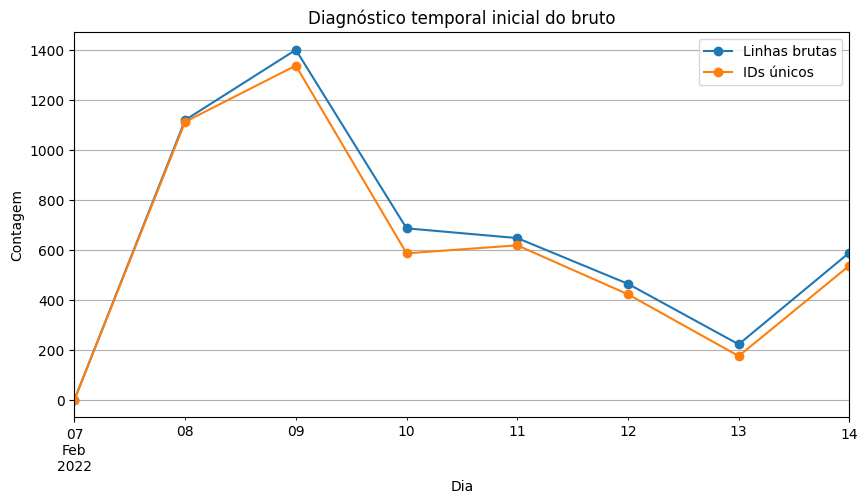

In [9]:
# Diagnóstico temporal inicial do bruto
# Objetivo: verificar cobertura temporal, forma geral do caso
# e possível efeito das duplicatas, sem ainda fazer a leitura analítica final.

id_col = "tweet_id" if "tweet_id" in raw_df.columns else "id"
date_col = "created_at_iso" if "created_at_iso" in raw_df.columns else "created_at"
user_col = "screen_name" if "screen_name" in raw_df.columns else ("user" if "user" in raw_df.columns else None)

diag_time = raw_df.copy()
diag_time[date_col] = pd.to_datetime(diag_time[date_col], utc=True, errors="coerce")
diag_time = diag_time.dropna(subset=[date_col])

diag_time["day"] = diag_time[date_col].dt.floor("D")

agg_dict = {
    "n_linhas_brutas": (id_col, "size"),
    "n_ids_unicos": (id_col, "nunique"),
}

if user_col is not None:
    agg_dict["n_usuarios_unicos"] = (user_col, "nunique")

daily_diag = (
    diag_time.groupby("day")
    .agg(**agg_dict)
    .reset_index()
    .sort_values("day")
)

display(daily_diag)

ax = daily_diag.plot(
    x="day",
    y=["n_linhas_brutas", "n_ids_unicos"],
    marker="o",
    figsize=(10, 5)
)
ax.set_title("Diagnóstico temporal inicial do bruto")
ax.set_xlabel("Dia")
ax.set_ylabel("Contagem")
ax.legend(["Linhas brutas", "IDs únicos"])
plt.show()

## Leitura do diagnóstico temporal inicial do bruto

O gráfico de diagnóstico temporal inicial sugere que o bruto cobre adequadamente o episódio analisado, com atividade residual em 07/02, forte escalada em 08/02, pico em 09/02 e queda progressiva entre 10/02 e 13/02, seguida de um repique em 14/02. A proximidade entre as curvas de linhas brutas e IDs únicos indica que as duplicatas por `id` não alteram completamente a forma geral do caso, embora produzam distorções não desprezíveis em alguns dias, sobretudo no entorno do clímax e no pós-clímax. Por isso, esta visualização deve ser lida apenas como diagnóstico preliminar da cobertura e da forma temporal do bruto. A análise substantiva do volume do caso será feita após o pré-processamento, com a base deduplicada e as datas devidamente padronizadas.

## Estratégia de pré-processamento

O pré-processamento deste notebook tem quatro objetivos principais:

1. garantir consistência temporal, convertendo corretamente os timestamps;
2. padronizar identificadores e textos mínimos para evitar ruídos de duplicidade;
3. preparar variáveis auxiliares para a análise exploratória e para a construção das janelas;
4. produzir uma base limpa e reprodutível, adequada à geração das métricas de rede.

As operações realizadas abaixo serão justificadas passo a passo, com comparação entre o estado bruto e o estado tratado dos dados.

In [10]:
# Pré-processamento principal do bruto consolidado
# Objetivo:
# 1) padronizar nomes e tipos mínimos
# 2) deduplicar corretamente por id do tweet
# 3) criar variáveis auxiliares úteis para as próximas etapas
# 4) produzir um relatório antes/depois da limpeza

df = raw_df.copy()

# -----------------------------
# 1. Resolver nomes reais das colunas
# -----------------------------
id_col = "tweet_id" if "tweet_id" in df.columns else "id"
user_col = "screen_name" if "screen_name" in df.columns else ("user" if "user" in df.columns else None)
date_col = "created_at_iso" if "created_at_iso" in df.columns else ("created_at" if "created_at" in df.columns else None)

if id_col not in df.columns:
    raise ValueError("Nenhuma coluna de identificador do tweet foi encontrada.")
if date_col is None:
    raise ValueError("Nenhuma coluna de data foi encontrada.")
if user_col is None:
    raise ValueError("Nenhuma coluna de usuário foi encontrada.")

# -----------------------------
# 2. Padronização textual mínima
# -----------------------------
text_like_cols = [c for c in [id_col, user_col, "text", "cleaned_text", "cleaned_text_bow",
                              "stance", "tweet_type", "in_reply_to_user"] if c in df.columns]

for col in text_like_cols:
    df[col] = df[col].astype("string").str.strip()

# Usuário em caixa baixa para reduzir ruído
df[user_col] = df[user_col].str.lower()

# Alguns campos vazios devem virar missing real
for col in [c for c in [id_col, user_col, "text", "cleaned_text", "cleaned_text_bow"] if c in df.columns]:
    df[col] = df[col].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "none": pd.NA})

# -----------------------------
# 3. Datas padronizadas
# -----------------------------
df[date_col] = pd.to_datetime(df[date_col], utc=True, errors="coerce")

# Colunas auxiliares padronizadas para uso nas próximas etapas
df["timestamp"] = df[date_col]
df["created_at_sp"] = df["timestamp"].dt.tz_convert("America/Sao_Paulo")
df["day_sp"] = df["created_at_sp"].dt.floor("D")

# -----------------------------
# 4. Colunas numéricas de interação
# -----------------------------
count_cols = [c for c in ["like_count", "retweet_count", "quote_count", "reply_count", "favorite_count"] if c in df.columns]
for col in count_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Engagement com preferência por like_count; favorite_count entra só se like_count não existir
engagement_cols = []
if "like_count" in df.columns:
    engagement_cols.append("like_count")
elif "favorite_count" in df.columns:
    engagement_cols.append("favorite_count")

for col in ["retweet_count", "quote_count", "reply_count"]:
    if col in df.columns:
        engagement_cols.append(col)

if engagement_cols:
    df["engagement"] = df[engagement_cols].sum(axis=1)

# -----------------------------
# 5. Aliases de compatibilidade
# -----------------------------
# Isso ajuda células antigas do esqueleto a continuarem funcionando
df["tweet_id"] = df[id_col]

if user_col is not None:
    df["screen_name"] = df[user_col]

if "like_count" in df.columns and "favorite_count" not in df.columns:
    df["favorite_count"] = df["like_count"]

# -----------------------------
# 6. Relatório antes da limpeza
# -----------------------------
rows_before = len(df)
unique_ids_before = df[id_col].nunique(dropna=True)
dups_before = df[id_col].duplicated().sum()

# -----------------------------
# 7. Deduplicação correta por id do tweet
# -----------------------------
df = df.drop_duplicates(subset=[id_col], keep="first").copy()

rows_after_dedup = len(df)
unique_ids_after_dedup = df[id_col].nunique(dropna=True)
dups_after_dedup = df[id_col].duplicated().sum()

# -----------------------------
# 8. Limpeza mínima após deduplicação
# -----------------------------
required_cols = [c for c in [id_col, user_col, "text", date_col] if c in df.columns]
df = df.dropna(subset=required_cols).copy()

rows_after_clean = len(df)
dups_after_clean = df[id_col].duplicated().sum()

# -----------------------------
# 9. Relatório final
# -----------------------------
preproc_report = pd.DataFrame({
    "etapa": [
        "bruto",
        "após_deduplicação",
        "após_limpeza_mínima"
    ],
    "n_linhas": [
        rows_before,
        rows_after_dedup,
        rows_after_clean
    ],
    "n_ids_unicos": [
        unique_ids_before,
        unique_ids_after_dedup,
        df[id_col].nunique(dropna=True)
    ],
    "duplicatas_restantes": [
        dups_before,
        dups_after_dedup,
        dups_after_clean
    ]
})

display(preproc_report)

print("Valores ausentes após limpeza (%):")
display((df.isna().mean() * 100).sort_values(ascending=False).to_frame("pct_missing"))

print(f"Coluna usada para deduplicação: {id_col}")
print(f"Coluna usada para usuário: {user_col}")
print(f"Coluna usada para data: {date_col}")

print("\nPrimeiras linhas da base tratada:")
display(df.head())

,etapa,n_linhas,n_ids_unicos,duplicatas_restantes
0,bruto,5143,4803,340
1,após_deduplicação,4803,4803,0
2,após_limpeza_mínima,4803,4803,0


Valores ausentes após limpeza (%):


,pct_missing
id,0.0
user,0.0
text,0.0
cleaned_text,0.0
cleaned_text_bow,0.0
created_at,0.0
created_at_iso,0.0
stance,0.0
is_quote,0.0
is_retweet,0.0


Coluna usada para deduplicação: id
Coluna usada para usuário: user
Coluna usada para data: created_at_iso

Primeiras linhas da base tratada:


,id,user,text,cleaned_text,cleaned_text_bow,created_at,created_at_iso,stance,is_quote,is_retweet,...,retweet_count,quote_count,reply_count,timestamp,created_at_sp,day_sp,engagement,tweet_id,screen_name,favorite_count
0,1493365469679603712,sweet_leaf0420,#monark agora tem um jogo https://t.co/M4I17O...,agora tem um jogo,agora tem um jogo,Mon Feb 14 23:24:08 +0000 2022,2022-02-14 23:24:08+00:00,acusador,False,False,...,0,0,0,2022-02-14 23:24:08+00:00,2022-02-14 20:24:08-03:00,2022-02-14 00:00:00-03:00,1,1493365469679603712,sweet_leaf0420,1
1,1493358546523758598,billcomerlato,"Quem conhece o Monark, sabe quem ele é, e a fa...","Quem conhece o Monark, sabe quem ele é, e a fa...",quem conhece o monark sabe quem ele e e a falt...,Mon Feb 14 22:56:37 +0000 2022,2022-02-14 22:56:37+00:00,acusador,False,False,...,0,0,0,2022-02-14 22:56:37+00:00,2022-02-14 19:56:37-03:00,2022-02-14 00:00:00-03:00,1,1493358546523758598,billcomerlato,1
2,1493358391753859080,laelson93,"Na moral, o #flowpodcast tá mó sem graça sem o...","Na moral, o tá mó sem graça sem o , todo mundo...",na moral o ta mo sem graca sem o todo mundo sa...,Mon Feb 14 22:56:00 +0000 2022,2022-02-14 22:56:00+00:00,defensor,False,False,...,0,0,0,2022-02-14 22:56:00+00:00,2022-02-14 19:56:00-03:00,2022-02-14 00:00:00-03:00,5,1493358391753859080,laelson93,5
3,1493345601781739522,ustria_carlos,Já confirmaram a participação do Monark no 'A ...,Já confirmaram a participação do Monark no 'A ...,ja confirmaram a participacao do monark no a f...,Mon Feb 14 22:05:11 +0000 2022,2022-02-14 22:05:11+00:00,acusador,False,False,...,0,0,2,2022-02-14 22:05:11+00:00,2022-02-14 19:05:11-03:00,2022-02-14 00:00:00-03:00,3,1493345601781739522,ustria_carlos,1
4,1493338660955172865,limagalhae,Sobre #monark aprendam que a única coisa que f...,Sobre aprendam que a única coisa que funciona ...,sobre aprendam que a unica coisa que funciona ...,Mon Feb 14 21:37:36 +0000 2022,2022-02-14 21:37:36+00:00,acusador,False,False,...,0,0,0,2022-02-14 21:37:36+00:00,2022-02-14 18:37:36-03:00,2022-02-14 00:00:00-03:00,1,1493338660955172865,limagalhae,1


In [11]:
# Comparação antes/depois do pré-processamento
preproc_report = pd.DataFrame({
    "etapa": ["bruto", "após_deduplicação", "após_limpeza_mínima"],
    "n_linhas": [rows_before, rows_after_dedup, rows_after_clean]
})

display(preproc_report)

print("Valores ausentes após limpeza (%):")
display((df.isna().mean() * 100).sort_values(ascending=False).to_frame("pct_missing"))

,etapa,n_linhas
0,bruto,5143
1,após_deduplicação,4803
2,após_limpeza_mínima,4803


Valores ausentes após limpeza (%):


,pct_missing
id,0.0
user,0.0
text,0.0
cleaned_text,0.0
cleaned_text_bow,0.0
created_at,0.0
created_at_iso,0.0
stance,0.0
is_quote,0.0
is_retweet,0.0


In [12]:
# Auditoria explícita de tipagem, completude e volumetria (bruto vs. tratado)

if "raw_df" not in globals():
    raise RuntimeError("A variável 'raw_df' não existe. Rode antes a célula 14 — Carga consolidada dos dados brutos.")

if "df" not in globals():
    raise RuntimeError("A variável 'df' não existe. Rode antes a célula 21 — Pré-processamento principal do bruto consolidado.")

def summarize_frame(dataframe: pd.DataFrame, name: str) -> dict:
    id_col = "tweet_id" if "tweet_id" in dataframe.columns else ("id" if "id" in dataframe.columns else None)
    user_col = "screen_name" if "screen_name" in dataframe.columns else ("user" if "user" in dataframe.columns else None)

    time_candidates = ["created_at_sp", "timestamp", "created_at_iso", "created_at"]
    time_col = next((c for c in time_candidates if c in dataframe.columns), None)

    missing = dataframe.isna().sum()
    pct_missing = (missing / len(dataframe) * 100).round(2)

    summary = {
        "base": name,
        "n_linhas": len(dataframe),
        "n_colunas": dataframe.shape[1],
        "n_colunas_numericas": int(dataframe.select_dtypes(include=[np.number]).shape[1]),
        "n_colunas_booleanas": int(dataframe.select_dtypes(include=["bool"]).shape[1]),
        "n_colunas_textuais": int(dataframe.select_dtypes(include=["object", "string"]).shape[1]),
        "n_valores_ausentes_total": int(missing.sum()),
        "pct_ausentes_total": float(round(missing.sum() / dataframe.size * 100, 4)),
    }

    if id_col is not None:
        summary["n_ids_unicos"] = int(dataframe[id_col].nunique(dropna=True))
        summary["duplicatas_por_id"] = int(len(dataframe) - dataframe[id_col].nunique(dropna=True))

    if user_col is not None:
        summary["n_usuarios_unicos"] = int(dataframe[user_col].astype("string").str.lower().nunique(dropna=True))

    if time_col is not None:
        times = pd.to_datetime(dataframe[time_col], errors="coerce", utc=True)
        summary["min_tempo_utc"] = times.min()
        summary["max_tempo_utc"] = times.max()

    return summary

def info_to_frame(dataframe: pd.DataFrame) -> pd.DataFrame:
    buf = io.StringIO()
    dataframe.info(buf=buf)
    lines = buf.getvalue().splitlines()
    return pd.DataFrame({"info_linha": lines})

summary_df = pd.DataFrame([
    summarize_frame(raw_df, "bruto"),
    summarize_frame(df, "tratado"),
])

print("Resumo executivo das duas bases:")
display(summary_df)

print("raw_df.info():")
display(info_to_frame(raw_df))

print("df.info():")
display(info_to_frame(df))

missing_compare = pd.concat(
    [
        raw_df.isna().sum().rename("raw_n_missing"),
        (raw_df.isna().sum() / len(raw_df) * 100).round(2).rename("raw_pct_missing"),
        df.isna().sum().rename("df_n_missing"),
        (df.isna().sum() / len(df) * 100).round(2).rename("df_pct_missing"),
    ],
    axis=1
).sort_values(["df_n_missing", "raw_n_missing"], ascending=False)

print("Comparação de valores ausentes:")
display(missing_compare)

raw_num = raw_df.select_dtypes(include=[np.number])
df_num = df.select_dtypes(include=[np.number])

if not raw_num.empty:
    print("Resumo estatístico do bruto (atributos numéricos):")
    raw_desc = raw_num.describe().T
    raw_desc["mediana"] = raw_num.median()
    raw_desc["moda"] = raw_num.mode(dropna=True).iloc[0]
    raw_desc["n_missing"] = raw_num.isna().sum()
    display(raw_desc.round(4))

if not df_num.empty:
    print("Resumo estatístico da base tratada (atributos numéricos):")
    df_desc = df_num.describe().T
    df_desc["mediana"] = df_num.median()
    df_desc["moda"] = df_num.mode(dropna=True).iloc[0]
    df_desc["n_missing"] = df_num.isna().sum()
    display(df_desc.round(4))

Resumo executivo das duas bases:


,base,n_linhas,n_colunas,n_colunas_numericas,n_colunas_booleanas,n_colunas_textuais,n_valores_ausentes_total,pct_ausentes_total,n_ids_unicos,duplicatas_por_id,n_usuarios_unicos,min_tempo_utc,max_tempo_utc
0,bruto,5143,19,4,2,13,0,0.0,4803,340,4140,2022-02-07 23:13:45+00:00,2022-02-14 23:59:59+00:00
1,tratado,4803,26,6,2,14,0,0.0,4803,0,4140,2022-02-07 23:13:45+00:00,2022-02-14 23:59:59+00:00


raw_df.info():


,info_linha
0,<class 'pandas.core.frame.DataFrame'>
1,"RangeIndex: 5143 entries, 0 to 5142"
2,Data columns (total 19 columns):
3,# Column Non-Null Count Dt...
4,--- ------ -------------- --...
5,0 id 5143 non-null ob...
6,1 user 5143 non-null ob...
7,2 text 5143 non-null ob...
8,3 cleaned_text 5143 non-null ob...
9,4 cleaned_text_bow 5143 non-null ob...


df.info():


...

,raw_n_missing,raw_pct_missing,df_n_missing,df_pct_missing
id,0.0,0.0,0,0.0
user,0.0,0.0,0,0.0
text,0.0,0.0,0,0.0
cleaned_text,0.0,0.0,0,0.0
cleaned_text_bow,0.0,0.0,0,0.0
created_at,0.0,0.0,0,0.0
created_at_iso,0.0,0.0,0,0.0
stance,0.0,0.0,0,0.0
is_quote,0.0,0.0,0,0.0
is_retweet,0.0,0.0,0,0.0


Resumo estatístico do bruto (atributos numéricos):


,count,mean,std,min,25%,50%,75%,max,mediana,moda,n_missing
like_count,5143.0,98.5211,1843.3998,0.0,0.0,0.0,2.0,68379.0,0.0,0,0
retweet_count,5143.0,10.4486,236.0092,0.0,0.0,0.0,0.0,11708.0,0.0,0,0
quote_count,5143.0,2.1412,51.0629,0.0,0.0,0.0,0.0,2733.0,0.0,0,0
reply_count,5143.0,2.2499,21.7424,0.0,0.0,0.0,1.0,990.0,0.0,0,0


Resumo estatístico da base tratada (atributos numéricos):


,count,mean,std,min,25%,50%,75%,max,mediana,moda,n_missing
like_count,4803.0,105.2328,1907.3395,0.0,0.0,0.0,2.0,68379.0,0.0,0,0
retweet_count,4803.0,11.1636,244.2035,0.0,0.0,0.0,0.0,11708.0,0.0,0,0
quote_count,4803.0,2.2879,52.8364,0.0,0.0,0.0,0.0,2733.0,0.0,0,0
reply_count,4803.0,2.3571,22.4885,0.0,0.0,0.0,1.0,990.0,0.0,0,0
engagement,4803.0,121.0414,2191.0028,0.0,0.0,1.0,2.0,80138.0,1.0,0,0
favorite_count,4803.0,105.2328,1907.3395,0.0,0.0,0.0,2.0,68379.0,0.0,0,0


## Leitura do pré-processamento

O pré-processamento teve como efeito principal a **eliminação de duplicatas por identificador de tweet**, reduzindo a base de **5143** para **4803** linhas. Isso significa a remoção de **340 registros duplicados** (cerca de **6,6%** do bruto), sem perda adicional de cobertura do caso. A evidência disso é que o número de **IDs únicos** no bruto já era exatamente **4803**, o mesmo total da base tratada.

Um ponto importante é que a limpeza **não reduziu a diversidade de autores**: o número de **usuários únicos** permaneceu em **4140** nas duas bases. Assim, o tratamento atuou principalmente sobre repetição de registros, e não sobre empobrecimento do universo empírico analisado. Do mesmo modo, a **cobertura temporal foi preservada integralmente**, permanecendo entre **2022-02-07 23:13:45+00:00** e **2022-02-14 23:59:59+00:00**.

Além da deduplicação, houve uma **padronização do schema**. A base bruta tinha **19 colunas**, enquanto a base tratada passou a ter **26**, incorporando variáveis derivadas e padronizadas que facilitam a análise, como `timestamp`, `created_at_sp`, `day_sp`, `engagement`, `tweet_id`, `screen_name` e `favorite_count`. Também houve conversão de tipos, com textos padronizados em `string` e datas convertidas para `datetime`, inclusive com fuso de **America/Sao_Paulo**, o que torna a análise temporal mais consistente.

Do ponto de vista de completude, a base está em situação muito favorável: **não há valores ausentes (`NaN`)** nem no bruto nem no tratado. Isso significa que não foi necessário aplicar estratégias de imputação. Ainda assim, vale observar que, em bases de redes sociais, algumas ausências substantivas podem vir codificadas como **strings vazias, listas vazias ou zeros**, e não necessariamente como `NaN`.

As estatísticas descritivas das colunas numéricas mostram um padrão claro de **alta assimetria e cauda longa**. Em métricas como `like_count`, `retweet_count`, `quote_count` e `reply_count`, a **mediana** e a **moda** são iguais a **0** (ou muito próximas disso), enquanto os valores máximos são muito elevados. Na base tratada, por exemplo, `like_count` chega a **68379**, `retweet_count` a **11708**, `quote_count` a **2733** e o `engagement` total a **80138**. Isso indica que a maior parte dos tweets tem baixo engajamento, mas poucos casos concentram valores extremamente altos.

Em conjunto, o pré-processamento produziu uma base **mais limpa, tipada, consistente e pronta para análise**, preservando a extensão temporal e a diversidade de usuários, eliminando duplicatas e adicionando variáveis úteis para as etapas seguintes. Também revelou que as métricas de engajamento têm distribuição fortemente desigual, o que justifica o uso posterior de leituras robustas, normalizações por unidade de tempo e transformações como `log1p` em análises exploratórias complementares.

In [13]:
# Estatísticas descritivas das colunas numéricas principais (base tratada)

def summarize_numeric(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    mode_vals = s.mode(dropna=True)
    return pd.Series({
        "min": s.min(),
        "max": s.max(),
        "mediana": s.median(),
        "moda": mode_vals.iloc[0] if len(mode_vals) else np.nan,
        "média": s.mean(),
        "desvio_padrão": s.std(),
        "ausentes": s.isna().sum()
    })

numeric_cols = [
    c for c in ["like_count", "retweet_count", "quote_count", "reply_count", "engagement"]
    if c in df.columns
]

if numeric_cols:
    desc_df = pd.concat(
        {col: summarize_numeric(df[col]) for col in numeric_cols},
        axis=1
    ).T

    # arredondar só as métricas contínuas para leitura melhor
    for col in ["min", "max", "mediana", "moda", "média", "desvio_padrão"]:
        if col in desc_df.columns:
            desc_df[col] = desc_df[col].round(4)

    display(desc_df)
else:
    print("Nenhuma das colunas numéricas esperadas foi encontrada em df.")

,min,max,mediana,moda,média,desvio_padrão,ausentes
like_count,0.0,68379.0,0.0,0.0,105.2328,1907.3395,0.0
retweet_count,0.0,11708.0,0.0,0.0,11.1636,244.2035,0.0
quote_count,0.0,2733.0,0.0,0.0,2.2879,52.8364,0.0
reply_count,0.0,990.0,0.0,0.0,2.3571,22.4885,0.0
engagement,0.0,80138.0,1.0,0.0,121.0414,2191.0028,0.0


Rótulos encontrados em stance:
['acusador', 'defensor', 'neutro']


,count,pct
stance,,
acusador,3324,69.21
defensor,1301,27.09
neutro,178,3.71


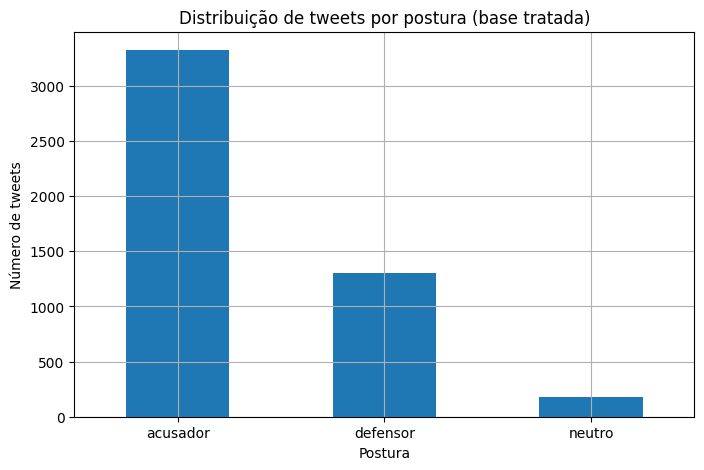

In [14]:
# Distribuição por postura (base tratada) — versão sem remapeamento semântico

if "stance" not in df.columns:
    print("A coluna 'stance' não está disponível em df.")
else:
    stance_plot = df.copy()

    # limpeza mínima, sem alterar o significado dos rótulos
    stance_plot["stance"] = stance_plot["stance"].astype("string").str.strip()

    # mostrar os rótulos realmente presentes na base
    unique_stances = sorted(stance_plot["stance"].dropna().unique().tolist())
    print("Rótulos encontrados em stance:")
    print(unique_stances)

    stance_counts = stance_plot["stance"].fillna("ausente").value_counts()

    preferred_order = ["acusador", "defensor", "neutro", "indefinido", "ausente"]
    ordered_index = [x for x in preferred_order if x in stance_counts.index] + [
        x for x in stance_counts.index if x not in preferred_order
    ]

    stance_counts = stance_counts.reindex(ordered_index)

    stance_summary = pd.DataFrame({
        "count": stance_counts,
        "pct": (stance_counts / stance_counts.sum() * 100).round(2)
    })

    display(stance_summary)

    ax = stance_summary["count"].plot(
        kind="bar",
        figsize=(8, 5),
        rot=0
    )
    ax.set_title("Distribuição de tweets por postura (base tratada)")
    ax.set_xlabel("Postura")
    ax.set_ylabel("Número de tweets")
    plt.show()

## Leitura da distribuição por postura

A distribuição de posturas na base tratada mostra um claro predomínio de tweets **acusadores**, que representam **69,21%** do total, contra **27,09%** de tweets **defensores** e apenas **3,71%** de tweets **neutros**. Esse resultado sugere que o caso Monark, considerado no conjunto do período analisado, é discursivamente dominado por uma orientação de ataque ou reprovação ao alvo. Ao mesmo tempo, a presença de uma parcela defensora ainda significativa indica que o episódio não é totalmente homogêneo, mas atravessado por disputa discursiva. Já a baixa proporção de neutros sugere que o caso tende a polarizar os participantes em posições mais claramente alinhadas. Como essa distribuição foi calculada após a deduplicação, ela oferece um retrato mais confiável da composição discursiva do episódio, embora ainda de forma agregada, sem distinguir as variações entre pré-clímax, clímax e pós-clímax.

,n_tweets,pct_base
user,,
santosa07387900,37,0.77
omonoirelia,16,0.33
giordanobrunobr,16,0.33
x_caju,8,0.17
marciachaves17,8,0.17
luanapdrb,7,0.15
valriacostadoe1,7,0.15
lacta,7,0.15
plenonews,6,0.12


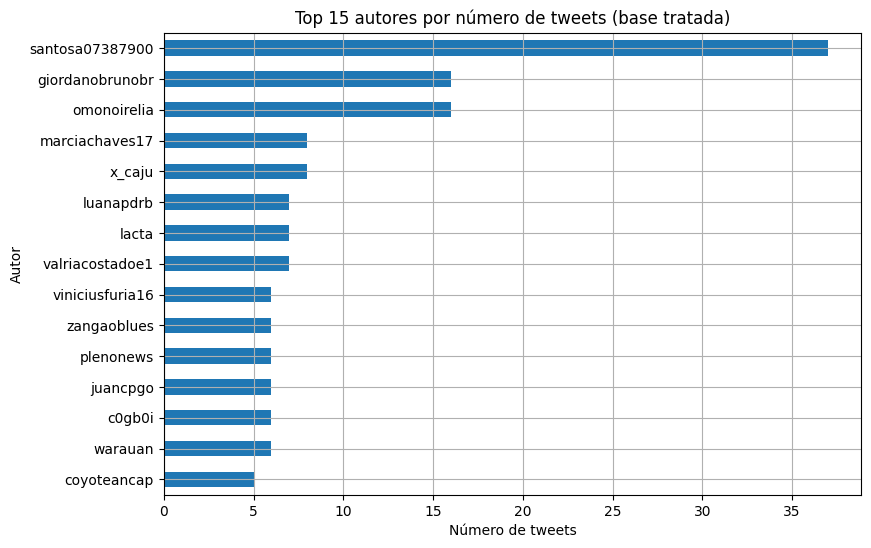

Número total de autores únicos: 4140
Participação dos 10 autores mais ativos na base (%): 2.46


In [15]:
# Top autores na base tratada

user_col = "user" if "user" in df.columns else ("screen_name" if "screen_name" in df.columns else None)

if user_col is None:
    print("Nenhuma coluna de usuário foi encontrada em df.")
else:
    author_plot = df.copy()

    author_plot[user_col] = (
        author_plot[user_col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    author_plot = author_plot.dropna(subset=[user_col])

    author_counts = author_plot[user_col].value_counts()
    top_n = 15
    top_authors = author_counts.head(top_n)

    top_authors_df = pd.DataFrame({
        "n_tweets": top_authors,
        "pct_base": (top_authors / len(author_plot) * 100).round(2)
    })

    display(top_authors_df)

    ax = top_authors.sort_values(ascending=True).plot(
        kind="barh",
        figsize=(9, 6)
    )
    ax.set_title(f"Top {top_n} autores por número de tweets (base tratada)")
    ax.set_xlabel("Número de tweets")
    ax.set_ylabel("Autor")
    plt.show()

    print("Número total de autores únicos:", author_plot[user_col].nunique())
    print("Participação dos 10 autores mais ativos na base (%):",
          round(author_counts.head(10).sum() / len(author_plot) * 100, 2))

## Leitura dos autores mais ativos

O gráfico sugere que a produção de tweets na base tratada é relativamente distribuída, sem concentração extrema em poucos perfis. O autor mais ativo responde por apenas **0,77%** do total, e mesmo os autores mais prolíficos representam parcela pequena da base. Isso indica que a atividade do caso não depende apenas de um núcleo muito reduzido de emissores. Ainda assim, é importante ter cuidado metodológico: esta célula mostra **quem mais publicou**, e não quem teve mais alcance, recebeu mais atenção ou ocupou posições mais centrais na rede. Essas dimensões serão avaliadas mais adiante nas métricas temporais e relacionais.

Métricas usadas na EDA clássica: ['favorite_count', 'retweet_count', 'reply_count', 'quote_count', 'engagement']


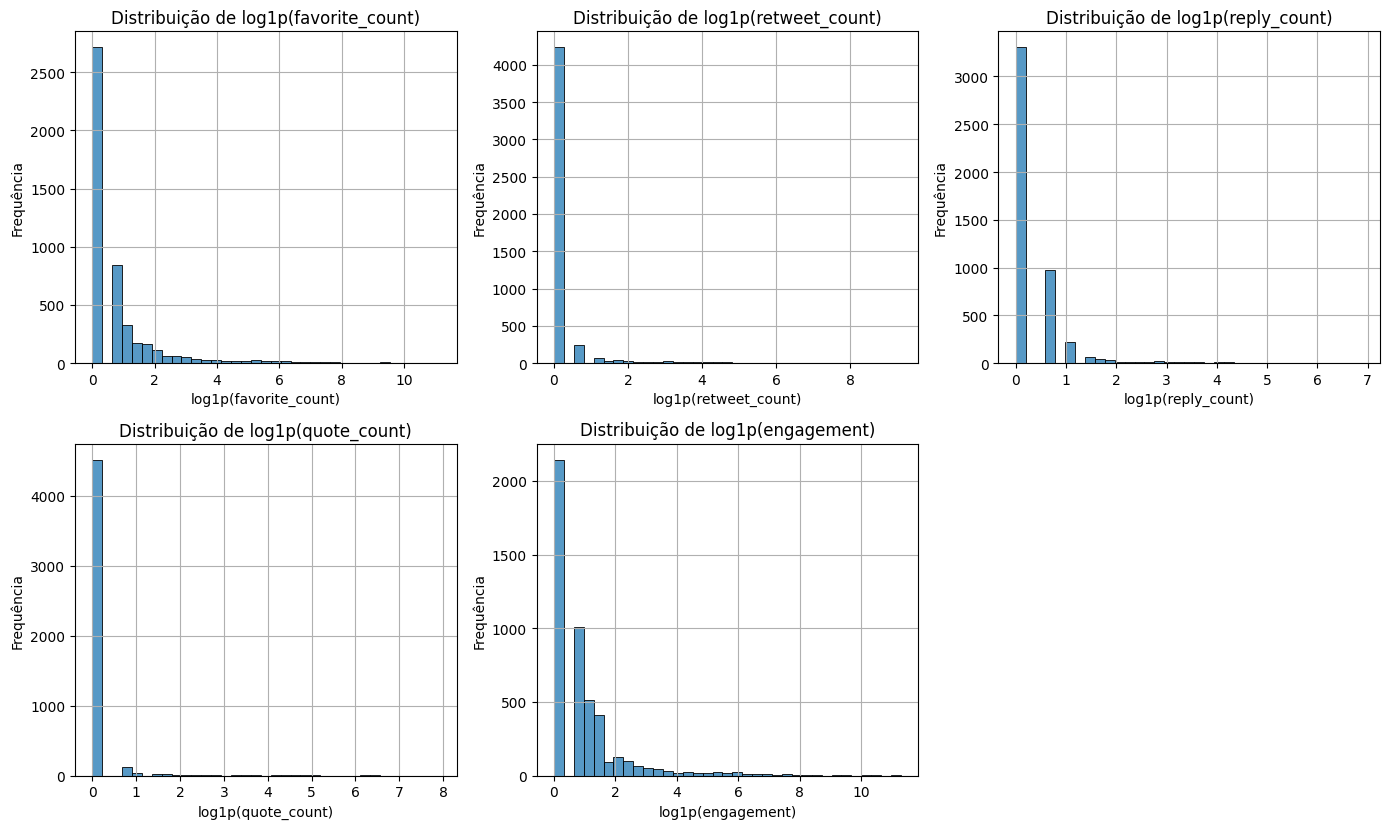

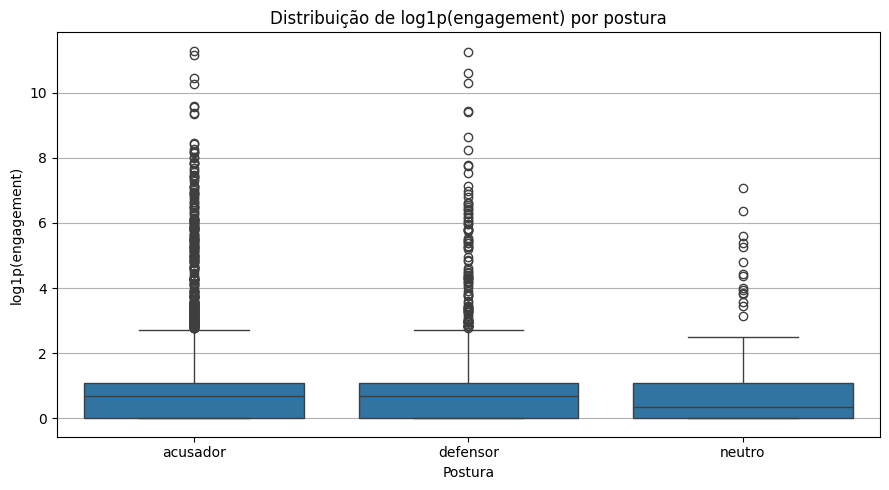

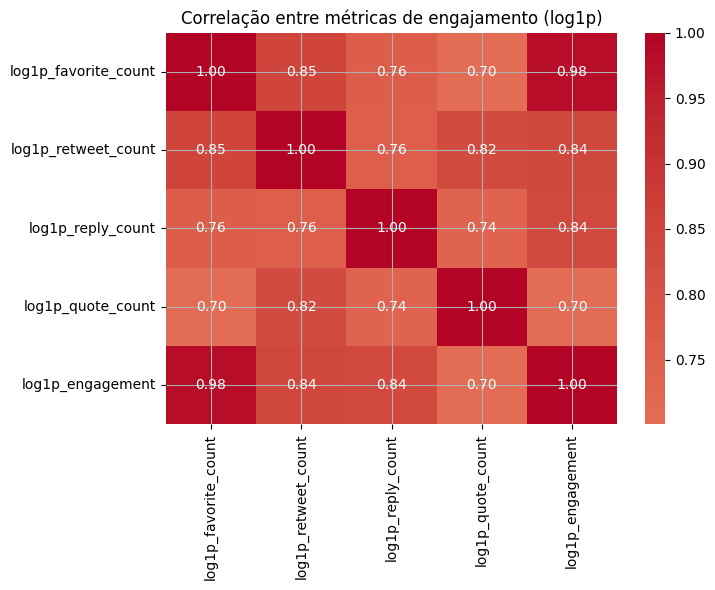

Tabela de apoio da EDA clássica:


,variavel,assimetria_bruta,assimetria_log1p,media_bruta,mediana_bruta
0,favorite_count,29.1238,3.0481,105.2328,0.0
1,retweet_count,35.6325,5.3279,11.1636,0.0
2,reply_count,26.2713,3.5333,2.3571,0.0
3,quote_count,41.4352,7.8778,2.2879,0.0
4,engagement,29.4083,2.8236,121.0414,1.0


In [16]:
# EDA clássica da base tratada: distribuições, boxplot por postura e correlação

if "df" not in globals():
    raise RuntimeError("A variável 'df' não existe. Rode antes a célula 21 — Pré-processamento principal do bruto consolidado.")

plot_df = df.copy()

like_col = "favorite_count" if "favorite_count" in plot_df.columns else ("like_count" if "like_count" in plot_df.columns else None)

metric_cols = []
if like_col is not None:
    metric_cols.append(like_col)

for col in ["retweet_count", "reply_count", "quote_count", "engagement"]:
    if col in plot_df.columns:
        metric_cols.append(col)

metric_cols = list(dict.fromkeys(metric_cols))

if not metric_cols:
    raise ValueError("Nenhuma métrica numérica principal foi encontrada para a EDA clássica.")

# Garantir numéricos e criar log1p
for col in metric_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce").fillna(0)

for col in metric_cols:
    plot_df[f"log1p_{col}"] = np.log1p(plot_df[col].clip(lower=0))

print("Métricas usadas na EDA clássica:", metric_cols)

# 1) Histograma das distribuições transformadas
n = len(metric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, metric_cols):
    sns.histplot(plot_df[f"log1p_{col}"], bins=35, ax=ax)
    ax.set_title(f"Distribuição de log1p({col})")
    ax.set_xlabel(f"log1p({col})")
    ax.set_ylabel("Frequência")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# 2) Boxplot por postura
if "stance" in plot_df.columns:
    stance_df = plot_df.copy()
    stance_df["stance"] = stance_df["stance"].astype("string").str.strip().str.lower()
    stance_order = [x for x in ["acusador", "defensor", "neutro", "indefinido"] if x in stance_df["stance"].dropna().unique().tolist()]

    focus_metric = "engagement" if "engagement" in metric_cols else metric_cols[0]

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(
        data=stance_df,
        x="stance",
        y=f"log1p_{focus_metric}",
        order=stance_order if stance_order else None,
        ax=ax
    )
    ax.set_title(f"Distribuição de log1p({focus_metric}) por postura")
    ax.set_xlabel("Postura")
    ax.set_ylabel(f"log1p({focus_metric})")
    plt.tight_layout()
    plt.show()

# 3) Heatmap de correlação
corr_cols = [f"log1p_{c}" for c in metric_cols]
corr = plot_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlação entre métricas de engajamento (log1p)")
plt.tight_layout()
plt.show()

# Tabela curta de apoio
eda_support = pd.DataFrame({
    "variavel": metric_cols,
    "assimetria_bruta": [plot_df[c].skew() for c in metric_cols],
    "assimetria_log1p": [plot_df[f"log1p_{c}"].skew() for c in metric_cols],
    "media_bruta": [plot_df[c].mean() for c in metric_cols],
    "mediana_bruta": [plot_df[c].median() for c in metric_cols],
})

print("Tabela de apoio da EDA clássica:")
display(eda_support.round(4))

# Leitura das métricas de engajamento

Os gráficos sugerem que as métricas de interação na base tratada são fortemente assimétricas, com grande concentração de observações em valores baixos e poucos casos de repercussão muito elevada. Mesmo após a transformação log1p, permanece o padrão de cauda longa, indicando que a visibilidade se distribui de forma desigual entre os tweets. A matriz de correlação mostra ainda que curtidas, retweets, respostas, citações e engajamento total tendem a variar conjuntamente, o que sugere um acoplamento importante entre diferentes formas de atenção.

Ainda assim, é importante ter cuidado metodológico: esta célula descreve a distribuição estatística das métricas de interação e sua associação entre si, mas não demonstra, por si só, causalidade nem estabelece diferenças conclusivas entre os grupos de postura. O boxplot sugere sobreposição relevante entre acusador, defensor e neutro, de modo que essas distinções devem ser avaliadas em conjunto com as análises temporais, comparativas e relacionais desenvolvidas nas seções seguintes.

In [17]:
# Preparação adicional: atributos derivados, log1p, StandardScaler e MinMaxScaler

if "df" not in globals():
    raise RuntimeError("A variável 'df' não existe. Rode antes a célula 21 — Pré-processamento principal do bruto consolidado.")

prep_df = df.copy()

like_col = "favorite_count" if "favorite_count" in prep_df.columns else ("like_count" if "like_count" in prep_df.columns else None)

base_features = []
if like_col is not None:
    base_features.append(like_col)

for col in ["retweet_count", "reply_count", "quote_count", "engagement"]:
    if col in prep_df.columns:
        base_features.append(col)

# Atributos derivados simples e úteis
if "hashtags" in prep_df.columns:
    prep_df["n_hashtags"] = prep_df["hashtags"].apply(lambda x: len(x) if isinstance(x, list) else 0)
    base_features.append("n_hashtags")

if "mentions" in prep_df.columns:
    prep_df["n_mentions"] = prep_df["mentions"].apply(lambda x: len(x) if isinstance(x, list) else 0)
    base_features.append("n_mentions")

text_source = "cleaned_text" if "cleaned_text" in prep_df.columns else ("text" if "text" in prep_df.columns else None)
if text_source is not None:
    prep_df["text_len"] = prep_df[text_source].fillna("").astype(str).str.len()
    base_features.append("text_len")

base_features = list(dict.fromkeys(base_features))

if not base_features:
    raise ValueError("Nenhuma feature contínua foi encontrada para a preparação adicional.")

# Garantir numéricos e criar log1p
for col in base_features:
    prep_df[col] = pd.to_numeric(prep_df[col], errors="coerce").fillna(0)
    prep_df[f"log1p_{col}"] = np.log1p(prep_df[col].clip(lower=0))

log_features = [f"log1p_{c}" for c in base_features]

std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()

std_values = std_scaler.fit_transform(prep_df[log_features])
mm_values = mm_scaler.fit_transform(prep_df[log_features])

std_cols = [f"z_{c}" for c in base_features]
mm_cols = [f"mm_{c}" for c in base_features]

prep_df[std_cols] = std_values
prep_df[mm_cols] = mm_values

# One-hot opcional da postura, sem sobrescrever nada do notebook principal
if "stance" in prep_df.columns:
    stance_dummies = pd.get_dummies(
        prep_df["stance"].fillna("ausente").astype("string").str.strip().str.lower(),
        prefix="stance",
        dtype=int
    )
    prep_df = pd.concat([prep_df, stance_dummies], axis=1)

# Guardar em variável separada para não mexer no df principal
df_prepared_aux = prep_df.copy()

scale_summary = pd.DataFrame({
    "feature_original": base_features,
    "min_bruto": [df_prepared_aux[c].min() for c in base_features],
    "max_bruto": [df_prepared_aux[c].max() for c in base_features],
    "media_log1p": [df_prepared_aux[f"log1p_{c}"].mean() for c in base_features],
    "std_zscore": [df_prepared_aux[f"z_{c}"].std() for c in base_features],
    "min_minmax": [df_prepared_aux[f"mm_{c}"].min() for c in base_features],
    "max_minmax": [df_prepared_aux[f"mm_{c}"].max() for c in base_features],
})

print("Base auxiliar preparada para boas práticas de pré-processamento:")
print("df_prepared_aux.shape =", df_prepared_aux.shape)
display(scale_summary.round(4))

preview_cols = (
    base_features
    + [f"log1p_{c}" for c in base_features[: min(3, len(base_features))]]
    + [f"z_{c}" for c in base_features[: min(3, len(base_features))]]
    + [f"mm_{c}" for c in base_features[: min(3, len(base_features))]]
)

preview_cols = [c for c in preview_cols if c in df_prepared_aux.columns]

print("Prévia das transformações:")
display(df_prepared_aux[preview_cols].head(10).round(4))

Base auxiliar preparada para boas práticas de pré-processamento:
df_prepared_aux.shape = (4803, 56)


,feature_original,min_bruto,max_bruto,media_log1p,std_zscore,min_minmax,max_minmax
0,favorite_count,0,68379,0.7635,1.0001,0.0,1.0
1,retweet_count,0,11708,0.2166,1.0001,0.0,1.0
2,reply_count,0,990,0.3528,1.0001,0.0,1.0
3,quote_count,0,2733,0.0973,1.0001,0.0,1.0
4,engagement,0,80138,0.9305,1.0001,0.0,1.0
5,n_hashtags,0,8,0.1218,1.0001,0.0,1.0
6,n_mentions,0,17,0.5792,1.0001,0.0,1.0
7,text_len,4,289,4.8762,1.0001,0.0,1.0


Prévia das transformações:


,favorite_count,retweet_count,reply_count,quote_count,engagement,n_hashtags,n_mentions,text_len,log1p_favorite_count,log1p_retweet_count,log1p_reply_count,z_favorite_count,z_retweet_count,z_reply_count,mm_favorite_count,mm_retweet_count,mm_reply_count
0,1,0,0,0,1,1,0,17,0.6931,0.0,0.0000,-0.0505,-0.2693,-0.4845,0.0623,0.0,0.0000
1,1,0,0,0,1,3,1,134,0.6931,0.0,0.0000,-0.0505,-0.2693,-0.4845,0.0623,0.0,0.0000
2,5,0,0,0,5,2,2,234,1.7918,0.0,0.0000,0.7389,-0.2693,-0.4845,0.1609,0.0,0.0000
3,1,0,2,0,3,4,0,77,0.6931,0.0,1.0986,-0.0505,-0.2693,1.0243,0.0623,0.0,0.1592
4,1,0,0,0,1,1,0,271,0.6931,0.0,0.0000,-0.0505,-0.2693,-0.4845,0.0623,0.0,0.0000
5,0,0,0,0,0,2,1,18,0.0000,0.0,0.0000,-0.5487,-0.2693,-0.4845,0.0000,0.0,0.0000
6,0,0,0,0,0,3,1,53,0.0000,0.0,0.0000,-0.5487,-0.2693,-0.4845,0.0000,0.0,0.0000
7,0,0,0,0,0,2,1,118,0.0000,0.0,0.0000,-0.5487,-0.2693,-0.4845,0.0000,0.0,0.0000
8,0,0,0,0,0,2,1,184,0.0000,0.0,0.0000,-0.5487,-0.2693,-0.4845,0.0000,0.0,0.0000
9,4,0,0,0,4,1,2,45,1.6094,0.0,0.0000,0.6079,-0.2693,-0.4845,0.1446,0.0,0.0000


# Leitura do preparo auxiliar para pré-processamento

A célula sugere que a base tratada foi expandida de forma controlada para incorporar versões transformadas das variáveis numéricas, sem perda das observações originais. As diferenças de escala entre métricas como favorite_count, engagement, n_hashtags e text_len justificam o uso combinado de log1p, z-score e min-max. Ainda assim, é importante ter cuidado metodológico: esta etapa não produz, por si só, uma inferência substantiva sobre o caso, mas organiza a base para leituras posteriores mais comparáveis e robustas.

,segment_id,phase_block,granularity,window_hours,n_tweets_total,tweets_per_hour_total,acusador_count,defensor_count,neutro_count
0,pre_0708,pre,pre_agg,44.9997,1116,24.8002,805,286,25
1,climax_6h_0000_0559,climax,6h,5.9997,174,29.0013,134,32,8
2,climax_6h_0600_1159,climax,6h,5.9997,300,50.0023,205,83,12
3,climax_6h_1200_1759,climax,6h,5.9997,411,68.5032,270,126,15
4,climax_6h_1800_2359,climax,6h,5.9997,230,38.3351,169,53,8
5,post_2022_02_10,post,1d,23.9997,559,23.2919,419,120,20
6,post_2022_02_11,post,1d,23.9997,671,27.9587,409,228,34
7,post_2022_02_12,post,1d,23.9997,330,13.7502,227,90,13
8,post_2022_02_13,post,1d,23.9997,165,6.8751,96,61,8
9,post_2022_02_14,post,1d,23.9997,521,21.7086,343,154,24


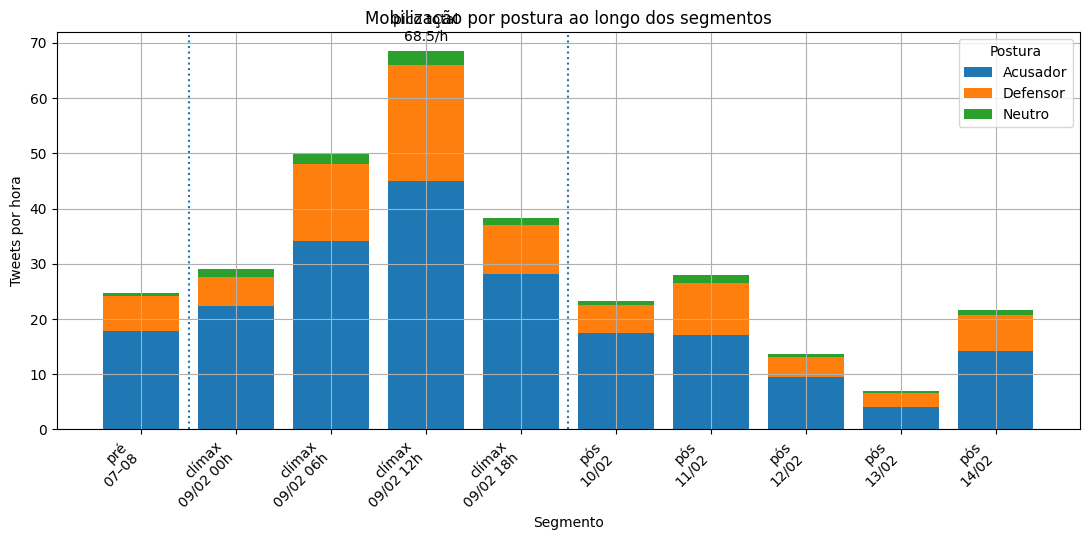

Segmento com maior mobilização total: climax_6h_1200_1759 - 68.5032 tweets/h


In [18]:
# Mobilização por postura ao longo dos segmentos (tweets por hora)

if "stance" not in df.columns:
    raise ValueError("A coluna 'stance' não existe em df.")

plot_df = df.copy()

# Garantir tempo em São Paulo
if "created_at_sp" not in plot_df.columns:
    date_col = "created_at_iso" if "created_at_iso" in plot_df.columns else "created_at"
    plot_df[date_col] = pd.to_datetime(plot_df[date_col], utc=True, errors="coerce")
    plot_df["created_at_sp"] = plot_df[date_col].dt.tz_convert("America/Sao_Paulo")

plot_df = plot_df.dropna(subset=["created_at_sp"]).copy()

# Padronizar postura
plot_df["stance"] = (
    plot_df["stance"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Consolidar categorias para leitura principal
stance_focus = ["acusador", "defensor", "neutro"]

plot_df["stance_plot"] = plot_df["stance"].fillna("ausente")
plot_df.loc[~plot_df["stance_plot"].isin(stance_focus + ["ausente"]), "stance_plot"] = "outros"

# Série principal do notebook: pré + 6h + pós diário
segments = (
    main_manifest
    .copy()
    .sort_values("window_start")
    .reset_index(drop=True)
)

segments["window_start"] = pd.to_datetime(segments["window_start"], utc=True).dt.tz_convert("America/Sao_Paulo")
segments["window_end"] = pd.to_datetime(segments["window_end"], utc=True).dt.tz_convert("America/Sao_Paulo")

if "window_hours" not in segments.columns:
    segments["window_hours"] = (
        (segments["window_end"] - segments["window_start"]).dt.total_seconds() / 3600
    )

def make_segment_label(row):
    start = row["window_start"].tz_localize(None)
    if row["phase_block"] == "pre":
        return "pré\n07–08"
    elif row["phase_block"] == "climax":
        return f"clímax\n{start:%d/%m %Hh}"
    elif row["phase_block"] == "post":
        return f"pós\n{start:%d/%m}"
    return str(row["segment_id"])

rows = []
for _, row in segments.iterrows():
    mask = plot_df["created_at_sp"].between(row["window_start"], row["window_end"], inclusive="both")
    seg = plot_df.loc[mask].copy()

    counts = seg["stance_plot"].value_counts(dropna=False)

    out = {
        "segment_id": row["segment_id"],
        "phase_block": row["phase_block"],
        "granularity": row["granularity"],
        "window_start": row["window_start"],
        "window_end": row["window_end"],
        "window_hours": row["window_hours"],
        "segment_label": make_segment_label(row),
        "n_tweets_total": len(seg)
    }

    for cat in ["acusador", "defensor", "neutro", "outros", "ausente"]:
        out[f"{cat}_count"] = int(counts.get(cat, 0))
        out[f"{cat}_per_hour"] = (
            out[f"{cat}_count"] / row["window_hours"] if row["window_hours"] > 0 else np.nan
        )

    out["tweets_per_hour_total"] = (
        out["n_tweets_total"] / row["window_hours"] if row["window_hours"] > 0 else np.nan
    )

    rows.append(out)

stance_seg = pd.DataFrame(rows)

# Mostrar tabela resumida
display_cols = [
    "segment_id", "phase_block", "granularity", "window_hours",
    "n_tweets_total", "tweets_per_hour_total",
    "acusador_count", "defensor_count", "neutro_count"
]

extra_cols = [c for c in ["outros_count", "ausente_count"] if stance_seg[c].sum() > 0]
display(
    stance_seg[display_cols + extra_cols].round(4)
)

# Preparar gráfico
plot_categories = ["acusador", "defensor", "neutro"]
if stance_seg["outros_count"].sum() > 0:
    plot_categories.append("outros")
if stance_seg["ausente_count"].sum() > 0:
    plot_categories.append("ausente")

x = np.arange(len(stance_seg))
bottom = np.zeros(len(stance_seg))

fig, ax = plt.subplots(figsize=(11, 5.5))

for cat in plot_categories:
    vals = stance_seg[f"{cat}_per_hour"].to_numpy()
    ax.bar(x, vals, bottom=bottom, label=cat.capitalize())
    bottom += vals

# Separadores de fase
phase_change_positions = stance_seg.index[
    stance_seg["phase_block"] != stance_seg["phase_block"].shift(1)
].tolist()[1:]

for pos in phase_change_positions:
    ax.axvline(pos - 0.5, linestyle=":")

# Anotar pico de mobilização total
peak_idx = stance_seg["tweets_per_hour_total"].idxmax()
peak_y = stance_seg.loc[peak_idx, "tweets_per_hour_total"]

ax.annotate(
    f"pico total\n{peak_y:.1f}/h",
    xy=(peak_idx, peak_y),
    xytext=(0, 8),
    textcoords="offset points",
    ha="center"
)

ax.set_xticks(x)
ax.set_xticklabels(stance_seg["segment_label"], rotation=45, ha="right")
ax.set_title("Mobilização por postura ao longo dos segmentos")
ax.set_xlabel("Segmento")
ax.set_ylabel("Tweets por hora")
ax.legend(title="Postura")
plt.tight_layout()
plt.show()

print(
    "Segmento com maior mobilização total:",
    stance_seg.loc[peak_idx, "segment_id"],
    "-",
    round(stance_seg.loc[peak_idx, "tweets_per_hour_total"], 4),
    "tweets/h"
)

## Leitura da mobilização por postura ao longo dos segmentos

Como as janelas do caso têm durações diferentes, este gráfico deve ser lido em **tweets por hora**, e não em contagens brutas. Nessa escala, a mobilização aparece como predominantemente **acusatória** em todos os segmentos, com presença constante de tweets **defensores** e participação **neutra** residual. No `pré_0708`, já existe um patamar relevante de atividade, em torno de **24,80 tweets por hora**, o que sugere que o caso chega ao clímax já em circulação significativa.

No **clímax**, a mobilização acelera de forma nítida. O bloco `climax_6h_0000_0559` sobe para cerca de **29,00 tweets por hora**, o segmento `climax_6h_0600_1159` avança para **50,00 tweets por hora** e o pico ocorre em `climax_6h_1200_1759`, com aproximadamente **68,50 tweets por hora**. Em todo esse intervalo, os **acusadores** permanecem como maioria, indicando que a expansão do caso ocorre principalmente como intensificação da pressão acusatória.

A **defesa**, porém, não está ausente. Ela cresce junto com o volume total no centro do clímax — chegando a **126 tweets** no intervalo `12h–17h59` — e volta a ganhar corpo em alguns repiques do **pós-clímax**, especialmente em **11/02** e **14/02**. Ainda assim, os defensores não superam os acusadores em nenhum segmento, o que sugere uma entrada defensiva relevante, mas insuficiente para inverter a direção dominante do caso.

Em termos analíticos, o gráfico mostra que a dinâmica do episódio não é apenas de “mais volume”, mas de **mais volume com predominância acusatória persistente**. Isso prepara a próxima etapa da análise: não basta saber que o caso cresceu; é preciso verificar se o crescimento defensivo chegou a reduzir a unanimidade acusatória ou se apenas acompanhou, sem revertê-la, a escalada do conflito.

,segment_id,phase_block,acusador_count,defensor_count,da_ratio,polarizacao_ad,def_share_ad
0,pre_0708,pre,805,286,0.3553,0.4757,0.2621
1,climax_6h_0000_0559,climax,134,32,0.2388,0.6145,0.1928
2,climax_6h_0600_1159,climax,205,83,0.4049,0.4236,0.2882
3,climax_6h_1200_1759,climax,270,126,0.4667,0.3636,0.3182
4,climax_6h_1800_2359,climax,169,53,0.3136,0.5225,0.2387
5,post_2022_02_10,post,419,120,0.2864,0.5547,0.2226
6,post_2022_02_11,post,409,228,0.5575,0.2841,0.3579
7,post_2022_02_12,post,227,90,0.3965,0.4322,0.2839
8,post_2022_02_13,post,96,61,0.6354,0.2229,0.3885
9,post_2022_02_14,post,343,154,0.4490,0.3803,0.3099


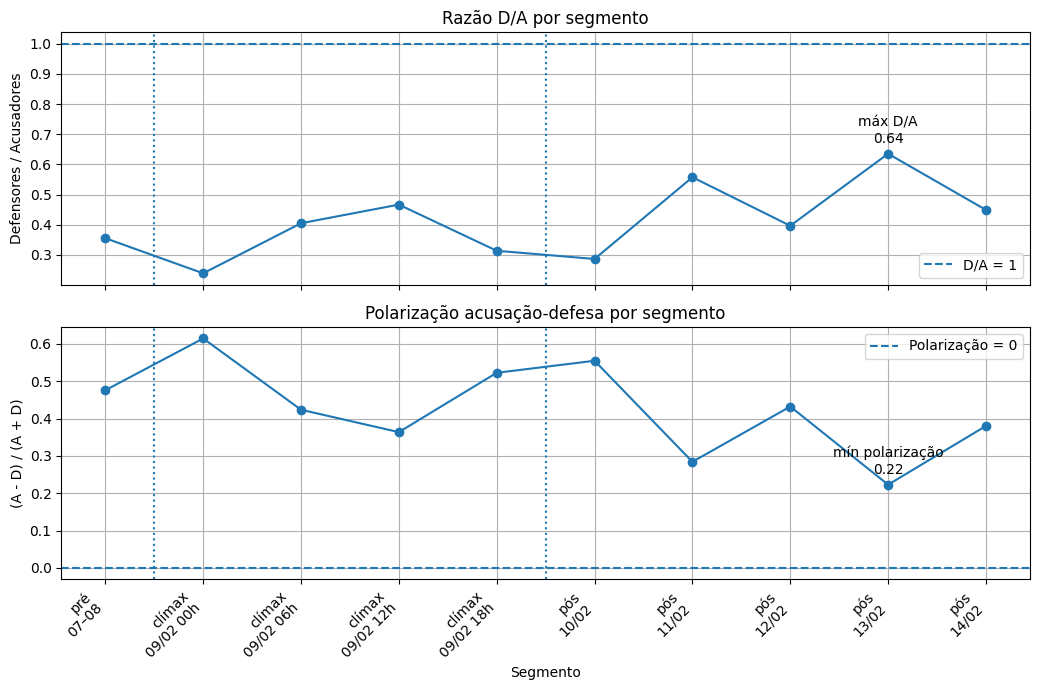

Maior D/A: post_2022_02_13 - 0.6354
Menor polarização: post_2022_02_13 - 0.2229


In [19]:
# Razão D/A e polarização por segmento

# Pré-condições
if "stance_seg" not in globals():
    raise RuntimeError(
        "A variável 'stance_seg' não existe na sessão. Rode antes a célula 29 — Mobilização por postura ao longo dos segmentos."
    )

plot_df = stance_seg.copy()

required_cols = [
    "segment_id", "phase_block", "acusador_count", "defensor_count"
]
missing = [c for c in required_cols if c not in plot_df.columns]
if missing:
    raise ValueError(f"Colunas ausentes em stance_seg: {missing}")

# Garantir ordenação temporal, se disponível
if "window_start" in plot_df.columns:
    plot_df = plot_df.sort_values("window_start").reset_index(drop=True)
else:
    plot_df = plot_df.reset_index(drop=True)

# Garantir rótulo de segmento
if "segment_label" not in plot_df.columns:
    if "window_start" in plot_df.columns:
        def make_segment_label(row):
            start = row["window_start"]
            if pd.notna(start):
                start_naive = start.tz_localize(None) if getattr(start, "tzinfo", None) is not None else start
            else:
                start_naive = None

            if row["phase_block"] == "pre":
                return "pré\n07–08"
            elif row["phase_block"] == "climax":
                return f"clímax\n{start_naive:%d/%m %Hh}" if start_naive is not None else "clímax"
            elif row["phase_block"] == "post":
                return f"pós\n{start_naive:%d/%m}" if start_naive is not None else "pós"
            return str(row["segment_id"])

        plot_df["segment_label"] = plot_df.apply(make_segment_label, axis=1)
    else:
        plot_df["segment_label"] = plot_df["segment_id"].astype(str)

A = plot_df["acusador_count"].astype(float)
D = plot_df["defensor_count"].astype(float)
AD = A + D

plot_df["da_ratio"] = np.where(A > 0, D / A, np.nan)
plot_df["polarizacao_ad"] = np.where(AD > 0, (A - D) / AD, np.nan)
plot_df["def_share_ad"] = np.where(AD > 0, D / AD, np.nan)

display(
    plot_df[
        [
            "segment_id", "phase_block",
            "acusador_count", "defensor_count",
            "da_ratio", "polarizacao_ad", "def_share_ad"
        ]
    ].round(4)
)

x = np.arange(len(plot_df))

fig, axes = plt.subplots(2, 1, figsize=(10.5, 7), sharex=True)

# Painel 1 — D/A
axes[0].plot(x, plot_df["da_ratio"], marker="o")
axes[0].axhline(1, linestyle="--", label="D/A = 1")
axes[0].set_title("Razão D/A por segmento")
axes[0].set_ylabel("Defensores / Acusadores")
axes[0].legend()

# Painel 2 — polarização
axes[1].plot(x, plot_df["polarizacao_ad"], marker="o")
axes[1].axhline(0, linestyle="--", label="Polarização = 0")
axes[1].set_title("Polarização acusação-defesa por segmento")
axes[1].set_ylabel("(A - D) / (A + D)")
axes[1].set_xlabel("Segmento")
axes[1].legend()

# Separadores de fase
phase_change_positions = plot_df.index[
    plot_df["phase_block"] != plot_df["phase_block"].shift(1)
].tolist()[1:]

for ax in axes:
    for pos in phase_change_positions:
        ax.axvline(pos - 0.5, linestyle=":")

# Anotações
max_da_idx = plot_df["da_ratio"].idxmax()
min_pol_idx = plot_df["polarizacao_ad"].idxmin()

axes[0].annotate(
    f"máx D/A\n{plot_df.loc[max_da_idx, 'da_ratio']:.2f}",
    xy=(max_da_idx, plot_df.loc[max_da_idx, "da_ratio"]),
    xytext=(0, 8),
    textcoords="offset points",
    ha="center"
)

axes[1].annotate(
    f"mín polarização\n{plot_df.loc[min_pol_idx, 'polarizacao_ad']:.2f}",
    xy=(min_pol_idx, plot_df.loc[min_pol_idx, "polarizacao_ad"]),
    xytext=(0, 8),
    textcoords="offset points",
    ha="center"
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df["segment_label"], rotation=45, ha="right")

plt.tight_layout()
plt.show()

print(
    "Maior D/A:",
    plot_df.loc[max_da_idx, "segment_id"],
    "-",
    round(plot_df.loc[max_da_idx, "da_ratio"], 4)
)

print(
    "Menor polarização:",
    plot_df.loc[min_pol_idx, "segment_id"],
    "-",
    round(plot_df.loc[min_pol_idx, "polarizacao_ad"], 4)
)

## Leitura da razão D/A e da polarização por segmento

A razão D/A e a polarização mostram que o caso permanece majoritariamente **acusatório** em todos os segmentos. Em nenhum momento a razão entre **defensores** e **acusadores** ultrapassa **1**, o que significa que os defensores nunca superam numericamente os acusadores. No `pré_0708`, a razão D/A já é relativamente baixa (**0,36**) e a polarização permanece positiva (**0,48**), indicando que o caso entra no período crítico com predominância acusatória.

No **clímax**, essa predominância se intensifica logo na primeira janela. Em `climax_6h_0000_0559`, a razão D/A cai para cerca de **0,24** e a polarização sobe para **0,61**, o maior valor da série, sugerindo que o início do auge é também o momento de maior assimetria entre acusação e defesa. Nas janelas seguintes do próprio clímax, a defesa cresce relativamente e a polarização diminui — sobretudo em `climax_6h_1200_1759`, com **D/A ≈ 0,47** e **polarização ≈ 0,36** —, mas ainda sem inverter a direção dominante do conflito.

No **pós-clímax**, aparecem os sinais mais claros de afrouxamento dessa assimetria. Em **11/02**, a razão D/A sobe para aproximadamente **0,56** e a polarização cai para **0,28**; em **13/02**, ocorre o ponto de maior aproximação relativa entre defesa e acusação, com **D/A ≈ 0,64** e a menor polarização da série (**0,22**). Esses valores sugerem que a defesa ganha mais espaço tardiamente, sobretudo em momentos de reativação posterior do caso.

Em termos analíticos, o gráfico indica que há **entrada e crescimento defensivo**, mas não uma **quebra da predominância acusatória**. A defesa reduz a assimetria em alguns segmentos, especialmente no pós-clímax, porém não chega a estabelecer maioria nem a empurrar a polarização para zero ou para o lado oposto. Assim, o caso parece combinar **pressão acusatória persistente** com **reação defensiva tardia e parcial**, mais capaz de atenuar o desequilíbrio do que de revertê-lo.

Sob a lente da teoria mimética, a persistência e o posterior crescimento dessa minoria defensora adquirem um peso estrutural decisivo: **ela atua como a força que obstrui a unanimidade exigida pelo mecanismo do bode expiatório**. Para que o rito sacrificial opere com eficácia fundadora plena, apagando os traços de sua própria violência e cristalizando o mito da culpa absoluta, é indispensável o fechamento perfeito do "todos contra um". O fato de a razão D/A recuar em seu momento de maior contágio (o clímax inicial), mas nunca ser anulada — e ainda ganhar tração nas janelas seguintes —, atesta que o linchamento digital não alcança esse consenso absoluto. A defesa, mesmo minoritária e incapaz de reverter a assimetria, fratura o monopólio da acusação e desvela o caráter persecutório do evento. Ao se colocar ao lado do alvo, essa voz dissonante impede que a expulsão se conclua como uma verdade inquestionável, deixando um rastro de contestação que sabota a resolução perfeita do sacrifício coletivo.

## Nota metodológica sobre a série temporal

A análise temporal foi organizada em dois produtos distintos:

**Série principal**
- baseline `pre` agregada de 07–08;
- quatro janelas `6h` do clímax em 09/02;
- cinco diários do pós-clímax entre 10/02 e 14/02.

**Zoom do clímax**
- um recorte `3h` adicional entre 08/02 21h e 23h59, usado como inspeção fina do entorno do pico.

Com isso, a interpretação principal fica ancorada na série `pre + 6h + pós diário`, enquanto o `3h` entra como complemento analítico para o clímax.

In [20]:
# Série principal de métricas por segmento (base para os gráficos de rede)

# Pré-condições
required_globals = ["main_manifest", "MAIN_INPUT_DIR", "SRC_DIR", "VICTIM_LABEL", "download_file"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Faltam variáveis necessárias para esta célula: "
        + ", ".join(missing_globals)
        + ". Rode antes as células de setup, manifesto temporal e funções auxiliares."
    )

wm_path = SRC_DIR / "windowed_metrics.py"
if not wm_path.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {wm_path}")

spec = importlib.util.spec_from_file_location("windowed_metrics_module", wm_path)
wm = importlib.util.module_from_spec(spec)
spec.loader.exec_module(wm)

def compute_segment_series(manifest_subset, cache_dir, victim_label):
    rows = []

    manifest_work = (
        manifest_subset
        .copy()
        .dropna(subset=["raw_url", "window_start", "window_end"])
        .sort_values("window_start")
        .reset_index(drop=True)
    )

    for _, row in manifest_work.iterrows():
        local_path = download_file(row["raw_url"], cache_dir)

        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="Could not infer format, so each element will be parsed individually.*"
            )
            df_seg = wm.load_events([str(local_path)])

        metrics = wm.compute_window_metrics(
            df_slice=df_seg,
            min_degree=0,
            victim_aliases=[victim_label],
            use_community=True
        )

        seg_start = pd.to_datetime(row["window_start"], utc=True)
        seg_end = pd.to_datetime(row["window_end"], utc=True)
        seg_hours = (seg_end - seg_start).total_seconds() / 3600

        metrics["segment_id"] = row["segment_id"]
        metrics["phase_block"] = row["phase_block"]
        metrics["granularity"] = row["granularity"]
        metrics["window_start"] = seg_start
        metrics["window_end"] = seg_end
        metrics["window_hours"] = seg_hours

        for base_col in ["n_edges", "n_tweets", "volume"]:
            if base_col in metrics:
                metrics[f"{base_col}_per_hour"] = (
                    metrics[base_col] / seg_hours if seg_hours > 0 else np.nan
                )

        rows.append(metrics)

    out = pd.DataFrame(rows).sort_values("window_start").reset_index(drop=True)

    for col in ["window_start", "window_end"]:
        out[col] = pd.to_datetime(out[col], utc=True).dt.tz_convert("America/Sao_Paulo")

    out["window_start_plot"] = out["window_start"].dt.tz_localize(None)
    out["window_end_plot"] = out["window_end"].dt.tz_localize(None)

    return out

series_main = compute_segment_series(main_manifest, MAIN_INPUT_DIR, VICTIM_LABEL)

def make_segment_label(row):
    start = row["window_start"]
    if pd.notna(start):
        start_naive = start.tz_localize(None) if getattr(start, "tzinfo", None) is not None else start
    else:
        start_naive = None

    if row["phase_block"] == "pre":
        return "pré\n07–08"
    elif row["phase_block"] == "climax":
        return f"clímax\n{start_naive:%d/%m %Hh}" if start_naive is not None else "clímax"
    elif row["phase_block"] == "post":
        return f"pós\n{start_naive:%d/%m}" if start_naive is not None else "pós"
    return str(row["segment_id"])

series_main["segment_label"] = series_main.apply(make_segment_label, axis=1)

# Tabela de leitura, sem alterar a base original
series_main_view = series_main.copy()

cols_to_round = [
    "window_hours",
    "density",
    "indeg_centralization",
    "top1_share_in",
    "modularity",
    "intercommunity_ratio",
    "ego_density",
    "ego_reciprocity",
    "n_edges_per_hour",
    "n_tweets_per_hour",
    "volume_per_hour"
]

for c in cols_to_round:
    if c in series_main_view.columns:
        series_main_view[c] = series_main_view[c].round(4)

display_cols = [
    "segment_id",
    "phase_block",
    "granularity",
    "segment_label",
    "window_hours",
    "n_nodes",
    "n_edges",
    "n_edges_per_hour",
    "indeg_centralization",
    "top1_share_in",
    "modularity",
    "intercommunity_ratio",
    "ego_density"
]

display_cols = [c for c in display_cols if c in series_main_view.columns]

print("Série principal — base para os gráficos de rede:")
display(series_main_view[display_cols])

print("series_main pronto:", len(series_main), "segmentos")

Série principal — base para os gráficos de rede:


,segment_id,phase_block,granularity,segment_label,window_hours,n_nodes,n_edges,n_edges_per_hour,indeg_centralization,top1_share_in,modularity,intercommunity_ratio,ego_density
0,pre_0708,pre,pre_agg,pré\n07–08,44.9997,2,1,0.0222,NaN,1.0000,0.0000,0.0000,1.0000
1,climax_6h_0000_0559,climax,6h,clímax\n09/02 00h,5.9997,219,279,46.5022,0.1654,0.1326,0.6353,0.1326,0.0526
2,climax_6h_0600_1159,climax,6h,clímax\n09/02 06h,5.9997,319,307,51.1690,0.0919,0.0977,0.8455,0.0293,0.0645
3,climax_6h_1200_1759,climax,6h,clímax\n09/02 12h,5.9997,357,345,57.5027,0.1046,0.1101,0.7782,0.0174,0.0513
4,climax_6h_1800_2359,climax,6h,clímax\n09/02 18h,5.9997,145,116,19.3342,0.1352,0.1724,0.8336,0.0603,0.1000
5,post_2022_02_10,post,1d,pós\n10/02,23.9997,108,89,3.7084,0.2302,0.2809,0.8129,0.0674,0.0800
6,post_2022_02_11,post,1d,pós\n11/02,23.9997,725,764,31.8337,0.3864,0.3665,0.7244,0.1427,0.0078
7,post_2022_02_12,post,1d,pós\n12/02,23.9997,434,414,17.2502,0.2159,0.2271,0.8057,0.1063,0.0231
8,post_2022_02_13,post,1d,pós\n13/02,23.9997,292,273,11.3751,0.1629,0.1758,0.8163,0.0879,0.0434
9,post_2022_02_14,post,1d,pós\n14/02,23.9997,563,597,24.8753,0.4302,0.4054,0.6823,0.1441,0.0088


series_main pronto: 10 segmentos


## Da tabela-base aos gráficos de rede

A tabela acima funciona como **base analítica** das métricas de rede por segmento. Ela é importante para auditoria e transparência, mas a leitura substantiva do caso fica mais clara quando essas medidas são desdobradas em gráficos específicos.

A partir daqui, a análise passa da visão tabular para a visão visual. O próximo gráfico começa pela dimensão mais direta da hipótese: **a intensidade relacional**, isto é, o ritmo com que as interações se acumulam ao longo do caso. Em seguida, as demais métricas serão lidas como variações de **concentração da atenção**, **reorganização estrutural da rede** e **posição relacional da vítima**.

Em termos práticos, esta transição sinaliza que a tabela não é o ponto final da interpretação. Ela resume os valores; os gráficos seguintes mostram **onde o caso acelera, onde a atenção se reconcentra e em que momentos a rede se aproxima mais de uma dinâmica de convergência vitimária**.

,segment_id,phase_block,granularity,n_edges,window_hours,n_edges_per_hour
0,pre_0708,pre,pre_agg,1,44.9997,0.0222
1,climax_6h_0000_0559,climax,6h,279,5.9997,46.5022
2,climax_6h_0600_1159,climax,6h,307,5.9997,51.1690
3,climax_6h_1200_1759,climax,6h,345,5.9997,57.5027
4,climax_6h_1800_2359,climax,6h,116,5.9997,19.3342
5,post_2022_02_10,post,1d,89,23.9997,3.7084
6,post_2022_02_11,post,1d,764,23.9997,31.8337
7,post_2022_02_12,post,1d,414,23.9997,17.2502
8,post_2022_02_13,post,1d,273,23.9997,11.3751
9,post_2022_02_14,post,1d,597,23.9997,24.8753


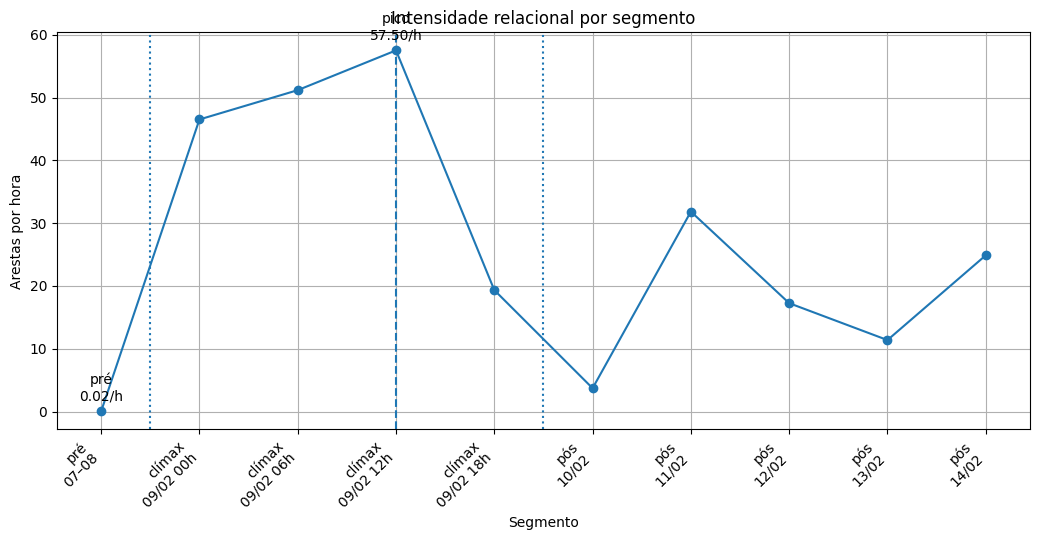

Pico de intensidade: climax_6h_1200_1759 - 57.5027 arestas/h
Baseline pré-clímax: pre_0708 - 0.0222 arestas/h


In [21]:
# Intensidade relacional por segmento

# Pré-condições
if "series_main" not in globals():
    raise RuntimeError(
        "A variável 'series_main' não existe na sessão. Rode antes a célula 33 — Série principal de métricas por segmento."
    )

plot_df = series_main.copy()

required_cols = ["segment_id", "phase_block", "n_edges", "window_hours"]
missing = [c for c in required_cols if c not in plot_df.columns]
if missing:
    raise ValueError(f"Colunas ausentes em series_main: {missing}")

# Garantir ordenação temporal
if "window_start" in plot_df.columns:
    plot_df = plot_df.sort_values("window_start").reset_index(drop=True)
else:
    plot_df = plot_df.reset_index(drop=True)

# Garantir métrica por hora
if "n_edges_per_hour" not in plot_df.columns:
    plot_df["n_edges_per_hour"] = np.where(
        plot_df["window_hours"] > 0,
        plot_df["n_edges"] / plot_df["window_hours"],
        np.nan
    )

# Garantir rótulo de segmento
if "segment_label" not in plot_df.columns:
    if "window_start" in plot_df.columns:
        def make_segment_label(row):
            start = row["window_start"]
            if pd.notna(start):
                start_naive = start.tz_localize(None) if getattr(start, "tzinfo", None) is not None else start
            else:
                start_naive = None

            if row["phase_block"] == "pre":
                return "pré\n07–08"
            elif row["phase_block"] == "climax":
                return f"clímax\n{start_naive:%d/%m %Hh}" if start_naive is not None else "clímax"
            elif row["phase_block"] == "post":
                return f"pós\n{start_naive:%d/%m}" if start_naive is not None else "pós"
            return str(row["segment_id"])

        plot_df["segment_label"] = plot_df.apply(make_segment_label, axis=1)
    else:
        plot_df["segment_label"] = plot_df["segment_id"].astype(str)

# Tabela curta de apoio
view_cols = [
    "segment_id",
    "phase_block",
    "granularity",
    "n_edges",
    "window_hours",
    "n_edges_per_hour"
]
view_cols = [c for c in view_cols if c in plot_df.columns]

display(plot_df[view_cols].round(4))

x = np.arange(len(plot_df))
y = plot_df["n_edges_per_hour"].to_numpy()

fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.plot(x, y, marker="o")
ax.axvline(plot_df["n_edges_per_hour"].idxmax(), linestyle="--")

# Separadores de fase
phase_change_positions = plot_df.index[
    plot_df["phase_block"] != plot_df["phase_block"].shift(1)
].tolist()[1:]

for pos in phase_change_positions:
    ax.axvline(pos - 0.5, linestyle=":")

# Baseline pré e pico
peak_idx = plot_df["n_edges_per_hour"].idxmax()
peak_y = plot_df.loc[peak_idx, "n_edges_per_hour"]

pre_rows = plot_df.index[plot_df["phase_block"] == "pre"].tolist()
pre_idx = pre_rows[0] if pre_rows else None
pre_y = plot_df.loc[pre_idx, "n_edges_per_hour"] if pre_idx is not None else np.nan

ax.annotate(
    f"pico\n{peak_y:.2f}/h",
    xy=(peak_idx, peak_y),
    xytext=(0, 8),
    textcoords="offset points",
    ha="center"
)

if pre_idx is not None and pd.notna(pre_y):
    ax.annotate(
        f"pré\n{pre_y:.2f}/h",
        xy=(pre_idx, pre_y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

ax.set_xticks(x)
ax.set_xticklabels(plot_df["segment_label"], rotation=45, ha="right")
ax.set_title("Intensidade relacional por segmento")
ax.set_xlabel("Segmento")
ax.set_ylabel("Arestas por hora")
plt.tight_layout()
plt.show()

print(
    "Pico de intensidade:",
    plot_df.loc[peak_idx, "segment_id"],
    "-",
    round(plot_df.loc[peak_idx, "n_edges_per_hour"], 4),
    "arestas/h"
)

if pre_idx is not None and pd.notna(pre_y):
    print(
        "Baseline pré-clímax:",
        plot_df.loc[pre_idx, "segment_id"],
        "-",
        round(pre_y, 4),
        "arestas/h"
    )

## Leitura da intensidade relacional por segmento

A intensidade relacional mostra uma ruptura muito nítida entre o **pré-clímax** e o **clímax**. No segmento `pre_0708`, a série registra apenas **0,02 arestas por hora**, o que indica uma atividade relacional praticamente residual na escala adotada para esta análise. A mudança ocorre de forma abrupta no dia **09/02**: `climax_6h_0000_0559` sobe para cerca de **46,50 arestas por hora**, `climax_6h_0600_1159` avança para **51,17** e o pico aparece em `climax_6h_1200_1759`, com aproximadamente **57,50 arestas por hora**. Isso sugere que o caso entra, no centro do clímax, em um regime de forte aceleração interacional.

Na última janela do próprio clímax, `climax_6h_1800_2359`, a intensidade cai para cerca de **19,33 arestas por hora**, sinalizando que o arrefecimento começa ainda no mesmo dia. No **pós-clímax**, a retração continua em **10/02**, com aproximadamente **3,71 arestas por hora**, mas não de maneira linear nem definitiva. Em **11/02**, há um repique expressivo para **31,83 arestas por hora**, seguido por níveis intermediários em **12/02** (**17,25**), **13/02** (**11,38**) e nova elevação em **14/02** (**24,88**).

Em termos analíticos, o gráfico indica uma dinâmica de **explosão relacional no clímax**, seguida por **descompressão incompleta** e **reativações posteriores**. O caso, portanto, não parece se esgotar no primeiro pico de 09/02: a máxima aceleração ocorre nesse momento, mas a rede continua capaz de reacender nos dias seguintes. Como primeira métrica de rede, a intensidade relacional estabelece o “batimento” do episódio e prepara a etapa seguinte da análise, em que importa observar não apenas quanto a rede se move, mas **como a atenção se concentra dentro dela**.

,segment_id,phase_block,n_edges_per_hour,indeg_centralization,top1_share_in,intercommunity_ratio,modularity,ego_density
0,pre_0708,pre,0.0222,NaN,NaN,NaN,NaN,NaN
1,climax_6h_0000_0559,climax,46.5022,0.1654,0.1326,0.1326,0.6353,0.0526
2,climax_6h_0600_1159,climax,51.1690,0.0919,0.0977,0.0293,0.8455,0.0645
3,climax_6h_1200_1759,climax,57.5027,0.1046,0.1101,0.0174,0.7782,0.0513
4,climax_6h_1800_2359,climax,19.3342,0.1352,0.1724,0.0603,0.8336,0.1000
5,post_2022_02_10,post,3.7084,0.2302,0.2809,0.0674,0.8129,0.0800
6,post_2022_02_11,post,31.8337,0.3864,0.3665,0.1427,0.7244,0.0078
7,post_2022_02_12,post,17.2502,0.2159,0.2271,0.1063,0.8057,0.0231
8,post_2022_02_13,post,11.3751,0.1629,0.1758,0.0879,0.8163,0.0434
9,post_2022_02_14,post,24.8753,0.4302,0.4054,0.1441,0.6823,0.0088


/tmp/ipykernel_644/2922095672.py:185: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("YlOrRd").copy()


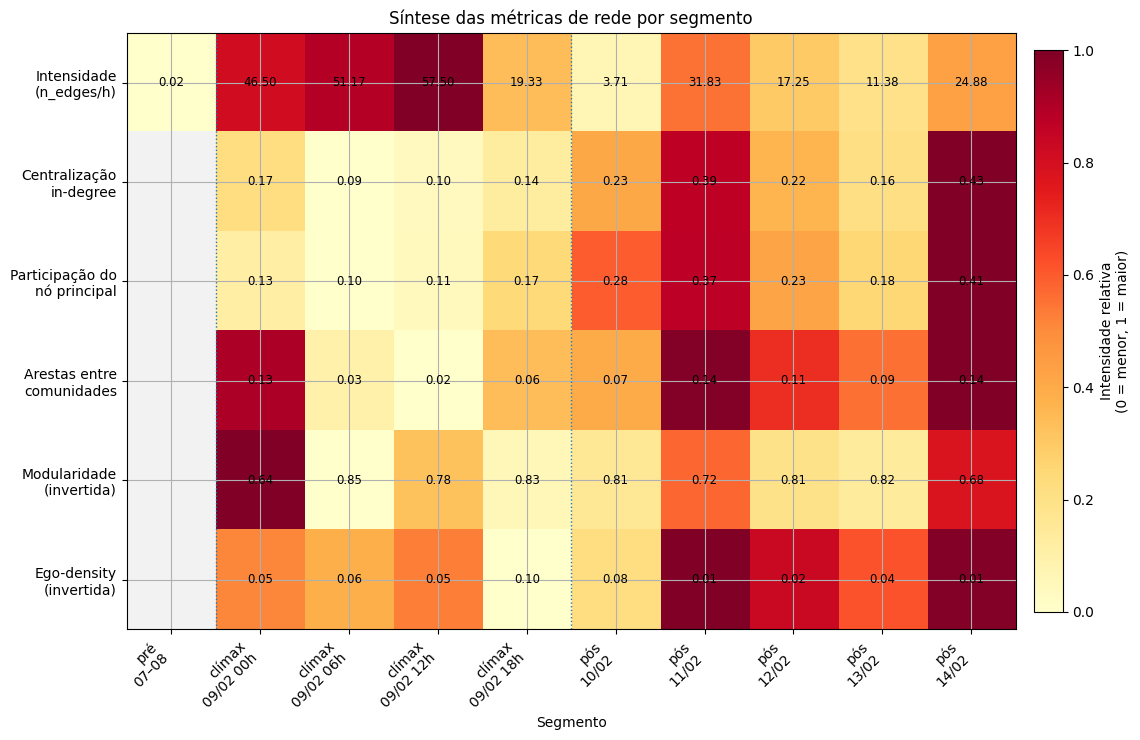

Observação 1: valores dentro das células são os valores brutos das métricas.
Observação 2: a cor é uma escala relativa por linha, já orientada na direção analítica.
Observação 3: 'Modularidade (invertida)' e 'Ego-density (invertida)' ficam mais quentes quando os valores brutos são menores.
Observação 4: métricas topológicas são ocultadas em segmentos estruturalmente minúsculos para evitar distorções.


In [22]:
# Síntese das métricas de rede por segmento (heatmap)

# Pré-condições
if "series_main" not in globals():
    raise RuntimeError(
        "A variável 'series_main' não existe na sessão. Rode antes a célula 33 — Série principal de métricas por segmento."
    )

plot_df = series_main.copy()

required_cols = ["segment_id", "phase_block", "n_edges", "window_hours"]
missing = [c for c in required_cols if c not in plot_df.columns]
if missing:
    raise ValueError(f"Colunas ausentes em series_main: {missing}")

# Ordenação temporal
if "window_start" in plot_df.columns:
    plot_df = plot_df.sort_values("window_start").reset_index(drop=True)
else:
    plot_df = plot_df.reset_index(drop=True)

# Garantir rótulo de segmento
if "segment_label" not in plot_df.columns:
    if "window_start" in plot_df.columns:
        def make_segment_label(row):
            start = row["window_start"]
            if pd.notna(start):
                start_naive = start.tz_localize(None) if getattr(start, "tzinfo", None) is not None else start
            else:
                start_naive = None

            if row["phase_block"] == "pre":
                return "pré\n07–08"
            elif row["phase_block"] == "climax":
                return f"clímax\n{start_naive:%d/%m %Hh}" if start_naive is not None else "clímax"
            elif row["phase_block"] == "post":
                return f"pós\n{start_naive:%d/%m}" if start_naive is not None else "pós"
            return str(row["segment_id"])

        plot_df["segment_label"] = plot_df.apply(make_segment_label, axis=1)
    else:
        plot_df["segment_label"] = plot_df["segment_id"].astype(str)

# Garantir intensidade por hora
if "n_edges_per_hour" not in plot_df.columns:
    plot_df["n_edges_per_hour"] = np.where(
        plot_df["window_hours"] > 0,
        plot_df["n_edges"] / plot_df["window_hours"],
        np.nan
    )

# Configuração das métricas:
# direction = 1  -> valores maiores = mais compatíveis com convergência vitimária
# direction = -1 -> valores menores = mais compatíveis com convergência vitimária
metric_specs = [
    {
        "col": "n_edges_per_hour",
        "label": "Intensidade\n(n_edges/h)",
        "direction": 1,
        "topology_metric": False
    },
    {
        "col": "indeg_centralization",
        "label": "Centralização\nin-degree",
        "direction": 1,
        "topology_metric": True
    },
    {
        "col": "top1_share_in",
        "label": "Participação do\nnó principal",
        "direction": 1,
        "topology_metric": True
    },
    {
        "col": "intercommunity_ratio",
        "label": "Arestas entre\ncomunidades",
        "direction": 1,
        "topology_metric": True
    },
    {
        "col": "modularity",
        "label": "Modularidade\n(invertida)",
        "direction": -1,
        "topology_metric": True
    },
    {
        "col": "ego_density",
        "label": "Ego-density\n(invertida)",
        "direction": -1,
        "topology_metric": True
    },
]

# Se quiser incluir distância média à vítima quando existir:
if "avg_dist" in plot_df.columns:
    metric_specs.append(
        {
            "col": "avg_dist",
            "label": "Distância média\nà vítima",
            "direction": 1,
            "topology_metric": True
        }
    )

metric_specs = [m for m in metric_specs if m["col"] in plot_df.columns]

# Máscara para segmentos estruturalmente muito pequenos:
# evita que o pré-clímax trivial (ou qualquer segmento minúsculo) distorça
# métricas topológicas como centralização, modularidade e ego-density
if {"n_nodes", "n_edges"}.issubset(plot_df.columns):
    degenerate_mask = (plot_df["n_nodes"] < 10) | (plot_df["n_edges"] < 5)
else:
    degenerate_mask = pd.Series(False, index=plot_df.index)

# Base bruta para auditoria
heatmap_main_raw = plot_df[
    ["segment_id", "phase_block", "segment_label"] + [m["col"] for m in metric_specs]
].copy()

for m in metric_specs:
    if m["topology_metric"]:
        heatmap_main_raw.loc[degenerate_mask, m["col"]] = np.nan

display_cols = ["segment_id", "phase_block"] + [m["col"] for m in metric_specs]
display(heatmap_main_raw[display_cols].round(4))

# Função de normalização min-max na direção analítica correta
def oriented_minmax(series, direction):
    s = series.astype(float).copy()

    # inverter quando "menos" significa "mais convergência"
    if direction == -1:
        s = -s

    valid = s.dropna()
    out = pd.Series(np.nan, index=series.index, dtype=float)

    if valid.empty:
        return out

    vmin = valid.min()
    vmax = valid.max()

    if np.isclose(vmin, vmax):
        out.loc[series.notna()] = 0.5
        return out

    out.loc[series.notna()] = (s.loc[series.notna()] - vmin) / (vmax - vmin)
    return out

# Montar matriz normalizada e anotações em valor bruto
row_labels = []
heat_rows = []
annot_rows = []

for m in metric_specs:
    raw_series = heatmap_main_raw[m["col"]]
    scaled_series = oriented_minmax(raw_series, m["direction"])

    row_labels.append(m["label"])
    heat_rows.append(scaled_series.to_numpy())

    annot = []
    for val in raw_series:
        if pd.isna(val):
            annot.append("")
        else:
            annot.append(f"{val:.2f}")
    annot_rows.append(annot)

heat_matrix = np.array(heat_rows, dtype=float)

heatmap_main_scaled = pd.DataFrame(
    heat_matrix,
    index=row_labels,
    columns=heatmap_main_raw["segment_id"].tolist()
)

# Plot
try:
    cmap = plt.cm.get_cmap("YlOrRd").copy()
except AttributeError:
    cmap = plt.cm.get_cmap("YlOrRd")

if hasattr(cmap, "set_bad"):
    cmap.set_bad("#f2f2f2")

masked_matrix = np.ma.masked_invalid(heat_matrix)

fig_height = 4.2 + 0.55 * len(row_labels)
fig, ax = plt.subplots(figsize=(11.5, fig_height))

im = ax.imshow(
    masked_matrix,
    aspect="auto",
    interpolation="nearest",
    cmap=cmap,
    vmin=0,
    vmax=1
)

# Anotações
for i in range(masked_matrix.shape[0]):
    for j in range(masked_matrix.shape[1]):
        txt = annot_rows[i][j]
        if txt != "":
            ax.text(j, i, txt, ha="center", va="center", fontsize=8.5, color="black")

# Separadores de fase
phase_change_positions = heatmap_main_raw.index[
    heatmap_main_raw["phase_block"] != heatmap_main_raw["phase_block"].shift(1)
].tolist()[1:]

for pos in phase_change_positions:
    ax.axvline(pos - 0.5, linestyle=":", linewidth=1)

ax.set_xticks(np.arange(len(heatmap_main_raw)))
ax.set_xticklabels(heatmap_main_raw["segment_label"], rotation=45, ha="right")
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels)

ax.set_title("Síntese das métricas de rede por segmento")
ax.set_xlabel("Segmento")

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Intensidade relativa\n(0 = menor, 1 = maior)")

plt.tight_layout()
plt.show()

print("Observação 1: valores dentro das células são os valores brutos das métricas.")
print("Observação 2: a cor é uma escala relativa por linha, já orientada na direção analítica.")
print("Observação 3: 'Modularidade (invertida)' e 'Ego-density (invertida)' ficam mais quentes quando os valores brutos são menores.")
print("Observação 4: métricas topológicas são ocultadas em segmentos estruturalmente minúsculos para evitar distorções.")

# Leitura sintética das métricas de rede por segmento

O heatmap resume, em uma única visualização, dimensões complementares da hipótese. Como cada linha foi orientada na mesma direção analítica, os tons mais quentes indicam, dentro de cada métrica, maior compatibilidade relativa com convergência vitimária. No pre_0708, as métricas topológicas aparecem em branco porque esse segmento é estruturalmente pequeno demais para uma comparação confiável; por isso, a leitura substantiva começa no clímax. Mais importante, o painel não deve ser lido como se todas as assinaturas do mecanismo vitimário precisassem aparecer ao mesmo tempo, no mesmo ponto da crise. À luz da teoria mimética, é plausível interpretar essas métricas como momentos distintos de um mesmo processo: **intensificação relacional, fixação do alvo, oscilação da diferenciação entre grupos e resíduo sacrificial**.

A primeira dimensão é a intensidade relacional. Nela, o padrão é muito claro: a rede salta de um pré-clímax residual para valores muito altos nas janelas de 09/02, com pico em climax_6h_1200_1759 (57,50 arestas por hora). Depois há queda, mas não dissipação completa: o caso volta a aquecer em 11/02 (31,83) e 14/02 (24,88). Isso sugere que o episódio tem um auge forte no clímax, seguido por reativações posteriores, e não um encerramento linear logo após o primeiro pico. Em termos miméticos, o clímax concentra a explosão do contágio, enquanto o pós-clímax preserva ressonâncias e reativações do mesmo foco sacrificial.

A segunda dimensão é a concentração da atenção. Aqui, o padrão é mais interessante do que um simples “pico no clímax”. A centralização in-degree não atinge seu máximo no centro de 09/02, mas no pós-clímax, sobretudo em 11/02 (0,39) e 14/02 (0,43). O mesmo ocorre com a participação do nó principal, que sobe para 0,37 em 11/02 e para cerca de 0,41 em 14/02, acima dos valores do clímax. Em vez de enfraquecer a hipótese, isso pode ser lido como sinal de que a vítima permanece como polo organizador da crise mesmo após o auge inicial do volume. Uma interpretação compatível com a teoria mimética é que a convergência massiva do clímax seja precedida e depois sustentada por perfis mais influentes, que ajudam a apontar, estabilizar e reativar o alvo ao longo do caso.

A terceira dimensão é a estrutura comunitária. A linha de arestas entre comunidades mostra que o cruzamento entre grupos é especialmente forte em climax_6h_0000_0559 (0,14), volta a subir em 11/02 (0,14) e alcança novo máximo relativo em 14/02 (0,16). Já a linha de modularidade (invertida) fica mais quente quando a modularidade bruta é menor; por isso, o primeiro segmento do clímax, com modularidade em torno de 0,64, aparece como um dos momentos de maior enfraquecimento da diferenciação comunitária, seguido novamente por 14/02 (0,68) e 11/02 (0,72). Isso indica que a perda de separação entre comunidades existe, mas de modo intermitente, não contínuo ao longo de todo o clímax. Em vez de exigir um colapso estrutural homogêneo, a leitura mimética pode entender essas oscilações como momentos localizados de suspensão parcial das fronteiras entre grupos em torno do mesmo alvo.

A quarta dimensão é a posição relacional da vítima. A linha de ego-density (invertida) fica mais quente quando a densidade bruta do entorno da vítima é menor. Nesse critério, os momentos mais fortes não estão no centro do clímax, mas no pós-clímax, especialmente em 11/02 (0,01) e 14/02 (0,01), com valores também relativamente baixos em 12/02 (0,02). Isso não precisa ser lido como fragilidade da hipótese. Durante o auge do linchamento, é até plausível que o **entorno da vítima se torne momentaneamente mais denso, porque muitos atores convergem sobre ela ao mesmo tempo e também interagem entre si**. A rarefação mais clara no pós-clímax pode ser interpretada, então, como resíduo sacrificial: **depois da convergência máxima, o entorno da vítima permanece empobrecido, pouco coeso e estruturalmente marcado pelo episódio**.

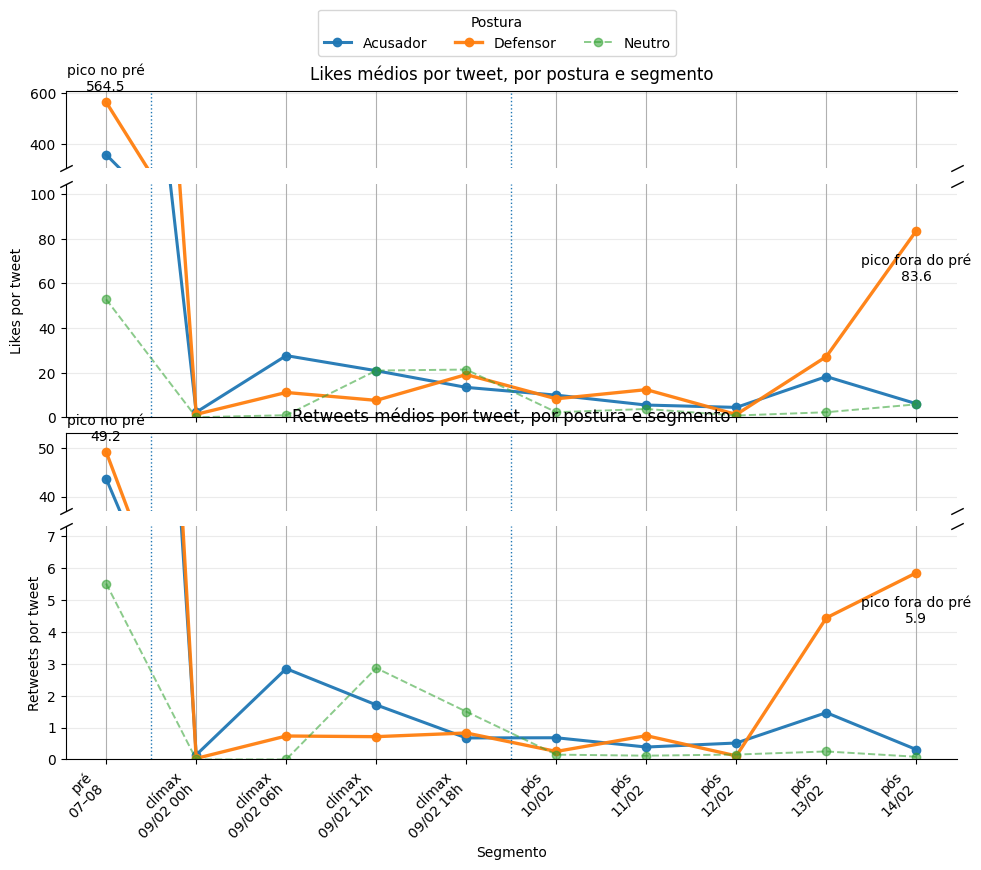

Maior likes/tweet entre defensores: pre_0708 - 564.5315
Maior retweets/tweet entre defensores: pre_0708 - 49.1608


In [23]:
# Engajamento médio por postura ao longo dos segmentos
# (versão visual refinada, com eixo quebrado)

# Pré-condições
if "df" not in globals():
    raise RuntimeError(
        "A variável 'df' não existe na sessão. Rode antes a célula 21 — Pré-processamento principal do bruto consolidado."
    )

if "main_manifest" not in globals():
    raise RuntimeError(
        "A variável 'main_manifest' não existe na sessão. Rode antes a célula 12 — Manifesto temporal."
    )

if "stance" not in df.columns:
    raise ValueError("A coluna 'stance' não existe em df.")

like_col = None
if "like_count" in df.columns:
    like_col = "like_count"
elif "favorite_count" in df.columns:
    like_col = "favorite_count"

if like_col is None:
    raise ValueError("Não encontrei coluna de likes ('like_count' ou 'favorite_count') em df.")

if "retweet_count" not in df.columns:
    raise ValueError("A coluna 'retweet_count' não existe em df.")

plot_df = df.copy()

# Garantir tempo em São Paulo
if "created_at_sp" not in plot_df.columns:
    date_col = "created_at_iso" if "created_at_iso" in plot_df.columns else "created_at"
    plot_df[date_col] = pd.to_datetime(plot_df[date_col], utc=True, errors="coerce")
    plot_df["created_at_sp"] = plot_df[date_col].dt.tz_convert("America/Sao_Paulo")

plot_df = plot_df.dropna(subset=["created_at_sp"]).copy()

# Padronizar postura
plot_df["stance"] = (
    plot_df["stance"]
    .astype("string")
    .str.strip()
    .str.lower()
)

stance_order = ["acusador", "defensor", "neutro"]
plot_df = plot_df[plot_df["stance"].isin(stance_order)].copy()

# Garantir numéricos
for col in [like_col, "retweet_count"]:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce").fillna(0)

# Segmentos da série principal
segments = (
    main_manifest
    .copy()
    .dropna(subset=["window_start", "window_end"])
    .sort_values("window_start")
    .reset_index(drop=True)
)

segments["window_start"] = pd.to_datetime(segments["window_start"], utc=True).dt.tz_convert("America/Sao_Paulo")
segments["window_end"] = pd.to_datetime(segments["window_end"], utc=True).dt.tz_convert("America/Sao_Paulo")

def make_segment_label(row):
    start = row["window_start"].tz_localize(None)
    if row["phase_block"] == "pre":
        return "pré\n07–08"
    elif row["phase_block"] == "climax":
        return f"clímax\n{start:%d/%m %Hh}"
    elif row["phase_block"] == "post":
        return f"pós\n{start:%d/%m}"
    return str(row["segment_id"])

rows = []
for _, seg_row in segments.iterrows():
    mask = plot_df["created_at_sp"].between(seg_row["window_start"], seg_row["window_end"], inclusive="both")
    seg_df = plot_df.loc[mask].copy()

    for stance in stance_order:
        sub = seg_df.loc[seg_df["stance"] == stance].copy()

        rows.append({
            "segment_id": seg_row["segment_id"],
            "phase_block": seg_row["phase_block"],
            "granularity": seg_row["granularity"],
            "window_start": seg_row["window_start"],
            "segment_label": make_segment_label(seg_row),
            "stance": stance,
            "n_tweets": len(sub),
            "likes_por_tweet": sub[like_col].mean() if len(sub) > 0 else np.nan,
            "retweets_por_tweet": sub["retweet_count"].mean() if len(sub) > 0 else np.nan,
            "likes_totais": sub[like_col].sum() if len(sub) > 0 else 0,
            "retweets_totais": sub["retweet_count"].sum() if len(sub) > 0 else 0,
        })

engagement_seg = pd.DataFrame(rows)

# Bases em formato wide
plot_wide_likes = (
    engagement_seg
    .pivot_table(index="segment_id", columns="stance", values="likes_por_tweet", aggfunc="mean")
    .reindex(segments["segment_id"])
)

plot_wide_rts = (
    engagement_seg
    .pivot_table(index="segment_id", columns="stance", values="retweets_por_tweet", aggfunc="mean")
    .reindex(segments["segment_id"])
)

segment_labels = segments.apply(make_segment_label, axis=1).tolist()
x = np.arange(len(segments))

# Estilo
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_map = {
    "acusador": default_colors[0],
    "defensor": default_colors[1] if len(default_colors) > 1 else default_colors[0],
    "neutro": default_colors[2] if len(default_colors) > 2 else "gray",
}
style_map = {
    "acusador": {"linewidth": 2.2, "alpha": 0.95, "linestyle": "-", "marker": "o"},
    "defensor": {"linewidth": 2.4, "alpha": 0.95, "linestyle": "-", "marker": "o"},
    "neutro": {"linewidth": 1.4, "alpha": 0.55, "linestyle": "--", "marker": "o"},
}

def get_break_cfg(values):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals >= 0]

    if len(vals) < 4:
        return None

    vals = np.sort(vals)
    max1 = vals[-1]
    max2 = vals[-2]
    max3 = vals[-3]

    # Aciona eixo quebrado quando há um "cluster" de outliers bem acima do resto
    if max2 > 2.2 * max3:
        low_max = max3 * 1.25
        high_min = max2 * 0.85
        high_max = max1 * 1.08

        if high_min > low_max:
            return low_max, high_min, high_max

    return None

def add_phase_separators(ax):
    phase_change_positions = segments.index[
        segments["phase_block"] != segments["phase_block"].shift(1)
    ].tolist()[1:]

    for pos in phase_change_positions:
        ax.axvline(pos - 0.5, linestyle=":", linewidth=1)

def add_break_marks(ax_top, ax_bottom):
    d = 0.5
    kwargs = dict(
        marker=[(-1, -d), (1, d)],
        markersize=9,
        linestyle="none",
        color="black",
        mec="black",
        mew=1,
        clip_on=False
    )
    ax_top.plot([0, 1], [0, 0], transform=ax_top.transAxes, **kwargs)
    ax_bottom.plot([0, 1], [1, 1], transform=ax_bottom.transAxes, **kwargs)

def plot_metric(ax_top, ax_bottom, wide_df, title, ylabel, break_cfg):
    handles = []
    labels = []

    for stance in stance_order:
        if stance not in wide_df.columns:
            continue

        y = wide_df[stance].reindex(segments["segment_id"]).to_numpy(dtype=float)
        kwargs = style_map[stance].copy()
        color = color_map[stance]

        h, = ax_bottom.plot(x, y, color=color, label=stance.capitalize(), **kwargs)
        ax_top.plot(x, y, color=color, **kwargs)

        handles.append(h)
        labels.append(stance.capitalize())

    # aparência
    for ax in [ax_top, ax_bottom]:
        ax.grid(axis="y", alpha=0.25)
        ax.spines["right"].set_visible(False)
        add_phase_separators(ax)

    ax_top.set_title(title, pad=8)
    ax_bottom.set_ylabel(ylabel)

    if break_cfg is None:
        ymax = np.nanmax(wide_df.to_numpy(dtype=float))
        if not np.isfinite(ymax):
            ymax = 1.0

        ax_bottom.set_ylim(0, ymax * 1.10)
        ax_top.set_visible(False)
    else:
        low_max, high_min, high_max = break_cfg

        ax_bottom.set_ylim(0, low_max)
        ax_top.set_ylim(high_min, high_max)

        ax_top.spines["bottom"].set_visible(False)
        ax_bottom.spines["top"].set_visible(False)

        ax_top.tick_params(labeltop=False, bottom=False)
        ax_bottom.xaxis.tick_bottom()

        add_break_marks(ax_top, ax_bottom)

    return handles, labels

def annotate_defender_peaks(wide_df, ax_top, ax_bottom, break_cfg):
    if "defensor" not in wide_df.columns:
        return

    y = wide_df["defensor"].reindex(segments["segment_id"]).to_numpy(dtype=float)
    valid = np.where(np.isfinite(y))[0]

    if len(valid) == 0:
        return

    # Pico global
    idx_global = valid[np.argmax(y[valid])]
    y_global = y[idx_global]

    target_ax = ax_bottom
    if break_cfg is not None and ax_top.get_visible():
        if y_global >= ax_top.get_ylim()[0]:
            target_ax = ax_top

    label_global = "pico no pré" if segments.loc[idx_global, "phase_block"] == "pre" else "pico"
    target_ax.annotate(
        f"{label_global}\n{y_global:.1f}",
        xy=(idx_global, y_global),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

    # Pico fora do pré
    valid_non_pre = np.array([i for i in valid if segments.loc[i, "phase_block"] != "pre"])
    if len(valid_non_pre) > 0:
        idx_non_pre = valid_non_pre[np.argmax(y[valid_non_pre])]
        y_non_pre = y[idx_non_pre]

        if idx_non_pre != idx_global:
            ax_bottom.annotate(
                f"pico fora do pré\n{y_non_pre:.1f}",
                xy=(idx_non_pre, y_non_pre),
                xytext=(0, -16),
                textcoords="offset points",
                ha="center",
                va="top"
            )

likes_break = get_break_cfg(engagement_seg["likes_por_tweet"].to_numpy())
rts_break = get_break_cfg(engagement_seg["retweets_por_tweet"].to_numpy())

fig = plt.figure(figsize=(11.5, 8.8))
gs = GridSpec(4, 1, figure=fig, height_ratios=[1.0, 3.0, 1.0, 3.0], hspace=0.10)

ax_l_top = fig.add_subplot(gs[0, 0])
ax_l_bottom = fig.add_subplot(gs[1, 0], sharex=ax_l_top)
ax_r_top = fig.add_subplot(gs[2, 0], sharex=ax_l_top)
ax_r_bottom = fig.add_subplot(gs[3, 0], sharex=ax_l_top)

handles, labels = plot_metric(
    ax_l_top,
    ax_l_bottom,
    plot_wide_likes,
    "Likes médios por tweet, por postura e segmento",
    "Likes por tweet",
    likes_break
)

plot_metric(
    ax_r_top,
    ax_r_bottom,
    plot_wide_rts,
    "Retweets médios por tweet, por postura e segmento",
    "Retweets por tweet",
    rts_break
)

annotate_defender_peaks(plot_wide_likes, ax_l_top, ax_l_bottom, likes_break)
annotate_defender_peaks(plot_wide_rts, ax_r_top, ax_r_bottom, rts_break)

# Rótulos do eixo x só no último painel
for ax in [ax_l_top, ax_l_bottom, ax_r_top]:
    plt.setp(ax.get_xticklabels(), visible=False)

ax_r_bottom.set_xticks(x)
ax_r_bottom.set_xticklabels(segment_labels, rotation=45, ha="right")
ax_r_bottom.set_xlabel("Segmento")

# Legenda única
fig.legend(
    handles,
    labels,
    title="Postura",
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    frameon=True
)

fig.subplots_adjust(top=0.88, bottom=0.12, hspace=0.12)
plt.show()

# Resumo curto para apoio à leitura
def_summary = engagement_seg[engagement_seg["stance"] == "defensor"].copy()

if not def_summary["likes_por_tweet"].dropna().empty:
    idx = def_summary["likes_por_tweet"].idxmax()
    print(
        "Maior likes/tweet entre defensores:",
        def_summary.loc[idx, "segment_id"],
        "-",
        round(def_summary.loc[idx, "likes_por_tweet"], 4)
    )

if not def_summary["retweets_por_tweet"].dropna().empty:
    idx = def_summary["retweets_por_tweet"].idxmax()
    print(
        "Maior retweets/tweet entre defensores:",
        def_summary.loc[idx, "segment_id"],
        "-",
        round(def_summary.loc[idx, "retweets_por_tweet"], 4)
    )

## Leitura do engajamento por postura ao longo dos segmentos

Os gráficos de engajamento mostram que **volume** e **performance simbólica** não são a mesma coisa. Nos dois painéis, o `pre_0708` aparece como um ponto fora da curva, com médias muito altas de **likes por tweet** e **retweets por tweet**, especialmente entre os **defensores**. Por isso, a leitura substantiva mais importante está na comparação entre os segmentos do **clímax** e do **pós-clímax**, onde o eixo quebrado permite enxergar melhor as diferenças finas da série.

No **clímax**, o engajamento médio dos defensores existe, mas ainda não domina a dinâmica do caso. Em termos de **likes por tweet**, a curva defensiva oscila em níveis moderados ao longo de 09/02 e permanece abaixo do grande pico do pré. Em **retweets por tweet**, o padrão é semelhante: há circulação defensiva, mas ela ainda não se apresenta como a força principal do auge acusatório. Isso sugere que, no centro do episódio, a defesa já participa do debate, mas ainda sem converter essa presença em liderança clara de aprovação ou difusão.

O quadro muda no **pós-clímax**. Fora o ponto excepcional do pré, os maiores valores defensivos de **likes por tweet** aparecem no fim da série, especialmente em **13/02** e, sobretudo, em **14/02**, quando a média defensiva sobe de forma muito expressiva. Em **retweets por tweet**, a defesa também cresce tardiamente, com repiques visíveis no pós-clímax e novo pico relativo em **14/02**. Em outras palavras, a defesa não vence a disputa em volume nem rompe a predominância acusatória, mas passa a obter **mais aprovação média** e **mais circulação média** em momentos posteriores do caso.

Em termos analíticos, o gráfico sugere uma diferença importante entre **pressão coletiva** e **reabilitação simbólica**. O auge acusatório do caso aparece antes; já o melhor desempenho médio da defesa, tanto em likes quanto em retweets, é **tardio**. Isso é compatível com uma dinâmica em que a defesa não impede o clímax, mas ganha fôlego depois, quando parte do público passa a reagir de forma mais favorável ao conteúdo defensivo.

## Snapshots de rede

Os gráficos anteriores mostraram **quando** o caso acelera, **como** a atenção se reconcentra, **em que momentos** a estrutura comunitária se enfraquece e **quando** a defesa passa a obter melhor desempenho médio de engajamento. Os snapshots de rede entram agora para traduzir essas variações em **forma visível**.

Enquanto as métricas resumem propriedades da rede, os grafos permitem observar diretamente a **morfologia relacional** do caso em cada segmento: o grau de concentração em torno do alvo, o volume de conexões cruzando grupos, a densidade do entorno da vítima e as mudanças entre clímax e pós-clímax. Em outras palavras, eles mostram como a dinâmica medida nas tabelas e nos gráficos anteriores aparece concretamente na organização da rede.

A leitura dos snapshots deve ser comparativa. O objetivo não é interpretar cada grafo isoladamente, mas observar contrastes entre segmentos: onde a rede parece mais concentrada, onde o alvo aparece mais exposto, onde há maior travessia entre comunidades e em que momentos a estrutura volta a se reorganizar. Assim, os snapshots funcionam como fechamento visual da análise, aproximando as métricas abstratas da forma concreta que o episódio assume ao longo do tempo.

In [24]:
# Funções para snapshots com stance a partir da base classificada (df)

# Fallbacks mínimos
if "SEED" not in globals():
    SEED = 42

if "VICTIM_LABEL" not in globals():
    VICTIM_LABEL = "@monark"

if "CACHE_DIR" not in globals():
    if "REPO_ROOT" in globals():
        CACHE_DIR = Path(REPO_ROOT) / "_colab_cache" / "monark"
    else:
        CACHE_DIR = Path.cwd() / "_colab_cache" / "monark"

CACHE_DIR = Path(CACHE_DIR)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

GEXF_CACHE_DIR = CACHE_DIR / "gexf"
GEXF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Download helper, se necessário
if "download_file" not in globals():
    def download_file(url: str, dest_dir: Path) -> Path:
        dest_dir.mkdir(parents=True, exist_ok=True)
        filename = Path(urlparse(url).path).name
        dest = dest_dir / filename

        if not dest.exists():
            r = requests.get(url, timeout=120)
            r.raise_for_status()
            dest.write_bytes(r.content)

        return dest

STANCE_COLORS = {
    "acusador": "#d62728",
    "defensor": "#2ca02c",
    "neutro": "#9e9e9e",
    "indefinido": "#c7c7c7",
    "vitima": "#111111",
}

def _norm_handle(value):
    if value is None or pd.isna(value):
        return ""
    return str(value).strip().lower().lstrip("@")

def get_user_col(df_base):
    if "user" in df_base.columns:
        return "user"
    if "screen_name" in df_base.columns:
        return "screen_name"
    raise ValueError("Nenhuma coluna de usuário encontrada em df.")

def get_time_col(df_base):
    if "created_at_sp" in df_base.columns:
        return "created_at_sp"
    if "created_at_iso" in df_base.columns:
        return "created_at_iso"
    if "created_at" in df_base.columns:
        return "created_at"
    raise ValueError("Nenhuma coluna temporal encontrada em df.")

def ensure_sp_time(df_base):
    out = df_base.copy()

    if "created_at_sp" in out.columns:
        if not pd.api.types.is_datetime64_any_dtype(out["created_at_sp"]):
            out["created_at_sp"] = pd.to_datetime(out["created_at_sp"], utc=True, errors="coerce")
        try:
            out["created_at_sp"] = out["created_at_sp"].dt.tz_convert("America/Sao_Paulo")
        except Exception:
            pass
        return out

    time_col = get_time_col(out)
    out[time_col] = pd.to_datetime(out[time_col], utc=True, errors="coerce")
    out["created_at_sp"] = out[time_col].dt.tz_convert("America/Sao_Paulo")
    return out

def build_segment_stance_map_from_df(df_base, window_start, window_end):
    """
    Retorna:
    - stance_map: handle -> stance modal
    - stance_reason_map: handle -> motivo da stance
        * modal
        * empate
        * sem_rotulo
    - seg_df: dataframe filtrado para a janela
    """
    df_local = ensure_sp_time(df_base)
    user_col = get_user_col(df_local)

    start = pd.to_datetime(window_start)
    end = pd.to_datetime(window_end)

    if start.tzinfo is None:
        start = start.tz_localize("America/Sao_Paulo")
    else:
        start = start.tz_convert("America/Sao_Paulo")

    if end.tzinfo is None:
        end = end.tz_localize("America/Sao_Paulo")
    else:
        end = end.tz_convert("America/Sao_Paulo")

    seg_df = df_local.loc[
        (df_local["created_at_sp"] >= start) &
        (df_local["created_at_sp"] <= end)
    ].copy()

    if "stance" not in seg_df.columns:
        raise ValueError("A coluna 'stance' não existe em df.")

    seg_df[user_col] = seg_df[user_col].astype("string").str.strip().str.lower()
    seg_df["stance_clean"] = seg_df["stance"].astype("string").str.strip().str.lower()

    allowed = {"acusador", "defensor", "neutro"}

    stance_map = {}
    stance_reason_map = {}

    for handle, grp in seg_df.groupby(user_col):
        handle_norm = _norm_handle(handle)

        valid = grp["stance_clean"].dropna()
        valid = valid[valid != ""]

        if valid.empty:
            stance_map[handle_norm] = "indefinido"
            stance_reason_map[handle_norm] = "sem_rotulo"
            continue

        valid = valid.apply(lambda x: x if x in allowed else "indefinido")
        votes = Counter(valid)
        top_votes = votes.most_common()

        if len(top_votes) > 1 and top_votes[0][1] == top_votes[1][1]:
            stance_map[handle_norm] = "indefinido"
            stance_reason_map[handle_norm] = "empate"
        else:
            chosen = top_votes[0][0]
            stance_map[handle_norm] = chosen
            if chosen == "indefinido":
                stance_reason_map[handle_norm] = "sem_rotulo"
            else:
                stance_reason_map[handle_norm] = "modal"

    return stance_map, stance_reason_map, seg_df

def load_gexf_graph(source):
    if str(source).startswith("http"):
        local_path = download_file(source, GEXF_CACHE_DIR)
    else:
        local_path = Path(source)

    return nx.read_gexf(local_path)

def find_victim_nodes(G, victim_label):
    target = _norm_handle(victim_label)
    matches = []

    for n, d in G.nodes(data=True):
        candidates = {
            _norm_handle(n),
            _norm_handle(d.get("label")),
            _norm_handle(d.get("screen_name")),
            _norm_handle(d.get("user")),
            _norm_handle(d.get("handle")),
        }
        if target in candidates:
            matches.append(n)

    return matches

def collapse_victim_duplicates(G, victim_label):
    """
    Se houver múltiplos nós equivalentes à vítima, contrai todos em um nó canônico.
    """
    victim_nodes = find_victim_nodes(G, victim_label)

    if len(victim_nodes) <= 1:
        return G.copy(), victim_nodes[:1], 0

    H = G.copy()
    canonical = victim_nodes[0]

    for other in victim_nodes[1:]:
        if canonical in H and other in H and canonical != other:
            H = nx.contracted_nodes(H, canonical, other, self_loops=False, copy=True)

    H.nodes[canonical]["label"] = victim_label
    H.nodes[canonical]["screen_name"] = victim_label.lstrip("@")
    H.nodes[canonical]["handle"] = victim_label

    return H, [canonical], len(victim_nodes) - 1

def resolve_node_stance(node_id, node_attrs, stance_map, stance_reason_map):
    candidates = [
        node_id,
        node_attrs.get("label"),
        node_attrs.get("screen_name"),
        node_attrs.get("user"),
        node_attrs.get("handle"),
    ]

    for c in candidates:
        key = _norm_handle(c)
        if key in stance_map:
            return stance_map[key], key, stance_reason_map.get(key, "modal")

    return "indefinido", None, "sem_match"

def draw_gexf_snapshot_by_stance(
    gexf_source,
    stance_map,
    stance_reason_map,
    ax,
    victim_label=VICTIM_LABEL,
    title=None,
    top_n=80,
    label_n=12,
    include_victim_neighbors=True
):
    G_raw = load_gexf_graph(gexf_source)
    G, victim_nodes, n_victim_collapsed = collapse_victim_duplicates(G_raw, victim_label)

    if G.number_of_nodes() == 0:
        ax.set_title(title or "Grafo vazio")
        ax.axis("off")
        return {
            "n_nodes_total": 0,
            "n_nodes_drawn": 0,
            "n_nodes_matched": 0,
            "pct_nodes_matched": np.nan,
            "n_victim_collapsed": 0
        }

    weighted_degree = dict(G.degree(weight="weight"))
    ranked_nodes = [n for n, _ in sorted(weighted_degree.items(), key=lambda x: x[1], reverse=True)]

    keep = set(ranked_nodes[:top_n])

    for v in victim_nodes:
        keep.add(v)
        if include_victim_neighbors:
            if G.is_directed():
                keep.update(G.predecessors(v))
                keep.update(G.successors(v))
            else:
                keep.update(G.neighbors(v))

    H = G.subgraph(list(keep)).copy()

    if H.number_of_nodes() == 0:
        ax.set_title(title or "Subgrafo vazio")
        ax.axis("off")
        return {
            "n_nodes_total": G.number_of_nodes(),
            "n_nodes_drawn": 0,
            "n_nodes_matched": 0,
            "pct_nodes_matched": np.nan,
            "n_victim_collapsed": n_victim_collapsed
        }

    pos = nx.spring_layout(H, seed=SEED, weight="weight")

    edgelist = list(H.edges(data=True))
    edge_widths = [0.3 + np.log1p(float(data.get("weight", 1.0))) for _, _, data in edgelist]

    nx.draw_networkx_edges(
        H,
        pos,
        ax=ax,
        edgelist=[(u, v) for u, v, _ in edgelist],
        width=edge_widths,
        alpha=0.25
    )

    node_sizes = []
    node_colors = []
    labels = {}
    matched_nodes = 0
    sem_match_nodes = 0
    indef_match_nodes = 0
    indef_empate_nodes = 0
    indef_sem_rotulo_nodes = 0
    stance_counter = Counter()

    ranked_H = [n for n, _ in sorted(H.degree(weight="weight"), key=lambda x: x[1], reverse=True)]
    label_nodes = set(ranked_H[:label_n]) | set(victim_nodes)

    for n, d in H.nodes(data=True):
        size = 80 + 20 * np.sqrt(max(weighted_degree.get(n, 1), 1))

        if n in victim_nodes:
            stance = "vitima"
            matched_key = None
            reason = "vitima"
        else:
            stance, matched_key, reason = resolve_node_stance(n, d, stance_map, stance_reason_map)

            if matched_key is None:
                sem_match_nodes += 1
            else:
                matched_nodes += 1
                if stance == "indefinido":
                    indef_match_nodes += 1
                    if reason == "empate":
                        indef_empate_nodes += 1
                    elif reason == "sem_rotulo":
                        indef_sem_rotulo_nodes += 1

        color = STANCE_COLORS.get(stance, STANCE_COLORS["indefinido"])

        node_sizes.append(max(size, 260) if n in victim_nodes else size)
        node_colors.append(color)
        stance_counter[stance] += 1

        if n in label_nodes:
            label_value = d.get("label", n)
            if n in victim_nodes:
                label_value = victim_label
            labels[n] = str(label_value)

    nx.draw_networkx_nodes(
        H,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors="white",
        linewidths=0.5,
        alpha=0.92
    )

    nx.draw_networkx_labels(
        H,
        pos,
        ax=ax,
        labels=labels,
        font_size=8,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.2)
    )

    ax.set_title(title or Path(str(gexf_source)).stem)
    ax.axis("off")

    summary = {
        "n_nodes_total": G.number_of_nodes(),
        "n_nodes_drawn": H.number_of_nodes(),
        "n_nodes_matched": matched_nodes,
        "pct_nodes_matched": round(matched_nodes / H.number_of_nodes() * 100, 2) if H.number_of_nodes() else np.nan,
        "n_acusador": stance_counter.get("acusador", 0),
        "n_defensor": stance_counter.get("defensor", 0),
        "n_neutro": stance_counter.get("neutro", 0),
        "n_indefinido": stance_counter.get("indefinido", 0),
        "n_indefinido_match": indef_match_nodes,
        "n_indefinido_empate": indef_empate_nodes,
        "n_indefinido_sem_rotulo": indef_sem_rotulo_nodes,
        "n_sem_match": sem_match_nodes,
        "n_vitima": stance_counter.get("vitima", 0),
        "n_victim_collapsed": n_victim_collapsed,
    }

    return summary

print("GEXF_CACHE_DIR =", GEXF_CACHE_DIR)
print("VICTIM_LABEL =", VICTIM_LABEL)
print("Funções de snapshot carregadas com sucesso.")

GEXF_CACHE_DIR = /content/mvp/_colab_cache/monark/gexf
VICTIM_LABEL = @monark
Funções de snapshot carregadas com sucesso.


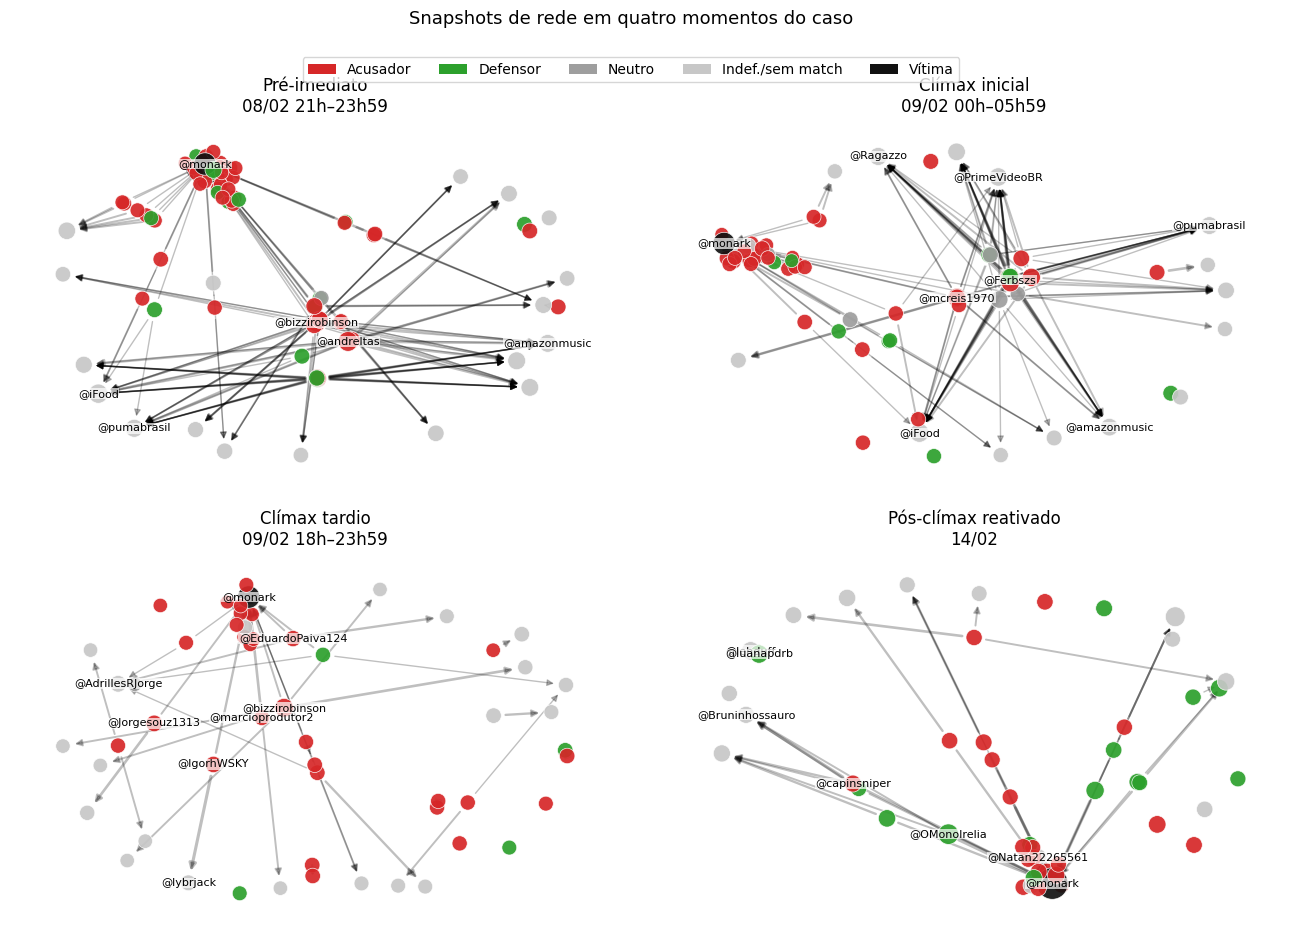

Validação compacta dos snapshots:


,segment_id,n_tweets_segmento,n_autores_segmento,n_nodes_drawn,pct_nodes_matched,n_acusador,n_defensor,n_neutro,n_indefinido,n_indefinido_match,n_indefinido_empate,n_indefinido_sem_rotulo,n_sem_match,n_vitima,n_victim_collapsed
0,climax_3h_2100_2359,326,308,87,79.31,51,15,2,18,1,1,0,17,1,1
1,climax_6h_0000_0559,174,161,72,77.78,37,11,6,17,2,2,0,15,1,1
2,climax_6h_1800_2359,230,215,55,65.45,29,4,1,20,2,2,0,18,1,0
3,post_2022_02_14,521,444,50,76.00,21,14,0,14,3,3,0,11,1,0


Leitura da validação:
- n_indefinido_match: nós com autor reconhecido, mas sem postura modal útil.
- n_indefinido_empate: subconjunto do item anterior em que houve empate entre posturas.
- n_indefinido_sem_rotulo: subconjunto do item anterior em que faltou rótulo utilizável.
- n_sem_match: nós do GEXF que não encontraram correspondência segura na base classificada.
- n_victim_collapsed: quantidade de nós equivalentes à vítima que foram fundidos antes do desenho.


In [25]:
# Snapshots de rede em quatro momentos-chave do caso

# Pré-condições / recuperação leve de estado
if "snapshot_manifest" not in globals():
    if "manifest_df" in globals() and "use_snapshots" in manifest_df.columns:
        snapshot_manifest = manifest_df.loc[manifest_df["use_snapshots"]].copy()
    else:
        raise RuntimeError(
            "A variável 'snapshot_manifest' não existe na sessão. "
            "Rode antes a célula 12 — Manifesto temporal."
        )

if "df" not in globals():
    raise RuntimeError(
        "A variável 'df' não existe na sessão. "
        "Rode antes a célula 21 — Pré-processamento principal do bruto consolidado."
    )

required_globals = [
    "VICTIM_LABEL",
    "draw_gexf_snapshot_by_stance",
    "build_segment_stance_map_from_df",
    "get_user_col",
    "STANCE_COLORS"
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Faltam itens necessários para esta célula: "
        + ", ".join(missing_globals)
        + ". Rode antes a célula 44 — Funções para snapshots."
    )

available_snapshots = (
    snapshot_manifest
    .copy()
    .dropna(subset=["gexf_url", "raw_url", "window_start", "window_end"])
    .sort_values("window_start")
    .reset_index(drop=True)
)

if available_snapshots.empty:
    print("Nenhum snapshot com gexf_url disponível foi encontrado no manifesto.")
else:
    # Quatro momentos-chave da narrativa visual
    # 1) sai o pre_0708, entra o pré-imediato
    focus_specs = pd.DataFrame([
        {
            "segment_id": "climax_3h_2100_2359",
            "display_title": "Pré-imediato\n08/02 21h–23h59",
            "top_n": 40,
            "label_n": 6,
            "include_neighbors": True
        },
        {
            "segment_id": "climax_6h_0000_0559",
            "display_title": "Clímax inicial\n09/02 00h–05h59",
            "top_n": 50,
            "label_n": 8,
            "include_neighbors": True
        },
        {
            "segment_id": "climax_6h_1800_2359",
            "display_title": "Clímax tardio\n09/02 18h–23h59",
            "top_n": 50,
            "label_n": 8,
            "include_neighbors": True
        },
        {
            "segment_id": "post_2022_02_14",
            "display_title": "Pós-clímax reativado\n14/02",
            "top_n": 50,
            "label_n": 7,
            "include_neighbors": False
        },
    ])

    snapshot_plan = (
        focus_specs
        .merge(
            available_snapshots[
                ["segment_id", "phase_block", "granularity", "window_start", "window_end", "gexf_url", "raw_url"]
            ],
            on="segment_id",
            how="left"
        )
    )

    missing_ids = snapshot_plan.loc[snapshot_plan["gexf_url"].isna(), "segment_id"].tolist()
    if missing_ids:
        print("Snapshots não encontrados no manifesto e ignorados:", missing_ids)

    snapshot_plan = snapshot_plan.dropna(subset=["gexf_url"]).reset_index(drop=True)

    if snapshot_plan.empty:
        print("Nenhum dos snapshots escolhidos foi encontrado no manifesto.")
    else:
        fig, axes = plt.subplots(2, 2, figsize=(13.5, 10))
        axes = axes.ravel()

        validation_rows = []
        user_col = get_user_col(df)

        for ax, (_, row) in zip(axes, snapshot_plan.iterrows()):
            # a célula 44 corrigida agora retorna stance_map + stance_reason_map + seg_df
            stance_map, stance_reason_map, seg_df = build_segment_stance_map_from_df(
                df_base=df,
                window_start=row["window_start"],
                window_end=row["window_end"]
            )

            summary = draw_gexf_snapshot_by_stance(
                gexf_source=row["gexf_url"],
                stance_map=stance_map,
                stance_reason_map=stance_reason_map,
                ax=ax,
                victim_label=VICTIM_LABEL,
                title=row["display_title"],
                top_n=int(row["top_n"]),
                label_n=int(row["label_n"]),
                include_victim_neighbors=bool(row["include_neighbors"])
            )

            ax.set_facecolor("#fafafa")

            validation_rows.append({
                "segment_id": row["segment_id"],
                "phase_block": row["phase_block"],
                "granularity": row["granularity"],
                "n_tweets_segmento": len(seg_df),
                "n_autores_segmento": seg_df[user_col].nunique(),
                **summary
            })

        # Desligar eixos vazios, se houver
        for ax in axes[len(snapshot_plan):]:
            ax.axis("off")

        legend_handles = [
            Patch(facecolor=STANCE_COLORS["acusador"], edgecolor="none", label="Acusador"),
            Patch(facecolor=STANCE_COLORS["defensor"], edgecolor="none", label="Defensor"),
            Patch(facecolor=STANCE_COLORS["neutro"], edgecolor="none", label="Neutro"),
            Patch(facecolor=STANCE_COLORS["indefinido"], edgecolor="none", label="Indef./sem match"),
            Patch(facecolor=STANCE_COLORS["vitima"], edgecolor="none", label="Vítima"),
        ]

        fig.suptitle("Snapshots de rede em quatro momentos do caso", y=0.97, fontsize=13)
        fig.legend(
            handles=legend_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.93),
            ncol=5,
            frameon=True
        )

        fig.subplots_adjust(
            top=0.86,
            bottom=0.06,
            left=0.04,
            right=0.98,
            wspace=0.08,
            hspace=0.18
        )
        plt.show()

        # Validação compacta
        validation_df = pd.DataFrame(validation_rows)

        validation_view_cols = [
            "segment_id",
            "n_tweets_segmento",
            "n_autores_segmento",
            "n_nodes_drawn",
            "pct_nodes_matched",
            "n_acusador",
            "n_defensor",
            "n_neutro",
            "n_indefinido",
            "n_indefinido_match",
            "n_indefinido_empate",
            "n_indefinido_sem_rotulo",
            "n_sem_match",
            "n_vitima",
            "n_victim_collapsed",
        ]

        validation_view_cols = [c for c in validation_view_cols if c in validation_df.columns]

        print("Validação compacta dos snapshots:")
        display(validation_df[validation_view_cols].round(2))

        print("Leitura da validação:")
        print("- n_indefinido_match: nós com autor reconhecido, mas sem postura modal útil.")
        print("- n_indefinido_empate: subconjunto do item anterior em que houve empate entre posturas.")
        print("- n_indefinido_sem_rotulo: subconjunto do item anterior em que faltou rótulo utilizável.")
        print("- n_sem_match: nós do GEXF que não encontraram correspondência segura na base classificada.")
        print("- n_victim_collapsed: quantidade de nós equivalentes à vítima que foram fundidos antes do desenho.")

In [26]:
# Diagnóstico dos nós principais dos snapshots
# Objetivo: entender "quem é quem" no grafo em termos analíticos,
# sem depender de leitura visual manual.

# -----------------------------
# Pré-condições
# -----------------------------
required_globals = [
    "snapshot_manifest",
    "df",
    "build_segment_stance_map_from_df",
    "load_gexf_graph",
    "get_user_col",
    "ensure_sp_time",
]
missing_globals = [x for x in required_globals if x not in globals()]
if missing_globals:
    raise RuntimeError(
        "Faltam itens para esta célula: " + ", ".join(missing_globals)
        + ". Rode antes as células 21, 44 e 45."
    )

if "_norm_handle" not in globals():
    def _norm_handle(value):
        if value is None or pd.isna(value):
            return ""
        return str(value).strip().lower().lstrip("@")

if "collapse_victim_duplicates" not in globals():
    def collapse_victim_duplicates(G, victim_label):
        return G.copy(), [], 0

if "VICTIM_LABEL" not in globals():
    VICTIM_LABEL = "@monark"

# -----------------------------
# Handles de interesse
# Incluí variantes para tolerar erros de grafia
# -----------------------------
HANDLES_DE_INTERESSE = [
    "Ferbszs", "bizzirobinson",
    "Bruninhossauro", "mcreis1970",
    "andreita", "andreitas",
    "monoreila", "OMonoirelia",
    "capinsnaiper", "capinspiner"
]

# Se quiser, pode editar manualmente a lista acima.

# -----------------------------
# Snapshots que estão no corpo principal
# -----------------------------
SEGMENTOS_FOCO = [
    "climax_3h_2100_2359",
    "climax_6h_0000_0559",
    "climax_6h_1800_2359",
    "post_2022_02_14",
]

snapshots_focus = (
    snapshot_manifest
    .copy()
    .query("segment_id in @SEGMENTOS_FOCO")
    .sort_values("window_start")
    .reset_index(drop=True)
)

if snapshots_focus.empty:
    raise ValueError("Nenhum dos segmentos foco foi encontrado em snapshot_manifest.")

# -----------------------------
# Helpers
# -----------------------------
def choose_node_key(node_id, node_attrs):
    """
    Escolhe a melhor chave analítica para um nó do GEXF.
    Preferência:
    handle > screen_name > user > label > node_id
    """
    candidates = [
        node_attrs.get("handle"),
        node_attrs.get("screen_name"),
        node_attrs.get("user"),
        node_attrs.get("label"),
        node_id,
    ]

    for c in candidates:
        k = _norm_handle(c)
        if k:
            return k

    return _norm_handle(node_id)

def choose_label(node_id, node_attrs):
    for c in [
        node_attrs.get("label"),
        node_attrs.get("screen_name"),
        node_attrs.get("user"),
        node_attrs.get("handle"),
        node_id,
    ]:
        if c is not None and str(c).strip():
            return str(c).strip()
    return str(node_id)

def summarize_handle_texts(seg_df, handle_key, user_col, max_texts=2):
    sub = seg_df.loc[seg_df[user_col].map(_norm_handle) == handle_key].copy()
    if sub.empty:
        return []

    score_col = "engagement" if "engagement" in sub.columns else None
    if score_col is not None:
        sub = sub.sort_values(score_col, ascending=False)

    text_col = "cleaned_text" if "cleaned_text" in sub.columns else ("text" if "text" in sub.columns else None)
    if text_col is None:
        return []

    texts = []
    for txt in sub[text_col].dropna().astype(str).tolist():
        txt = " ".join(txt.split())
        if txt and txt not in texts:
            texts.append(txt[:220])
        if len(texts) >= max_texts:
            break
    return texts

def stance_counts_str(seg_df, handle_key, user_col):
    if "stance" not in seg_df.columns:
        return ""
    sub = seg_df.loc[seg_df[user_col].map(_norm_handle) == handle_key].copy()
    if sub.empty:
        return ""
    counts = (
        sub["stance"]
        .astype("string")
        .str.strip()
        .str.lower()
        .fillna("ausente")
        .value_counts()
        .to_dict()
    )
    return ", ".join([f"{k}:{v}" for k, v in counts.items()])

# -----------------------------
# Montar diagnósticos
# -----------------------------
top_rows = []
interest_rows = []
sample_rows = []

df_local = ensure_sp_time(df)
user_col = get_user_col(df_local)

for _, snap in snapshots_focus.iterrows():
    segment_id = snap["segment_id"]

    # stance modal do segmento
    out = build_segment_stance_map_from_df(
        df_base=df_local,
        window_start=snap["window_start"],
        window_end=snap["window_end"]
    )

    if len(out) == 3:
        stance_map, stance_reason_map, seg_df = out
    else:
        # compatibilidade com versão antiga da função
        stance_map, seg_df = out
        stance_reason_map = {}

    # carregar grafo e colapsar vítima se a função existir
    G_raw = load_gexf_graph(snap["gexf_url"])
    G, victim_nodes, n_collapsed = collapse_victim_duplicates(G_raw, VICTIM_LABEL)

    # tabela de nós
    node_rows = []
    for n, d in G.nodes(data=True):
        key = choose_node_key(n, d)
        label = choose_label(n, d)

        if G.is_directed():
            indeg = G.in_degree(n, weight="weight")
            outdeg = G.out_degree(n, weight="weight")
        else:
            indeg = np.nan
            outdeg = np.nan

        degree_w = G.degree(n, weight="weight")
        degree_u = G.degree(n)

        if n in victim_nodes:
            stance = "vitima"
            stance_reason = "vitima"
        else:
            stance = stance_map.get(key, "sem_match")
            stance_reason = stance_reason_map.get(key, "sem_match" if key not in stance_map else "modal")

        # stats do df no segmento
        sub = seg_df.loc[seg_df[user_col].map(_norm_handle) == key].copy()
        n_tweets = len(sub)
        likes_medios = sub["favorite_count"].mean() if "favorite_count" in sub.columns and n_tweets > 0 else np.nan
        rts_medios = sub["retweet_count"].mean() if "retweet_count" in sub.columns and n_tweets > 0 else np.nan

        node_rows.append({
            "segment_id": segment_id,
            "node_id": str(n),
            "label": label,
            "handle_key": key,
            "stance_grafo": stance,
            "stance_reason": stance_reason,
            "degree_weighted": float(degree_w) if pd.notna(degree_w) else np.nan,
            "degree_unweighted": float(degree_u) if pd.notna(degree_u) else np.nan,
            "indegree_weighted": float(indeg) if pd.notna(indeg) else np.nan,
            "outdegree_weighted": float(outdeg) if pd.notna(outdeg) else np.nan,
            "n_tweets_segmento": n_tweets,
            "likes_medios_segmento": likes_medios,
            "retweets_medios_segmento": rts_medios,
            "stance_counts_df": stance_counts_str(seg_df, key, user_col),
        })

        # amostras de texto para handles de interesse ou nós muito centrais
        texts = summarize_handle_texts(seg_df, key, user_col, max_texts=2)
        for t in texts:
            sample_rows.append({
                "segment_id": segment_id,
                "handle_key": key,
                "label": label,
                "texto_exemplo": t
            })

    nodes_df = pd.DataFrame(node_rows)

    # top nós do snapshot
    top_seg = (
        nodes_df
        .sort_values(["degree_weighted", "degree_unweighted"], ascending=False)
        .head(12)
        .copy()
    )

    top_seg["papel_analitico"] = np.where(
        top_seg["handle_key"] == _norm_handle(VICTIM_LABEL),
        "vítima",
        np.where(
            top_seg["degree_weighted"] >= top_seg["degree_weighted"].quantile(0.8),
            "hub",
            "intermediário"
        )
    )

    top_rows.append(top_seg)

    # handles de interesse com match aproximado
    graph_keys = sorted(nodes_df["handle_key"].dropna().unique().tolist())
    df_keys = sorted(seg_df[user_col].map(_norm_handle).dropna().unique().tolist())
    universe_keys = sorted(set(graph_keys) | set(df_keys))

    for raw_handle in HANDLES_DE_INTERESSE:
        query = _norm_handle(raw_handle)

        matched = None
        if query in universe_keys:
            matched = query
        else:
            close = get_close_matches(query, universe_keys, n=1, cutoff=0.75)
            matched = close[0] if close else None

        if matched is None:
            interest_rows.append({
                "segment_id": segment_id,
                "consulta": raw_handle,
                "match_encontrado": None,
                "presente_no_grafo": False,
                "label": None,
                "stance_grafo": None,
                "stance_reason": None,
                "degree_weighted": np.nan,
                "indegree_weighted": np.nan,
                "outdegree_weighted": np.nan,
                "n_tweets_segmento": 0,
                "stance_counts_df": ""
            })
        else:
            row = nodes_df.loc[nodes_df["handle_key"] == matched].copy()
            if row.empty:
                # está no df do segmento, mas não no subgrafo desenhado
                sub = seg_df.loc[seg_df[user_col].map(_norm_handle) == matched].copy()
                interest_rows.append({
                    "segment_id": segment_id,
                    "consulta": raw_handle,
                    "match_encontrado": matched,
                    "presente_no_grafo": False,
                    "label": matched,
                    "stance_grafo": stance_map.get(matched, "sem_match"),
                    "stance_reason": stance_reason_map.get(matched, "sem_match"),
                    "degree_weighted": np.nan,
                    "indegree_weighted": np.nan,
                    "outdegree_weighted": np.nan,
                    "n_tweets_segmento": len(sub),
                    "stance_counts_df": stance_counts_str(seg_df, matched, user_col)
                })
            else:
                row = row.iloc[0]
                interest_rows.append({
                    "segment_id": segment_id,
                    "consulta": raw_handle,
                    "match_encontrado": matched,
                    "presente_no_grafo": True,
                    "label": row["label"],
                    "stance_grafo": row["stance_grafo"],
                    "stance_reason": row["stance_reason"],
                    "degree_weighted": row["degree_weighted"],
                    "indegree_weighted": row["indegree_weighted"],
                    "outdegree_weighted": row["outdegree_weighted"],
                    "n_tweets_segmento": row["n_tweets_segmento"],
                    "stance_counts_df": row["stance_counts_df"]
                })

top_nodes_df = pd.concat(top_rows, ignore_index=True)
interest_df = pd.DataFrame(interest_rows)
sample_df = pd.DataFrame(sample_rows).drop_duplicates()

# -----------------------------
# Exibir resultados
# -----------------------------
print("1) Top nós por snapshot (ordenados por grau ponderado):")
display(
    top_nodes_df[
        [
            "segment_id", "label", "handle_key",
            "stance_grafo", "stance_reason",
            "degree_weighted", "indegree_weighted", "outdegree_weighted",
            "n_tweets_segmento", "stance_counts_df", "papel_analitico"
        ]
    ].round(2)
)

print("2) Handles consultados especificamente:")
display(
    interest_df[
        [
            "segment_id", "consulta", "match_encontrado", "presente_no_grafo",
            "label", "stance_grafo", "stance_reason",
            "degree_weighted", "indegree_weighted", "outdegree_weighted",
            "n_tweets_segmento", "stance_counts_df"
        ]
    ].round(2)
)

print("3) Exemplos de texto dos nós encontrados:")
if sample_df.empty:
    print("Nenhum texto exemplo disponível.")
else:
    display(sample_df.sort_values(["segment_id", "handle_key"]).reset_index(drop=True))

print("4) Leitura rápida:")
print("- stance_grafo: postura modal atribuída ao autor naquele segmento.")
print("- stance_reason = modal: houve maioria clara de postura no segmento.")
print("- stance_reason = empate: o autor apareceu com posturas empatadas.")
print("- stance_reason = sem_rotulo: faltou rótulo utilizável para decidir.")
print("- stance_grafo = sem_match: o nó existe no GEXF, mas não casou com um autor da base classificada.")
print("- degree_weighted: centralidade local no grafo do snapshot.")

1) Top nós por snapshot (ordenados por grau ponderado):


,segment_id,label,handle_key,stance_grafo,stance_reason,degree_weighted,indegree_weighted,outdegree_weighted,n_tweets_segmento,stance_counts_df,papel_analitico
0,climax_3h_2100_2359,@monark,monark,vitima,vitima,75.0,75.0,0.0,0,,vítima
1,climax_3h_2100_2359,@andreltas,andreltas,acusador,modal,37.0,0.0,37.0,3,"acusador:2, defensor:1",hub
2,climax_3h_2100_2359,@iFood,ifood,sem_match,sem_match,31.0,31.0,0.0,0,,hub
3,climax_3h_2100_2359,@bizzirobinson,bizzirobinson,acusador,modal,23.0,0.0,23.0,2,acusador:2,intermediário
4,climax_3h_2100_2359,@pumabrasil,pumabrasil,sem_match,sem_match,19.0,19.0,0.0,0,,intermediário
5,climax_3h_2100_2359,@Ragazzo,ragazzo,sem_match,sem_match,18.0,18.0,0.0,0,,intermediário
6,climax_3h_2100_2359,@PrimeVideoBR,primevideobr,sem_match,sem_match,17.0,17.0,0.0,0,,intermediário
7,climax_3h_2100_2359,@amazonmusic,amazonmusic,sem_match,sem_match,17.0,17.0,0.0,0,,intermediário
8,climax_3h_2100_2359,@arthurmoledoval,arthurmoledoval,sem_match,sem_match,15.0,15.0,0.0,0,,intermediário
9,climax_3h_2100_2359,@AKIGOTCH,akigotch,acusador,modal,13.0,0.0,13.0,1,acusador:1,intermediário


2) Handles consultados especificamente:


,segment_id,consulta,match_encontrado,presente_no_grafo,label,stance_grafo,stance_reason,degree_weighted,indegree_weighted,outdegree_weighted,n_tweets_segmento,stance_counts_df
0,climax_3h_2100_2359,Ferbszs,None,False,None,None,None,NaN,NaN,NaN,0,
1,climax_3h_2100_2359,bizzirobinson,bizzirobinson,True,@bizzirobinson,acusador,modal,23.0,0.0,23.0,2,acusador:2
2,climax_3h_2100_2359,Bruninhossauro,None,False,None,None,None,NaN,NaN,NaN,0,
3,climax_3h_2100_2359,mcreis1970,None,False,None,None,None,NaN,NaN,NaN,0,
4,climax_3h_2100_2359,andreita,andreltas,True,@andreltas,acusador,modal,37.0,0.0,37.0,3,"acusador:2, defensor:1"
5,climax_3h_2100_2359,andreitas,andreltas,True,@andreltas,acusador,modal,37.0,0.0,37.0,3,"acusador:2, defensor:1"
6,climax_3h_2100_2359,monoreila,None,False,None,None,None,NaN,NaN,NaN,0,
7,climax_3h_2100_2359,OMonoirelia,None,False,None,None,None,NaN,NaN,NaN,0,
8,climax_3h_2100_2359,capinsnaiper,None,False,None,None,None,NaN,NaN,NaN,0,
9,climax_3h_2100_2359,capinspiner,None,False,None,None,None,NaN,NaN,NaN,0,


3) Exemplos de texto dos nós encontrados:


,segment_id,handle_key,label,texto_exemplo
0,climax_3h_2100_2359,__cancelado__,@__cancelado__,wau falou tudo pessoal tem que maneirar com es...
1,climax_3h_2100_2359,_galeani,@_galeani,O Monark foi infeliz no comentario... o sentid...
2,climax_3h_2100_2359,_grimjonny_,@_Grimjonny_,É tudo por questão ideológica.. o Monark apoia...
3,climax_3h_2100_2359,_niiting,@_NiiTing,"Tutorial: como ser cancelado em 1:30 , já pode..."
4,climax_3h_2100_2359,_ruoyeh,@_ruoyeh,O MONARK NAAAOOOO mas o plot do Arthur voltand...
...,...,...,...,...
718,post_2022_02_14,youserio,@youserio,"Ele foi infeliz e tomou punição lek, foi expul..."
719,post_2022_02_14,yukisv_,@YukiSV_,"KKKKK tu ta de meme ne fdp, o mornark além de ..."
720,post_2022_02_14,ze_toba_,@ze_toba_,"Ele foi cancelado pra krl lá nos EUA, e com ra..."
721,post_2022_02_14,zildete8,@Zildete8,"Coitada desejar essa gente para ela . Não , nã..."


4) Leitura rápida:
- stance_grafo: postura modal atribuída ao autor naquele segmento.
- stance_reason = modal: houve maioria clara de postura no segmento.
- stance_reason = empate: o autor apareceu com posturas empatadas.
- stance_reason = sem_rotulo: faltou rótulo utilizável para decidir.
- stance_grafo = sem_match: o nó existe no GEXF, mas não casou com um autor da base classificada.
- degree_weighted: centralidade local no grafo do snapshot.


# Leitura dos snapshots de rede

Os snapshots mostram que o caso se organiza em torno de três camadas de atores: o alvo central (@monark), as marcas e instituições arrastadas para a crise reputacional e as contas usuais que sustentam a acusação ou a defesa dentro do X/Twitter. No plano público, a controvérsia nasce da fala de Monark no Flow durante a entrevista com Tabata Amaral e Kim Kataguiri, leva ao seu desligamento do programa e rapidamente aciona tanto repúdio institucional quanto pressão sobre marcas associadas ao podcast.

No pré-imediato (08/02 21h–23h59), o grafo já aparece fortemente centrado em @monark, mas o traço mais importante é a presença de contas corporativas como @iFood, @pumabrasil, @Ragazzo, @PrimeVideoBR, @amazonmusic e @wiseupbr. Esses nós não devem ser lidos como autores orgânicos da controvérsia, e sim como destinatários da pressão reputacional: eram perfis acionados por usuários que buscavam produzir sanção econômica e moral sobre o Flow. Essa leitura é coerente com a cobertura do caso, segundo a qual patrocinadores e marcas ligadas ao podcast ficaram entre os perfis mais mencionados no Twitter após a fala de Monark. Nesse mesmo recorte, contas como @andreltas e @bizzirobinson já aparecem como polos acusatórios internos da conversa, indicando que a mobilização dos usuários e a cobrança sobre patrocinadores caminham juntas desde cedo.

Note-se que os polos acusadores fazem a função de **líderes do cancelamento**. Os líderes em teoria mimética são **vetores de imitação** para os demais agentes, aparecendo logo no início da crise mimética, detonando o mecanismo vitimário, que depois se difunde pela comunidade.

No clímax inicial (09/02 00h–05h59), a estrutura fica ainda mais concentrada em torno do alvo e preserva o cinturão de marcas pressionadas. @monark continua como centro inequívoco, enquanto @iFood, @PrimeVideoBR, @Ragazzo, @pumabrasil, @amazonmusic e @wiseupbr seguem com alta centralidade de entrada, o que sugere continuidade da dinâmica de cobrança pública. Ao mesmo tempo, a acusação se adensa em contas como @mcreis1970, @sara__alinee e @jacksinsaneside, que funcionam como polos distribuídos de difusão acusatória. O caso de @Ferbszs ajuda a ler corretamente a legenda metodológica: ele aparece como indefinido não por ser um ator opaco, mas porque, naquele segmento, sua postura modal ficou em empate entre rótulos.

No clímax tardio (09/02 18h–23h59), a leitura muda de sentido. O fato de os patrocinadores quase desaparecerem do primeiro plano do grafo não indica perda de importância, mas sim que a pressão já havia produzido efeito: nesse ponto, boa parte das marcas relevantes já tinha se manifestado para romper, suspender ou se desvincular publicamente do Flow, e a rede passa a refletir um momento de **alívio posterior à catarse punitiva**. Em vez do acionamento intenso de patrocinadores, o que aparece é uma acusação mais distribuída entre contas usuais, como @bizzirobinson, @Jorgesouz1313, @EduardoPaiva124, @igorhwsky e @marcioprodutor2. Ao mesmo tempo, a lógica acusatória parece respingar sobre **vítimas substitutas**, como sugere a entrada de @AdrillesRJorge no grafo: a vítima substituta passa a receber parte do ataque por ter marcas vitimárias parecidas com as da vítima original, no caso um suposto alinhamento ideológico.

No pós-clímax reativado (14/02), o desenho sugere um repique depois do alívio produzido pela catarse inicial. @monark continua central, mas agora seu entorno já abriga uma proporção significativa — embora ainda minoritária — de defensores, com destaque para @OMonoIrelia, @luanapdrb, @viniciusfuria16, @ElJee77368141 e @shuhikari. Esses perfis não aparecem, com segurança, como protagonistas públicos do caso na cobertura jornalística; no notebook, portanto, devem ser lidos como hubs orgânicos de defesa dentro da rede do X/Twitter. O importante aqui é que, diferentemente do clímax, a vítima já não está cercada quase exclusivamente por acusadores: **a rede passa a ensaiar uma tentativa de reabilitação**, ainda insuficiente para inverter a predominância acusatória, mas forte o bastante para alterar a morfologia do entorno do alvo.

*Em conjunto, os quatro snapshots sugerem uma sequência bastante clara: primeiro, a crise se estrutura como convergência sobre o alvo combinada com pressão intensa sobre patrocinadores; depois, entra num estágio de catarse punitiva; em seguida, vem um momento de alívio, no qual a sanção principal já foi consumada e a acusação se distribui mais horizontalmente, inclusive sobre alvos laterais; por fim, o caso conhece um repique pós-catarse, no qual a vítima segue central, mas já conta com um bloco defensivo visível, ainda minoritário, que parece ensaiar sua reabilitação simbólica*. Em outras palavras, os grafos mostram que o cancelamento não é apenas condenação moral abstrata: ele envolve pressão econômica, clímax catártico, dispersão punitiva e tentativa posterior — ainda incompleta — de recomposição do alvo.

*Deve se esperar a comparação com outros casos de cancelamento digital, a fim de conferir se a mesma estrutura se repete*.

## Respondendo às hipóteses

À luz do conjunto dos gráficos e snapshots, a hipótese principal de que o caso Monark apresenta uma dinâmica de **convergência vitimária** recebe **suporte parcial e não monotônico**. O episódio mostra, com clareza, a formação de um foco coletivo sobre o alvo, a intensificação abrupta das interações no clímax e a posterior reorganização da rede em torno da vítima. Ao mesmo tempo, os indicadores sugerem que essa convergência não se desenvolve como um movimento linear e único: ela combina **explosão inicial**, **catarse punitiva**, **alívio posterior** e **reativação defensiva** no pós-clímax.

### H1a — Concentração de atenção sobre a vítima

A hipótese de concentração de atenção é a que encontra suporte mais robusto, mas seu sentido analítico vai além de um simples “aumento de volume”. O salto abrupto da intensidade relacional no clímax sugere a entrada da rede em um regime de **imitação acusatória**, no qual a atenção deixa de circular entre vários focos e passa a ser canalizada para um mesmo polo sacrificial. Em termos compatíveis com a formulação do notebook, o caso parece seguir uma dinâmica **trifásica e defasada**: primeiro, a saliência se condensa em alguns polos que operam como **líderes locais da acusação**; em seguida, essa orientação se generaliza e converge sobre @monark, que se torna o centro inequívoco da controvérsia; por fim, no pós-clímax, parte dessa atenção retorna aos polos de liderança, sem que a vítima deixe de funcionar como referência comum do conflito. O fato de a centralização e a participação do nó principal reaparecerem com força depois do auge inicial sugere que o rito não esgota imediatamente a crise: a rede continua a reconvocar a vítima como ponto de unificação, ao mesmo tempo em que ensaia sua **separação simbólica do coletivo**. Assim, H1a não indica apenas concentração de atenção, mas um processo de focalização imitativa, coordenação acusatória e tentativa de isolamento da vítima.

### H1b — Perda de diferenciação estrutural da rede

A hipótese de perda de diferenciação estrutural encontra suporte consistente, embora processual e temporalmente defasado. Na teoria mimética, a crise de indiferenciação não exige que todas as diferenças desapareçam por completo, nem que a rede permaneça homogênea de modo contínuo; basta que as fronteiras habituais entre grupos enfraqueçam o suficiente para permitir uma **convergência funcional contra a vítima**. É isso que o caso Monark parece mostrar. No clímax inicial, a controvérsia deixa de permanecer confinada em bolhas relativamente autônomas e passa a atravessar regiões distintas da rede: a acusação dirigida a @monark e a pressão sobre atores do seu entorno — especialmente patrocinadores e instâncias institucionais — sincronizam segmentos antes mais separados em torno de uma mesma exigência de sanção. O “todos contra um”, aqui, não significa unanimidade absoluta nem apagamento total das diferenças, mas uma compressão provisória das fronteiras comunitárias em favor de um alvo comum.

O fato de os indicadores não atingirem seu máximo no mesmo segmento não enfraquece essa leitura; ao contrário, sugere que a indiferenciação se distribui ao longo da crise em momentos sucessivos de compressão e recomposição. A queda de modularidade no auge inicial e a persistência de travessias intercomunitárias em janelas posteriores indicam que a perda de diferenciação foi real, embora não linear nem permanente. Depois que a sanção se efetiva e a vítima é expulsa de suas posições institucionais, **a rede volta gradualmente a se diferenciar**: reaparecem fronteiras, redistribuem-se os polos de conflito e surgem focos defensivos minoritários. Em termos miméticos, isso não representa uma negação da hipótese, mas justamente o efeito esperado de um mecanismo sacrificial bem-sucedido: ao isolar e punir a vítima, o coletivo recupera diferenças internas e recompõe provisoriamente sua ordem.

### H1c — Deterioração da posição relacional da vítima

A hipótese sobre a deterioração da posição relacional da vítima recebe suporte mais convincente quando interpretada à luz da teoria mimética, e não segundo uma noção empobrecida de isolamento como simples desaparecimento da vítima da rede. No caso Monark, a expulsão não ficou apenas no nível simbólico: ela se concretizou no plano social e institucional, com a perda de vínculos ordinários, apoio e posição pública no auge da crise. Por isso, o núcleo da hipótese não deve ser procurado em uma suposta “evaporação” de @monark do debate, mas na transformação de sua posição **em um lugar assimétrico, sacrificial e negativamente marcado**. As métricas de entorno captam esse movimento apenas de maneira parcial: não há um declínio linear e imediato no centro do clímax, e os sinais mais fortes de rarefação aparecem sobretudo no pós-clímax. Longe de invalidar a hipótese, esse descompasso sugere que a sanção se consuma antes, enquanto seu rastro relacional se torna mais visível depois. A permanência de @monark como nó central no pós-clímax, portanto, não é sinal de fracasso do isolamento, mas de sua eficácia: a vítima já foi separada e punida, mas continua a circular como memória do sacrifício, referência negativa do episódio e espécie de tabu que ajuda a fixar o sentido da crise para a coletividade. O surgimento de uma minoria defensora não desfaz essa lógica; apenas mostra que a **memória sacrificial** permanece disputada e que a narrativa não é monopolizada integralmente pelos canceladores. Assim, H1c não aponta para um abandono puro e simples da vítima, mas para um processo de expulsão funcional combinado com permanência simbólica: a vítima perde seu lugar ordinário no coletivo, mas persiste como marca memorial do rito que restaurou provisoriamente a ordem.

### Síntese final das hipóteses

Em conjunto, os resultados demonstram que o caso Monark adere com precisão à dinâmica de convergência vitimária, manifestando-se como um processo cíclico de crise, indiferenciação e reordenação. O episódio valida a transição do "todos contra um" — marcada pela rápida convergência acusatória e pelo colapso das fronteiras entre comunidades no clímax — para uma **nova configuração estrutural após o sacrifício simbólico** (a perda de patrocínios e saída do programa). A reorganização observada no pós-clímax, com o surgimento de núcleos defensivos e a rediferenciação da rede, não enfraquece a análise; pelo contrário, confirma a função restauradora do mecanismo do bode expiatório descrita pela teoria mimética. Portanto, as evidências fornecem suporte robusto e integrado para H1a, H1b e H1c, revelando que a instabilidade estrutural é o sintoma da crise aguda que precede a fundação de uma nova ordem social na rede.

# Conclusão

Este notebook investigou se o caso Monark apresenta uma dinâmica compatível com a convergência vitimária em contexto de cancelamento digital. Consideradas em conjunto, as métricas temporais, os indicadores relacionais e os snapshots da rede apontam fortemente nessa direção. O episódio não se reduz a um pico difuso de reprovação: ele assume a forma de uma crise em que a atenção coletiva se concentra progressivamente sobre um alvo singular, a acusação se torna imitativa, a pressão se desloca também para atores institucionais do entorno e a sanção acaba por se consumar no plano material, com perda de apoio e afastamento da vítima de sua posição anterior.

A dimensão da **concentração de atenção** (H1a) é a mais nítida: @monark se consolida como polo sacrificial da controvérsia, e a rede entra num regime de **imitação acusatória** em que diferentes atores passam a orientar suas interações para o mesmo centro. Esse movimento não nasce do nada: ele é preparado por polos acusatórios que funcionam como vetores de focalização e ajudam a estabilizar a escolha da vítima antes da convergência mais ampla.

Quanto à **perda de diferenciação estrutural** (H1b), o caso sugere uma crise aguda seguida de reordenação. Em vez de uma polarização  em **bolhas ideológicas**, no momento mais intenso, há compressão provisória das fronteiras entre comunidades e configuração do “**todos contra um**”; depois, uma vez efetivada a punição, a rede volta a se diferenciar e passa a redistribuir a controvérsia entre polos de ataque, memória e defesa residual. Essa recomposição posterior não contradiz a teoria mimética: ela corresponde justamente ao **efeito restaurador do mecanismo sacrificial** depois que a expulsão cumpre sua função ordenadora.

A deterioração da **posição relacional da vítima** (H1c) também deve ser entendida nesse registro. O isolamento da vítima não significa necessariamente seu desaparecimento da coletividade. Ao contrário: no caso Monark, o isolamento funcionou precisamente porque houve expulsão efetiva de sua posição institucional e de seus vínculos ordinários no auge da crise. O fato de ele continuar aparecendo na rede depois disso não anula o mecanismo; indica que a vítima, uma vez sacrificada, permanece como marca negativa do episódio, objeto de memória, tabu e disputa narrativa. Em outros termos, o pós-clímax mostra o resíduo simbólico: a vítima já foi separada e punida, mas continua presente como referência estruturante da ordem restaurada. A **minoria defensora**, no presente caso, não desfaz o rito; apenas impede que a história seja narrada exclusivamente do **ponto de vista dos canceladores**.

Em síntese, o caso Monark oferece evidência forte de uma dinâmica de convergência vitimária: há liderança acusatória, focalização imitativa, crise de indiferenciação, isolamento funcional da vítima e consumação da sanção. A prudência metodológica é necessária sobre a granularidade com que cada indicador consegue registrar esse processo. Assim, a leitura mais adequada é a de um **sacrifício consumado cujo efeito persiste como memória social e referência simbólica no pós-clímax**.

A presente pesquisa prosseguirá com outras hipóteses sobre o caso Monark, assim como para outros casos de cancelamento digital, a fim de estabelecer comparações e identificar padrões.

## Apêndice — checagens operacionais

,day_sp,n_tweets,n_ids_unicos,n_usuarios_unicos
0,2022-02-07 00:00:00-03:00,13,13,13
1,2022-02-08 00:00:00-03:00,1429,1429,1315
2,2022-02-09 00:00:00-03:00,1115,1115,1055
3,2022-02-10 00:00:00-03:00,559,559,483
4,2022-02-11 00:00:00-03:00,671,671,587
5,2022-02-12 00:00:00-03:00,330,330,289
6,2022-02-13 00:00:00-03:00,165,165,153
7,2022-02-14 00:00:00-03:00,521,521,444


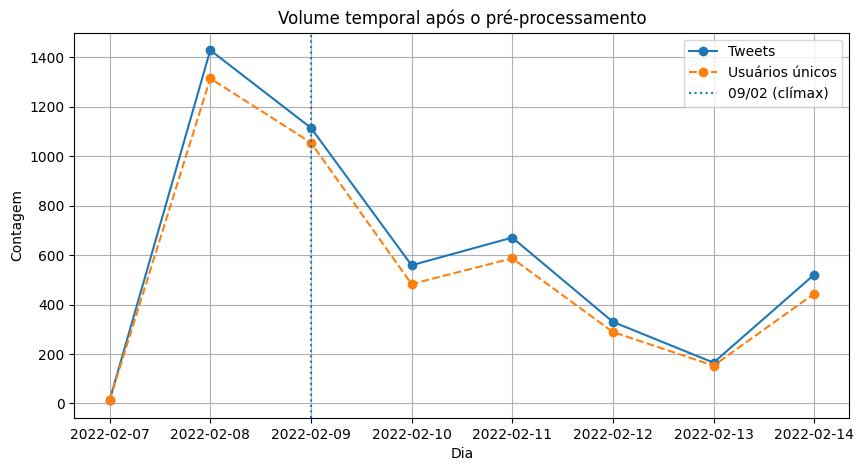

Pico diário de tweets: 2022-02-08 - 1429


In [ ]:
# Volume temporal após o pré-processamento (base tratada)

id_col = "tweet_id" if "tweet_id" in df.columns else "id"
user_col = "user" if "user" in df.columns else ("screen_name" if "screen_name" in df.columns else None)

volume_df = df.copy()

# garantir coluna temporal em fuso de São Paulo
if "created_at_sp" not in volume_df.columns:
    date_col = "created_at_iso" if "created_at_iso" in volume_df.columns else "created_at"
    volume_df[date_col] = pd.to_datetime(volume_df[date_col], utc=True, errors="coerce")
    volume_df["created_at_sp"] = volume_df[date_col].dt.tz_convert("America/Sao_Paulo")

volume_df = volume_df.dropna(subset=["created_at_sp"]).copy()
volume_df["day_sp"] = volume_df["created_at_sp"].dt.floor("D")

agg_dict = {
    "n_tweets": (id_col, "size"),
    "n_ids_unicos": (id_col, "nunique"),
}

if user_col is not None:
    agg_dict["n_usuarios_unicos"] = (user_col, "nunique")

daily_volume = (
    volume_df.groupby("day_sp")
    .agg(**agg_dict)
    .reset_index()
    .sort_values("day_sp")
)

# coluna sem timezone só para plotar mais limpo
daily_volume["day_plot"] = daily_volume["day_sp"].dt.tz_localize(None)

display(daily_volume.drop(columns="day_plot"))

peak_idx = daily_volume["n_tweets"].idxmax()
peak_day = daily_volume.loc[peak_idx, "day_plot"]
peak_val = daily_volume.loc[peak_idx, "n_tweets"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    daily_volume["day_plot"],
    daily_volume["n_tweets"],
    marker="o",
    label="Tweets"
)

if "n_usuarios_unicos" in daily_volume.columns:
    ax.plot(
        daily_volume["day_plot"],
        daily_volume["n_usuarios_unicos"],
        marker="o",
        linestyle="--",
        label="Usuários únicos"
    )

ax.axvline(pd.Timestamp("2022-02-09"), linestyle=":", label="09/02 (clímax)")
ax.set_title("Volume temporal após o pré-processamento")
ax.set_xlabel("Dia")
ax.set_ylabel("Contagem")
ax.legend()
plt.show()

print("Pico diário de tweets:", peak_day.date(), "-", peak_val)

## Leitura do volume temporal após o pré-processamento

Após a deduplicação, o caso mantém uma curva temporal bem definida, com forte escalada até o início do episódio, pico diário de tweets em **08/02**, queda no pós-clímax e repiques em **11/02** e **14/02**. A igualdade entre `n_tweets` e `n_ids_unicos` mostra que, após o pré-processamento, as contagens já não estão infladas por duplicatas de identificador. É importante, porém, distinguir duas noções de pico: neste gráfico, o maior **volume diário agregado** ocorre em 08/02, enquanto o **bloco analítico do clímax** da investigação foi organizado em torno das janelas de 09/02. Assim, esta visualização serve para descrever a intensidade temporal do caso após a limpeza, enquanto a definição de clímax usada nas métricas de rede será examinada mais adiante na série temporal analítica.

In [ ]:
# Materializar localmente os JSONLs da série principal e do zoom do clímax
main_jsonl_paths = materialize_manifest_files(main_manifest, MAIN_INPUT_DIR)
zoom_jsonl_paths = materialize_manifest_files(zoom_manifest, ZOOM_INPUT_DIR)

print("Arquivos da série principal:")
for p in main_jsonl_paths:
    print("-", p.name)

print("\nArquivos do zoom do clímax:")
for p in zoom_jsonl_paths:
    print("-", p.name)

print("\nTotal série principal:", len(main_jsonl_paths))
print("Total zoom:", len(zoom_jsonl_paths))

Arquivos da série principal:
- monark_pre_2022-02-07_00-00_2022-02-08_20-59.jsonl
- monark_6h_2022-02-09_00-00_05-59.jsonl
- monark_6h_2022-02-09_06-00_11-59.jsonl
- monark_6h_2022-02-09_12-00_17-59.jsonl
- monark_6h_2022-02-09_18-00_23-59.jsonl
- monark_dia_2022-02-10.jsonl
- monark_dia_2022-02-11.jsonl
- monark_dia_2022-02-12.jsonl
- monark_dia_2022-02-13.jsonl
- monark_dia_2022-02-14.jsonl

Arquivos do zoom do clímax:
- monark_3h_2022-02-08_21-00_23-59.jsonl

Total série principal: 10
Total zoom: 1
